# <font color="steelblue">Ética e IA responsable</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 29/05/2026

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

In [ ]:
# @title Cargar módulos
# Cargamos módulos de análisis numérico
import numpy as np          # importamos numpy como np
import pandas as pd         # importamos pandas como pd
import math
import random                 # importamos módulo para cáculos matemáticos
from io import StringIO
import sys

# Cargamos módulos de análisis gráficos
from plotnine import *      # importamos módulo para gráficos con ggplot
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # Apply a seaborn style with a white background

%config InlineBackend.figure_format = 'retina'

# **1. Introducción**



## **1.1 ¿Por qué importa la ética en IA?**

### <font color="steelblue">1.1.1 De «¿funciona?» a «¿funciona para quién?»</font>

Durante décadas, el desarrollo de sistemas de inteligencia artificial se centró casi
exclusivamente en maximizar métricas de rendimiento: exactitud, F1, AUC-ROC. La pregunta
implícita era **«¿funciona bien el modelo?»**.

Es una buena pregunta. Es también, por sí sola, insuficiente. Un modelo se despliega sobre
personas, y sobre personas hay que hacer al menos tres preguntas más:

1. **¿Funciona bien *para todos*?** Una exactitud global del 92 % es compatible con una
   exactitud del 98 % en un grupo y del 60 % en otro.
2. **¿Qué ocurre cuando falla?** Un falso positivo y un falso negativo casi nunca cuestan lo
   mismo, y casi nunca los paga la misma persona.
3. **¿Qué hace el sistema *al mundo* una vez desplegado?** Un modelo no observa la realidad de
   forma pasiva: la modifica, y después vuelve a aprender de la realidad que él mismo modificó.

La ética en IA no es, por tanto, un capítulo de filosofía anexado al final del proyecto. Es una
**restricción de diseño**, del mismo rango que la latencia o el consumo de memoria, y tiene
consecuencias técnicas, legales y reputacionales concretas.

> **Nota terminológica.** En esta asignatura usaremos *sesgo* en dos sentidos que conviene no
> confundir:
> * **Sesgo estadístico** (*bias*): error sistemático de un estimador; el término del célebre
>   compromiso *bias–variance*. Es un concepto **matemático y neutro**.
> * **Sesgo social** (*bias* también, por desgracia): disparidad sistemática en el trato o en el
>   rendimiento del sistema entre grupos de personas. Es un concepto **normativo**.
>
> Un modelo puede tener sesgo estadístico nulo y sesgo social severo. Cuando la ambigüedad
> importe, hablaremos de **error sistemático** y de **disparidad**, respectivamente.

---

### <font color="steelblue">1.1.2 Cuatro casos que cambiaron la conversación</font>

Los cuatro ejemplos siguientes no son anécdotas. Cada uno ilustra un **mecanismo distinto** de
daño, y los cuatro juntos cubren casi todo el espacio del problema.

#### **Caso 1 — COMPAS (2016): cuando la equidad es matemáticamente imposible**

En mayo de 2016, el equipo de periodismo de datos de *ProPublica* (Angwin, Larson, Mattu y
Kirchner) auditó **COMPAS**, una herramienta comercial de predicción de reincidencia usada por
tribunales estadounidenses para informar decisiones sobre fianza y libertad condicional.

El hallazgo:

| Métrica (sobre 7.000 acusados del condado de Broward) | Acusados negros | Acusados blancos |
|---|---|---|
| **Falsos positivos** (no reincidieron, pero fueron etiquetados de alto riesgo) | **45 %** | 23 % |
| **Falsos negativos** (sí reincidieron, pero fueron etiquetados de bajo riesgo) | 28 % | **48 %** |

Northpointe (hoy Equivant), la empresa desarrolladora, respondió con un dato igualmente cierto:
su algoritmo estaba **bien calibrado**. Una puntuación de riesgo 7 significaba aproximadamente
la misma probabilidad de reincidir para un acusado negro que para uno blanco. Ambas partes
tenían razón.

> **📦 Concepto clave — El teorema de imposibilidad de la equidad**
> Chouldechova (2017) y Kleinberg, Mullainathan & Raghavan (2016) demostraron formalmente lo
> que el debate COMPAS había hecho evidente: si las **tasas base** de la clase positiva difieren
> entre dos grupos, y el clasificador no es perfecto, entonces es **matemáticamente imposible**
> satisfacer a la vez:
> * **calibración** (una puntuación significa lo mismo en ambos grupos), y
> * **igualdad de tasas de error** (mismo FPR *y* mismo FNR en ambos grupos).
>
> No es un defecto de COMPAS. **No hay ningún algoritmo que pueda hacerlo.** La consecuencia es
> incómoda y central para esta asignatura: *la equidad no es una casilla que se marca; es una
> **elección** entre definiciones incompatibles, y esa elección es política, no técnica.*
> Tu trabajo como ingeniero no es resolver el dilema —no se puede— sino **hacerlo explícito**
> para que lo resuelva quien tiene legitimidad para hacerlo.

Hay una segunda lección, más silenciosa. COMPAS no predice *delinquir*: predice **ser
detenido de nuevo**. Y la probabilidad de ser detenido, dado que se ha cometido un delito, no
es la misma en todos los barrios. La etiqueta no mide el fenómeno; mide **el instrumento que
observa el fenómeno**. Volveremos a esto en §1.1.3.

#### **Caso 2 — Amazon (2014–2017): el sexo entra aunque cierres la puerta**

Amazon desarrolló entre 2014 y 2017 un sistema de cribado de currículos entrenado con diez años
de contrataciones propias, en un sector con fuerte predominio masculino. El sistema aprendió a
penalizar los currículos que contenían la palabra *«women's»* (como en *«capitana del club de
ajedrez femenino»*) y a degradar a las graduadas de dos universidades exclusivamente femeninas.
El proyecto se abandonó en 2017; Reuters lo hizo público en octubre de 2018.

El detalle decisivo, que casi siempre se omite: **`Gender` no era una variable de entrada.**

> **📦 Concepto clave — La *equidad por desconocimiento* no funciona**
> *Fairness through unawareness* es la idea intuitiva de que basta con no darle al modelo los
> atributos protegidos. Falla, y falla siempre, por una razón sencilla: en datos de dimensión
> alta, los atributos protegidos están **codificados de forma redundante** en el resto de
> variables. Se llaman **proxies** o **variables correlacionadas**.
>
> El código postal es un proxy de la raza en EE.UU. El nombre de pila lo es del sexo. La
> antigüedad del permiso de conducir lo es de la edad. Y «club de ajedrez femenino» lo era del
> sexo en el corpus de Amazon.
>
> **Corolario práctico:** eliminar la columna `Gender` de tu `DataFrame` no elimina la
> discriminación. Solo elimina **tu capacidad de medirla**. Este es el motivo por el que el
> Reglamento europeo de IA contempla explícitamente el tratamiento de datos sensibles *para
> detectar y corregir sesgos* — algo que, sin esa excepción, el RGPD haría difícil.

#### **Caso 3 — Optum / Obermeyer (2019): el objetivo equivocado**

En octubre de 2019, Obermeyer, Powers, Vogeli y Mullainathan publicaron en ***Science*** el
análisis de un algoritmo comercial de gestión sanitaria (identificado después como *Impact Pro*,
de Optum), usado para decidir qué pacientes entran en programas de atención intensiva.
El estudio examinó unos **50.000 pacientes** de un gran hospital; los autores estimaron que
algoritmos de esta familia se aplican a unos **200 millones de personas al año** en EE.UU.

Hallazgo: a **igual puntuación de riesgo**, los pacientes negros estaban **más enfermos** que
los blancos (más enfermedades crónicas activas). El algoritmo los consideraba más sanos de lo
que estaban, y por tanto les asignaba menos recursos.

¿Por qué? Porque el algoritmo no predecía *necesidad de atención*. Predecía **gasto sanitario
futuro**, una variable disponible, medible y aparentemente neutra. Pero en EE.UU. se gasta menos
dinero en pacientes negros con el mismo nivel de enfermedad —por acceso desigual, por desconfianza
histórica hacia el sistema, por cobertura distinta—. El algoritmo aprendió esa desigualdad y la
reprodujo con la autoridad de una cifra. Corregir el objetivo elevaba el porcentaje de pacientes
negros seleccionados para el programa del **17,7 % al 46,5 %**.

Aquí tampoco había raza entre las variables de entrada.

> **📦 Concepto clave — Sesgo en la variable objetivo (*label bias*)**
> Muchas veces el fenómeno que queremos predecir (*necesidad médica*, *aptitud laboral*,
> *criminalidad*) **no es observable**. Usamos entonces un **proxy** medible (*gasto*,
> *promoción*, *detención*). Si la relación entre el proxy y el fenómeno real **difiere entre
> grupos**, el modelo será injusto **aunque los datos de entrada sean perfectos y el algoritmo
> impecable**.
>
> Ningún volumen de datos, ninguna arquitectura, ningún ajuste de hiperparámetros corrige esto.
> Se corrige **cambiando la pregunta**. Es, con diferencia, el fallo más grave y el más difícil
> de detectar, porque no deja huella en ninguna métrica de validación.

#### **Caso 4 — Reconocimiento facial (2018–2019): la disparidad se mide, no se supone**

Dos referencias fundamentales:

* **Gender Shades** (Buolamwini & Gebru, 2018). Tres sistemas comerciales de clasificación de
  género a partir de rostros. Error del **0,8 %** en hombres de piel clara; hasta el **34,7 %**
  en mujeres de piel oscura. Una diferencia de casi **34 puntos porcentuales** entre el mejor y
  el peor subgrupo, invisible en cualquier métrica agregada.
* **NIST FRVT Part 3: Demographic Effects** (diciembre de 2019). Evaluación independiente de
  **189 algoritmos** de 99 desarrolladores. Las tasas de **falso positivo** (confundir a dos
  personas distintas) fueron de **10 a 100 veces mayores** en rostros de África occidental y
  oriental y de Asia oriental que en rostros de Europa del este, en muchos algoritmos
  desarrollados en EE.UU.

Sobre estas cifras pesan dos precisiones que el titular habitual pasa por alto:

1. **El factor 10–100× se refiere a los falsos positivos**, no a la exactitud global. En
   identificación policial, el falso positivo *es* el error catastrófico: es la detención de un
   inocente. Robert Williams, detenido en Detroit en enero de 2020 ante su mujer y sus hijas por
   un falso emparejamiento facial, fue el primer caso documentado. No fue el último.
2. **La disparidad no es una ley de la naturaleza.** El propio NIST observó que varios algoritmos
   desarrollados en China no presentaban ese patrón, y que los sistemas más precisos mostraban
   diferencias mucho menores. Es decir: **la disparidad es una propiedad de los datos de
   entrenamiento y de las decisiones de diseño, no del rostro humano**. Es contingente. Y lo que
   es contingente se puede cambiar.

---

### <font color="steelblue">1.1.3 Anatomía del daño: los cuatro puntos de entrada</font>

Reordenando los casos anteriores, el daño puede colarse en **cuatro lugares** de la tubería.
Conviene memorizarlos, porque cada uno se diagnostica y se corrige de forma distinta.

| # | Punto de entrada | Pregunta de diagnóstico | Caso ilustrativo |
|---|---|---|---|
| 1 | **Los datos** (*sampling bias*) | ¿Quién está sobre- o infrarrepresentado en la muestra? | Gender Shades |
| 2 | **La variable objetivo** (*label bias*) | ¿Mi etiqueta mide el fenómeno, o mide el instrumento que lo observa? | Obermeyer; COMPAS |
| 3 | **El modelo** (*proxies*, *disparidad de error*) | ¿Reconstruye el atributo protegido a partir de otras variables? ¿Falla igual en todos los grupos? | Amazon |
| 4 | **El despliegue** (*feedback loops*, contexto) | ¿Qué hace el sistema al mundo del que después volverá a aprender? | Policía predictiva |

> **📦 Concepto clave — Bucles de retroalimentación**
> Lum & Isaac (2016) simularon un sistema de policía predictiva sobre datos reales de Oakland.
> El modelo enviaba patrullas a los barrios con más detenciones registradas. Más patrullas
> producen más detenciones. Más detenciones alimentan el modelo, que envía más patrullas.
>
> Tras unas pocas iteraciones el sistema había concentrado la vigilancia en unos pocos barrios,
> con independencia de dónde ocurrieran realmente los delitos según encuestas de victimización.
> El modelo **no descubrió** un patrón: **lo creó**, y luego lo confirmó.
>
> Un modelo predictivo desplegado sobre personas rara vez es un observador. Casi siempre es un
> **actor**, y sus predicciones son **profecías parcialmente autocumplidas**.

---

### <font color="steelblue">1.1.4 Ética, legalidad y percepción no son lo mismo</font>

Tres conjuntos que se solapan pero no coinciden, y confundirlos es un error frecuente:

* **Lo legal** es el suelo, no el techo. Cambia por país y va por detrás de la tecnología.
* **Lo ético** es más exigente y menos definido; obliga cuando la ley calla.
* **Lo aceptable socialmente** puede ser más laxo *o* más estricto que ambos, y varía con el
  contexto cultural.

Dicho esto, el suelo legal se está elevando deprisa en Europa, y eso os afecta profesionalmente.

> **⚖️ Marco normativo: el Reglamento (UE) 2024/1689, «AI Act»**
> En vigor desde el **1 de agosto de 2024**, con aplicación escalonada. Adopta un enfoque
> **basado en el riesgo**: prohibido / alto riesgo / riesgo limitado / riesgo mínimo.
>
> * **2 de febrero de 2025** — aplicables las **prácticas prohibidas** (art. 5: puntuación social,
>   ciertos usos de identificación biométrica remota en tiempo real, reconocimiento de emociones
>   en el trabajo y la educación…) y la obligación de **alfabetización en IA**.
> * **2 de agosto de 2025** — obligaciones para modelos de propósito general (GPAI).
> * **2 de agosto de 2026** — obligaciones de **transparencia** del art. 50.
> * **2 de diciembre de 2027** — obligaciones para **sistemas de alto riesgo del Anexo III**
>   (selección de personal, evaluación crediticia, educación, aplicación de la ley…).
> * **2 de agosto de 2028** — alto riesgo embebido en productos regulados (Anexo I: dispositivos
>   médicos, maquinaria, vehículos…).
>
> *Las dos últimas fechas fueron aplazadas respecto del calendario original (agosto de 2026 y
> 2027) por el llamado **«Digital Omnibus on AI»**, cuya adopción formal se completó a finales
> de junio de 2026.* **Comprobad el estado vigente antes de citarlo:** este es un blanco móvil.
>
> Retened lo esencial y no las fechas: **tres de los cuatro casos de esta sección
> (selección de personal, gestión sanitaria, aplicación de la ley) caen hoy en la categoría de
> *alto riesgo*** y exigirían gestión de riesgos, gobernanza de datos, documentación técnica,
> registro, supervisión humana y evaluación de impacto sobre derechos fundamentales.

---

### <font color="steelblue">1.1.5 Cinco trampas del pensamiento «solucionista»</font>

Selbst, boyd, Friedler, Venkatasubramanian y Vertesi (2019) catalogaron los modos en que los
ingenieros de ML fracasan al abordar la equidad. Describen con precisión los errores que
reaparecerán en vuestro proyecto:

1. **Trampa del encuadre** (*framing*): optimizar el modelo aislado del sistema sociotécnico en
   el que se inserta. La equidad no es una propiedad del clasificador; es una propiedad del
   *sistema*, que incluye al humano que lee la predicción y a la institución que actúa.
2. **Trampa de la portabilidad**: suponer que una solución justa en un contexto lo es en otro.
   Un umbral calibrado en Alemania no es justo en Nigeria.
3. **Trampa del formalismo**: creer que la equidad se agota en la definición matemática elegida.
   Las definiciones formales son sombras de un concepto más rico.
4. **Trampa del efecto en cadena** (*ripple effect*): ignorar que introducir un sistema
   reconfigura los incentivos y comportamientos de todos los actores.
5. **Trampa del solucionismo**: asumir que la tecnología es la solución. A veces la respuesta
   correcta a *«¿cómo hago este modelo más justo?»* es **«no construyas este modelo»**.

---

### <font color="steelblue">1.1.6 Por qué esto te concierne a ti, y no al departamento legal</font>

Es tentador pensar que la ética se dirime en comités. No es así. Se dirime en tu cuaderno de
Jupyter, en decisiones que tomarás esta misma semana y que **no aparecen en ninguna métrica**:

* Elegir `Response` como predictor de recurrencia tumoral porque sube el AUC — cuando esa
  variable se mide **después** del tratamiento y el modelo sería inútil en la clínica.
* Escribir `accuracy_score` en lugar de examinar la matriz de confusión **por subgrupos**.
* Imputar la media en una columna cuya ausencia **es informativa** y estaba correlacionada con
  la clase protegida, borrando así la única señal de que algo iba mal.
* Ajustar el `StandardScaler` sobre el conjunto completo y publicar un 96 % que no existe.
* Presentar las importancias SHAP como si fueran **efectos causales**, e inducir a una empresa
  a invertir en la variable equivocada.

Ninguna de esas cinco decisiones es un dilema moral en apariencia. Las cinco son decisiones
**técnicas**, tomadas por una persona con tu formación, en soledad, en un martes cualquiera.
Y las cinco tienen consecuencias sobre personas reales.

Ese es, exactamente, el motivo por el que la ética en IA no puede delegarse. Nadie más está
mirando el `DataFrame`.

## **1.2 Los cuatro pilares de la IA responsable**

> **Objetivos de aprendizaje**
> Al terminar esta sección deberías ser capaz de:
> 1. Distinguir con precisión **sesgo** de **equidad**, y explicar por qué no son sinónimos.
> 2. Definir la **privacidad diferencial** y decir qué garantiza y qué **no** garantiza.
> 3. Diferenciar **interpretabilidad intrínseca** de **explicación post-hoc**.
> 4. Identificar al menos **cuatro tensiones** entre pilares y razonar sobre su resolución.

---

### <font color="steelblue">1.2.1 El mapa</font>

La sección anterior mostró **dónde** se cuela el daño. Esta introduce el vocabulario con el que
lo nombraremos y las herramientas con las que lo mediremos.

| Pilar | Pregunta central | Naturaleza | ¿Cuándo falla? | Herramientas |
|---|---|---|---|---|
| **Sesgo** | ¿De **dónde viene** el patrón injusto que aprendió el modelo? | **Descriptiva / causal** | Datos históricos discriminatorios, variables proxy, etiquetas contaminadas | AIF360, Aequitas, `pandas` |
| **Equidad** | ¿Qué **exigimos** de las salidas del modelo entre grupos? | **Normativa / métrica** | Métricas globales que ocultan disparidades entre subgrupos | Fairlearn, AIF360 |
| **Privacidad** | ¿Cuánto revela el modelo sobre **las personas que lo entrenaron**? | **Garantía formal** | Modelos que memorizan; ataques de inferencia de pertenencia | OpenDP, Opacus, diffprivlib, TF-Privacy |
| **Explicabilidad** | ¿Podemos **entender y auditar** por qué el modelo decide así? | **Epistémica** | Cajas negras en decisiones de alto impacto | SHAP, LIME, DiCE, InterpretML, Captum |

La columna **«Naturaleza»** es la que conviene retener. Los cuatro pilares no son cuatro variantes
del mismo problema: son cuatro **tipos de pregunta** distintos. Uno es sobre el pasado (¿qué había
en los datos?), otro sobre el deber (¿qué debe cumplir el sistema?), otro sobre una garantía
matemática (¿qué se puede demostrar?) y el cuarto sobre el conocimiento humano (¿qué podemos
llegar a saber?). Confundirlos es la causa de la mayoría de los malentendidos del campo.

---

### <font color="steelblue">1.2.2 Sesgo no es equidad</font>

Estos dos términos se usan casi indistintamente en la conversación pública, y esa imprecisión
tiene un coste técnico. La diferencia es la siguiente:

> **Sesgo** es una afirmación sobre **el origen** de una disparidad. Es una hipótesis causal:
> *«el modelo penaliza a las candidatas porque el corpus de entrenamiento recogía una década de
> contrataciones masculinas»*. Se investiga **mirando los datos y el proceso** que los generó.
>
> **Equidad** es una afirmación sobre **el comportamiento** del modelo. Es un criterio medible:
> *«la tasa de falsos positivos difiere en 22 puntos entre grupos»*. Se investiga **mirando las
> predicciones**, sin necesidad de saber de dónde vienen.

De ahí se sigue algo que sorprende a mucha gente:

* **Puede haber sesgo sin inequidad medible.** Los datos pueden ser discriminatorios y, aun así,
  el modelo pasar todas las métricas de equidad que hayas elegido —porque has elegido las
  métricas equivocadas, o porque el daño se manifiesta en un grupo que no estás midiendo.
* **Puede haber inequidad sin sesgo en los datos.** Si un grupo está infrarrepresentado, el
  modelo tendrá menos señal para aprender sobre él y fallará más, **aunque cada etiqueta sea
  perfecta y ningún dato sea discriminatorio**. Esto no es sesgo histórico: es **escasez
  estadística**. Y se corrige de otra manera (recogiendo más datos, no reponderando).

**Consecuencia práctica.** El diagnóstico de sesgo dice *qué arreglar*. La métrica de equidad
dice *si lo has arreglado*. Necesitas los dos, y ninguno sustituye al otro.

> **📦 Concepto clave — Las tres familias de criterios de equidad**
> Casi todas las métricas de equidad de grupo se reducen a exigir **independencia** entre alguna
> combinación de: el atributo protegido $A$, la predicción $\hat{Y}$ y la etiqueta real $Y$.
>
> | Familia | Condición | Métrica típica | Intuición |
> |---|---|---|---|
> | **Independencia** | $\hat{Y} \perp A$ | Paridad demográfica | *Igual tasa de selección en todos los grupos.* |
> | **Separación** | $\hat{Y} \perp A \mid Y$ | Igualdad de oportunidades (*equalized odds*) | *Igual tasa de error, condicionada a la verdad.* |
> | **Suficiencia** | $Y \perp A \mid \hat{Y}$ | Calibración, paridad predictiva | *La puntuación significa lo mismo en todos los grupos.* |
>
> El teorema de imposibilidad de §1.1.2 se enuncia ahora con precisión: **separación y
> suficiencia son incompatibles** salvo que las tasas base coincidan o el clasificador sea
> perfecto. ProPublica exigía separación. Northpointe ofrecía suficiencia. Nadie mentía.

---

### <font color="steelblue">1.2.3 Privacidad: el modelo recuerda</font>

La intuición de partida suele ser errónea. Se cree que un modelo entrenado es un **resumen
estadístico** de sus datos, y que por tanto los individuos quedan diluidos en el agregado.
No es así: los modelos, sobre todo los sobreparametrizados, **memorizan**.

* Carlini y colaboradores (2021) extrajeron de GPT-2 secuencias literales del corpus de
  entrenamiento: nombres, direcciones, números de teléfono, todos ellos presentes **una sola vez**.
* Narayanan & Shmatikov (2008) reidentificaron a usuarios concretos del conjunto «anonimizado» del
  Premio Netflix cruzándolo con reseñas públicas de IMDb.
* Sweeney demostró en los años noventa que **código postal + fecha de nacimiento + sexo** basta
  para identificar de forma única a la gran mayoría de la población estadounidense. Ninguno de los
  tres es un identificador.

Los ataques relevantes tienen nombre propio y conviene conocerlos:

| Ataque | Lo que el adversario averigua |
|---|---|
| **Inferencia de pertenencia** (*membership inference*) | *«¿Estaba el registro de Ana en el conjunto de entrenamiento?»* En un modelo clínico, saber que alguien participó en un estudio de VIH **es** la información sensible. |
| **Inversión del modelo** (*model inversion*) | Reconstruir características de un individuo a partir de las salidas del modelo. |
| **Reconstrucción** | Recuperar una parte sustancial del conjunto de entrenamiento a partir de suficientes consultas agregadas. |

> **📦 Concepto clave — Privacidad diferencial**
> Un mecanismo aleatorizado $\mathcal{M}$ satisface **$(\varepsilon, \delta)$-privacidad
> diferencial** si para todo par de conjuntos de datos $D$ y $D'$ que difieren en **un único
> registro**, y para todo conjunto de salidas $S$:
>
> $$\Pr[\mathcal{M}(D) \in S] \;\le\; e^{\varepsilon}\,\Pr[\mathcal{M}(D') \in S] \;+\; \delta$$
>
> **Léelo así:** la salida del sistema es *casi la misma* tanto si tus datos están dentro como si
> no. Por tanto, nadie puede aprender gran cosa **sobre ti en particular**, por muchos datos
> auxiliares que tenga y por muchas consultas que haga. El parámetro $\varepsilon$ es el
> **presupuesto de privacidad**: cuanto menor, más protección y más ruido.
>
> **Lo que la privacidad diferencial NO garantiza.** No impide que el modelo aprenda que *«fumar
> se asocia a cáncer de pulmón»*, ni evita que se deduzcan cosas sobre ti a partir de ese
> aprendizaje general. Protege tu **participación**, no tu **pertenencia a un grupo**.
> Es una garantía sobre el individuo, no sobre la población. Confundirlo es un error frecuente
> y consecuente.

En la práctica, la privacidad diferencial se aplica al entrenamiento mediante **DP-SGD**
(Abadi et al., 2016): se recorta la norma del gradiente de cada ejemplo y se le añade ruido
gaussiano antes de actualizar. El coste es exactitud. Y —esto importa— el coste **no se reparte
por igual**, como veremos en §1.2.5.

---

### <font color="steelblue">1.2.4 Explicabilidad: dos cosas distintas con el mismo nombre</font>

> **Interpretabilidad intrínseca**: el modelo es comprensible **por construcción**. Una regresión
> lineal, un árbol de decisión poco profundo, un modelo aditivo generalizado (GAM/EBM). No hay
> nada que explicar: el modelo *es* su propia explicación.
>
> **Explicación post-hoc**: el modelo es una caja negra y se le acopla **un segundo modelo** que
> intenta describir su comportamiento. SHAP, LIME, gradientes integrados, contrafactuales.

La distinción no es académica. Una explicación post-hoc es **una aproximación**, y como toda
aproximación puede ser infiel al objeto que aproxima. Rudin (2019) argumentó, en un artículo
deliberadamente incómodo, que en decisiones de alto impacto (justicia, sanidad, crédito) deberíamos
**dejar de explicar cajas negras y construir modelos interpretables desde el principio**, porque
la pérdida de exactitud suele ser mucho menor de lo que se supone y la ganancia en auditabilidad
es enorme.

Tres familias de métodos post-hoc, con lo que cada una responde:

| Método | Pregunta que responde | Naturaleza |
|---|---|---|
| **SHAP** (Lundberg & Lee, 2017) | *«¿Cuánto contribuyó cada variable a esta predicción, comparada con la predicción media?»* | Atribución. Basada en los **valores de Shapley** de la teoría de juegos cooperativos. |
| **LIME** (Ribeiro et al., 2016) | *«¿Qué modelo lineal simple imita al modelo complejo **en el entorno** de este punto?»* | Aproximación local. |
| **DiCE** (Mothilal et al., 2020) | *«¿Qué tendría que cambiar para que la decisión hubiera sido otra?»* | **Contrafactual**. La única que produce algo **accionable** para la persona afectada. |

> **⚠️ Tres advertencias que acompañan a toda explicación post-hoc**
> 1. **No son causales.** SHAP mide la contribución de una variable **al modelo**, no el efecto
>    de esa variable **en el mundo**. Un SHAP alto en `Online boarding` no implica que mejorar el
>    embarque aumente la satisfacción.
> 2. **Se pueden falsear.** Slack et al. (2020) construyeron modelos deliberadamente racistas
>    cuyas explicaciones SHAP y LIME parecían impecables. El fenómeno se llama **fairwashing**:
>    usar la explicabilidad como cosmética de la injusticia.
> 3. **Son inestables bajo colinealidad.** Con variables redundantes —el bloque morfológico del
>    conjunto de dátiles, por ejemplo— la importancia se reparte arbitrariamente entre ellas y
>    ninguna parecerá relevante.

---

### <font color="steelblue">1.2.5 El grafo de tensiones</font>

Los cuatro pilares no son independientes. Optimizar uno puede degradar otro, y algunas de esas
tensiones están **demostradas**, no supuestas.

```mermaid
graph LR
    S[SESGO] ---|"transparencia ≠ justicia<br/>(fairwashing)"| E[EXPLICABILIDAD]
    Q[EQUIDAD] ---|"DP daña más<br/>a las minorías"| P[PRIVACIDAD]
    P ---|"las explicaciones<br/>filtran datos"| E
    Q ---|"medir equidad exige<br/>datos sensibles"| P
    S ---|"corregir sesgo puede<br/>violar otra def. de equidad"| Q
    E ---|"modelos interpretables<br/>≠ modelos más exactos"| Q
```

**① Explicabilidad ↮ Equidad.** Un modelo puede ser perfectamente transparente y perfectamente
injusto. Si SHAP muestra que el código postal es la variable dominante, la explicación es
impecable — y la decisión, discriminatoria, porque el código postal es un proxy de la raza.
**La transparencia revela la injusticia; no la corrige.** Peor aún: el *fairwashing* permite usar
explicaciones convincentes para ocultarla.

**② Privacidad ↮ Equidad (la tensión mejor documentada).** Bagdasaryan, Poursaeed & Shmatikov
(2019) mostraron que DP-SGD **no degrada la exactitud de forma uniforme**: castiga
desproporcionadamente a los subgrupos infrarrepresentados. El motivo es intuitivo. El recorte de
gradientes penaliza los ejemplos atípicos, y en un conjunto desequilibrado *la minoría es el
ejemplo atípico*. **«El pobre se vuelve más pobre»**, en palabras de los autores. Proteger la
privacidad de todos empeora el servicio de los más vulnerables.

**③ Privacidad ↮ Explicabilidad.** La dirección de esta tensión suele enunciarse al revés. No es
solo que el ruido dificulte interpretar: es que **la explicación es una fuga de información**.
Shokri et al. (2021) demostraron que las atribuciones de características facilitan ataques de
inferencia de pertenencia. Y los **contrafactuales** son el caso extremo: un contrafactual describe
con precisión dónde está la frontera de decisión, es decir, dónde estaban los datos de
entrenamiento. **Explicar es revelar.**

**④ Equidad ↮ Privacidad, otra vez, en sentido contrario.** Para medir si tu modelo discrimina por
raza necesitas saber la raza de las personas. Es decir: **para proteger a un grupo hay que
identificarlo**, y eso exige recoger y tratar exactamente los datos que la normativa de protección
de datos considera de categoría especial. El Reglamento europeo de IA resuelve la paradoja con una
excepción explícita —tratamiento de datos sensibles cuando sea **estrictamente necesario** para la
detección y corrección de sesgos—, pero la tensión no desaparece: se traslada a un comité.

**⑤ Sesgo ↮ Equidad.** Corregir un sesgo detectado exige **elegir** un criterio de equidad. Y por
el teorema de imposibilidad, satisfacer uno implica violar otro. La corrección nunca es neutra.

**⑥ Explicabilidad ↮ Exactitud (la tensión que quizá no existe).** Se da por hecho que un modelo
interpretable rinde peor. En datos **tabulares y estructurados** —los de esta asignatura— la
evidencia es débil: los modelos aditivos explicables (EBM) suelen quedar a uno o dos puntos de
un *gradient boosting* opaco. La supuesta tensión es, con frecuencia, una excusa. **Compruébalo
en tu proyecto en lugar de asumirlo.**

---

### <font color="steelblue">1.2.6 Lo que estos cuatro pilares no cubren</font>

Un recorte del problema en cuatro dimensiones deja fuera al menos otras cuatro, que otros marcos
—el *AI Risk Management Framework* del NIST, los principios de la OCDE, el propio Reglamento
europeo— sí recogen:

* **Robustez y seguridad**: ¿resiste el modelo a datos adversarios, a envenenamiento del
  conjunto de entrenamiento, a desplazamiento de distribución?
* **Rendición de cuentas** (*accountability*): cuando el sistema causa un daño, ¿quién responde?
  Es una cuestión de gobernanza, no de código.
* **Supervisión humana**: ¿puede una persona anular la decisión? ¿La anulará de verdad, o caerá en
  el **sesgo de automatización** —confiar en la máquina precisamente cuando se equivoca?
* **Sostenibilidad**: el coste energético del entrenamiento y de la inferencia.

Se mencionan aquí para que la ausencia sea **una decisión de alcance y no un olvido**.

---

### <font color="steelblue">1.2.7 Un protocolo mínimo</font>

Los cuatro pilares se traducen en cuatro preguntas que puedes responder en cualquier proyecto,
en este orden, **antes** de entrenar nada:

1. **Sesgo.** *¿Qué desigualdad del mundo real pudo quedar registrada en estos datos, y a través
   de qué columna?* Escribe la respuesta. Si no encuentras ninguna, no has mirado bien.
2. **Equidad.** *¿Qué criterio voy a exigir, y a costa de cuál?* Elige **antes** de ver los
   resultados; elegir después es *p-hacking* moral.
3. **Privacidad.** *¿Podría alguien, viendo las salidas de mi modelo, deducir algo sobre una
   persona concreta del conjunto de entrenamiento?* Si el conjunto es clínico, la respuesta por
   defecto es «sí».
4. **Explicabilidad.** *¿Necesito realmente una caja negra?* Entrena primero un modelo
   interpretable. Es tu **línea base honesta**, y a menudo es también tu modelo final.

Navegar estas tensiones es una competencia profesional del mismo rango que ajustar
hiperparámetros — con la diferencia de que un hiperparámetro mal ajustado cuesta un punto de AUC,
y una tensión mal resuelta cuesta el empleo, el crédito o la libertad de alguien.






## **1.3 El espectro de impacto: no todos los modelos son iguales**

No todos los sistemas de ML tienen el mismo potencial de daño. Una forma útil de pensar en esto es el **espectro de criticidad**:

```
Bajo impacto                                              Alto impacto
─────────────────────────────────────────────────────────────────────▶
  Filtro      Recomendador    Detección     Crédito /    Diagnóstico  Justicia
  de spam     de música       de fraude     empleo       médico       penal
```

Cuanto más alto es el impacto de una decisión sobre la vida de las personas, más estrictos deben ser los requisitos de equidad, explicabilidad y privacidad. Esta intuición es la base del AI Act de la UE, que clasifica los sistemas de IA según su nivel de riesgo.

**Criterios para evaluar el impacto potencial de un sistema:**

- **Reversibilidad:** ¿puede la persona afectada recurrir o corregir la decisión?
- **Escala:** ¿afecta a decenas o a millones de personas?
- **Vulnerabilidad del colectivo:** ¿interactúa con grupos históricamente marginados?
- **Opacidad:** ¿puede la persona entender por qué fue la decisión tomada?
- **Consecuencias materiales:** ¿afecta al empleo, crédito, salud, libertad?

## **1.4 ¿Qué significa "responsable" en IA responsable?**

El término "IA responsable" (Responsible AI) se usa mucho y a veces de forma vaga. En este módulo lo entendemos como la intersección de tres dimensiones:

### Dimensión técnica

Construir modelos que funcionen bien para todos los subgrupos de la población, no solo en promedio. Esto implica:

- Evaluar métricas desagregadas por grupos sensibles (género, raza, edad, etc.)
- Auditar el dataset antes de entrenar, no solo el modelo después
- Usar técnicas de mitigación cuando se detectan disparidades
- Documentar el modelo con una *Model Card* o *Datasheet*

### Dimensión legal

Cumplir con los marcos regulatorios vigentes. Los más relevantes en Europa son:

- **GDPR (2018):** protección de datos personales, derecho a explicación, derecho al olvido, privacidad por diseño
- **AI Act (2024):** clasificación de riesgo de sistemas de IA, requisitos de transparencia y supervisión humana para sistemas de alto riesgo
- **Directiva de Responsabilidad por IA (en tramitación):** responsabilidad civil por daños causados por sistemas de IA

### Dimensión organizacional

Establecer procesos internos que sostengan la ética en el tiempo:

- Revisiones de equidad como parte del ciclo de desarrollo (no como auditoría final)
- Diversidad en los equipos que construyen y validan los modelos
- Mecanismos de denuncia para personas afectadas por decisiones automatizadas
- Gobernanza: quién tiene autoridad para detener el despliegue de un modelo

## **1.5 Herramientas del ecosistema**

Lss herramienats disponibles en python para trabajar los aspectos que trabajaremos en este cuaderno son:

| Librería | Propósito | Organización |
|---|---|---|
| `aif360` | Métricas y mitigación de sesgo, datasets de referencia | IBM |
| `fairlearn` | Evaluación de equidad y algoritmos de mitigación | Microsoft |
| `shap` | Explicabilidad global y local (valores de Shapley) | Open source |
| `lime` | Explicabilidad local agnóstica al modelo | Ribeiro et al. (UW) |
| `alibi` | Explicaciones contrafactuales y anclajes | Seldon |
| `dice-ml` | Contrafactuales diversos | Microsoft Research |
| `aequitas` | Auditoría de equidad orientada a políticas públicas | U. Chicago |
| `tensorflow-privacy` | DP-SGD para redes neuronales con TensorFlow | Google |
| `opacus` | DP-SGD para redes neuronales con PyTorch | Meta |

A lo largo del módulo trabajaremos con estas librerías. Ejecuta esta celda al para tener todo el entorno listo:

In [ ]:
#@title <font color="green">Instalación de paquetes</font>
!pip install aif360 fairlearn shap lime alibi dice-ml aequitas \
             tensorflow-privacy opacus --quiet

# Verificar instalaciones
import importlib, sys

libs = ['aif360', 'fairlearn', 'shap', 'lime', 'alibi', 'dice', 'aequitas']
for lib in libs:
    try:
        importlib.import_module(lib)
        print(f"  ✓ {lib}")
    except ImportError:
        print(f"  ✗ {lib} — revisar instalación")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 932.3/932.3 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# **2. Sesgo algorítmico**

## **2.1 ¿Qué es el sesgo en ML?**

El sesgo algorítmico ocurre cuando un modelo produce resultados sistemáticamente injustos hacia ciertos grupos. Sus causas son técnicas, pero sus consecuencias son sociales.

Es importante distinguir tres niveles donde el sesgo puede originarse:

1. **En los datos:** el dataset no representa adecuadamente la realidad o codifica desigualdades históricas.
2. **En el modelo:** la arquitectura o el proceso de entrenamiento amplifica patrones injustos presentes en los datos.
3. **En el despliegue:** el contexto de uso del modelo genera consecuencias no previstas sobre ciertos grupos.

Un modelo puede ser técnicamente impecable —sin errores de código, bien validado— y aun así ser profundamente injusto. La métrica global de precisión no detecta esto; es necesario desagregar los resultados por grupos.

## **2.2 Taxonomía de sesgos**

Existen múltiples clasificaciones del sesgo en ML. La siguiente taxonomía cubre los tipos más relevantes en la práctica:





### 2.2.1 Sesgo de representación

El dataset no refleja adecuadamente la distribución real de la población. Ciertos grupos están infrarrepresentados o directamente ausentes.

**Ejemplo canónico:** los primeros sistemas de reconocimiento facial se entrenaron mayoritariamente con imágenes de personas blancas y hombres. El resultado fue que el error en mujeres de piel oscura era hasta 34 veces mayor que en hombres de piel clara (Joy Buolamwini & Timnit Gebru, *Gender Shades*, 2018).

**Señales de alerta en tu dataset:**

In [ ]:
#@title <font color ="green">Detector de infrarepresentación de grupos</font>
def check_representacion(df, columna_grupo, columna_etiqueta):
    """
    Comprueba la distribución de grupos y etiquetas en el dataset.
    Detecta posible infrarrepresentación.
    """
    print("── Distribución de grupos ──")
    dist = df[columna_grupo].value_counts(normalize=True).round(4)
    print(dist.to_string())

    print("\n── Tasa positiva por grupo ──")
    tasa = df.groupby(columna_grupo)[columna_etiqueta].mean().round(4)
    print(tasa.to_string())

    print("\n── Número de ejemplos por grupo ──")
    cuenta = df[columna_grupo].value_counts()
    print(cuenta.to_string())

    # Alerta si algún grupo tiene < 5% de los datos
    minoria = dist[dist < 0.05]
    if not minoria.empty:
        print(f"\n⚠️  Grupos con menos del 5% de representación: {list(minoria.index)}")

# Uso de la función
# check_representacion(df, columna_grupo='race', columna_etiqueta='two_year_recid')

In [ ]:
# Uso de la función
# check_representacion(df, columna_grupo='race', columna_etiqueta='two_year_recid')

### 2.2.2 Sesgo histórico

Los datos de entrenamiento codifican desigualdades históricas que el modelo aprende y perpetúa. Incluso si el dataset es representativo en términos numéricos, puede reflejar discriminación pasada.

**Ejemplo canónico:** el sistema de selección de currículos de Amazon (2018) fue entrenado con 10 años de histórico de contrataciones. Como la empresa había contratado mayoritariamente hombres, el modelo aprendió a penalizar palabras como "mujeres" (p.ej. "capitana del equipo femenino de ajedrez") y a favorecer verbos asociados a masculinidad en la escritura.

**El problema fundamental:** si usamos el pasado para predecir el futuro en un sistema desigual, el modelo aprende la desigualdad, no el mérito.


In [ ]:
#@title <font color="green">── Ilustración del sesgo histórico con datos sintéticos</font>

np.random.seed(42)
n = 1000

# Simulamos datos históricos de contratación con sesgo de género
genero        = np.random.choice(['H', 'M'], n, p=[0.75, 0.25])  # 75% hombres históricamente
puntuacion    = np.random.normal(70, 15, n).clip(0, 100)
# Las mujeres necesitaban puntuación ~10 puntos más alta para ser contratadas (sesgo histórico)
umbral_h = 65
umbral_m = 75
contratado = ((genero == 'H') & (puntuacion >= umbral_h)) | \
             ((genero == 'M') & (puntuacion >= umbral_m))

df_historico = pd.DataFrame({
    'genero': genero,
    'puntuacion': puntuacion,
    'contratado': contratado.astype(int)
})

print("Tasa de contratación histórica por género:")
print(df_historico.groupby('genero')['contratado'].mean().round(3))
print("\nPuntuación media de los contratados por género:")
print(df_historico[df_historico['contratado'] == 1].groupby('genero')['puntuacion'].mean().round(1))

# Un modelo entrenado sobre estos datos aprenderá el sesgo histórico
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

X = pd.DataFrame({
    'puntuacion': df_historico['puntuacion'],
    'es_hombre':  (df_historico['genero'] == 'H').astype(int)
})
y = df_historico['contratado']

modelo = LogisticRegression(random_state=42, solver='liblinear') # Added solver for sklearn compatibility
modelo.fit(X, y)

print("\nCoeficientes aprendidos por el modelo:")
print(f"  puntuacion: {modelo.coef_[0][0]:.4f}")
print(f"  es_hombre:  {modelo.coef_[0][1]:.4f}  ← el modelo aprende que ser hombre suma puntos")

Tasa de contratación histórica por género:
genero
H    0.683
M    0.387
Name: contratado, dtype: float64

Puntuación media de los contratados por género:
genero
H    79.5
M    83.9
Name: puntuacion, dtype: float64

Coeficientes aprendidos por el modelo:
  puntuacion: 0.1726
  es_hombre:  1.5478  ← el modelo aprende que ser hombre suma puntos


### 2.2.3 Sesgo de medición

La variable que usamos como proxy no mide realmente lo que queremos medir, y ese error d#e medición no es uniforme entre grupos.

**Ejemplo:** en sistemas de predicción de riesgo sanitario, se usó el coste médico histórico como proxy de "necesidad de atención". El problema: los pacientes negros tenían menor acceso a atención médica, por lo que su coste histórico era más bajo *aunque estuvieran igual de enfermos*. El modelo aprendió que los pacientes blancos necesitaban más atención, simplemente porque habían podido acceder a ella más.

**Preguntas para detectar sesgo de medición en tu dataset:**

- ¿La variable objetivo mide directamente lo que importa, o es un proxy?
- ¿El proceso de recopilación de datos genera errores sistemáticos en ciertos grupos?
- ¿Hay grupos para los que la variable objetivo no es comparable (p.ej. arrestos vs. delitos cometidos)?

### 2.2.4 Sesgo de retroalimentación (*feedback loop*)

El modelo toma decisiones que influyen en el mundo, lo que genera nuevos datos que refuerzan el sesgo original. Es el tipo de sesgo más difícil de detectar porque se acumula con el tiempo.

**Ejemplo:** un algoritmo policial de predicción de crímenes (*predictive policing*) asigna más patrullaje a ciertos barrios. Más patrullaje genera más arrestos en esos barrios. Esos arrestos se incorporan al dataset. El algoritmo aprende que esos barrios tienen más criminalidad y asigna aún más recursos policiales. El ciclo se retroalimenta indefinidamente.

```
    Dataset histórico
          │
          ▼
    Modelo predice zona de alto riesgo
          │
          ▼
    Más policías en esa zona
          │
          ▼
    Más arrestos registrados
          │
          └──────────────────▶ Nuevo dataset (aún más sesgado)
```

**Técnica de detección:** monitorear la distribución de predicciones y decisiones a lo largo del tiempo. Si la concentración en ciertos grupos aumenta progresivamente, puede ser señal de un feedback loop.

In [ ]:
#@title <font color="green">── Detección de feedback loop: monitoreo temporal de predicciones</font>
#@markdown **Monitorea si la concentración de predicciones en ciertos grupos**
#@markdown **aumenta con el tiempo (señal de feedback loop)**
def monitor_feedback_loop(predicciones_por_mes, grupo_col, prediccion_col):
    """
    Monitorea si la concentración de predicciones en ciertos grupos
    aumenta con el tiempo (señal de feedback loop).
    """
    resumen = []
    for mes, df_mes in predicciones_por_mes.items():
        concentracion = df_mes.groupby(grupo_col)[prediccion_col].mean()
        resumen.append({'mes': mes, **concentracion.to_dict()})

    df_resumen = pd.DataFrame(resumen)
    print("Evolución de la tasa de predicción positiva por grupo:")
    print(df_resumen.to_string(index=False))

    # Alerta si la diferencia entre grupos crece más del 10% en 6 meses
    grupos = [c for c in df_resumen.columns if c != 'mes']
    if len(grupos) >= 2:
        inicial = abs(df_resumen[grupos[0]].iloc[0] - df_resumen[grupos[1]].iloc[0])
        final   = abs(df_resumen[grupos[0]].iloc[-1] - df_resumen[grupos[1]].iloc[-1])
        if final > inicial * 1.1:
            print(f"\n⚠️  La brecha entre grupos ha crecido un {((final/inicial)-1)*100:.1f}%")
            print("    Posible señal de feedback loop. Revisar proceso de datos.")

### 2.2.5 Sesgo de agregación

El modelo asume que una misma función es válida para todos los subgrupos de la población, ignorando diferencias importantes entre ellos. El modelo "promedia" comportamientos distintos y falla en todos los grupos por igual.

**Ejemplo:** un modelo de diagnóstico médico entrenado con datos de toda la población puede ser menos preciso para ciertos grupos si las manifestaciones de una enfermedad difieren entre ellos. La HbA1c (hemoglobina glucosilada) es un marcador de diabetes que produce lecturas sistemáticamente diferentes en personas con anemia falciforme, condición mucho más frecuente en personas de ascendencia africana.

**Solución técnica:** entrenar modelos separados por subgrupo cuando hay razones fundadas para creer que los patrones difieren, o usar técnicas de aprendizaje multitarea que modelizan explícitamente las diferencias.

## 2.3 El pipeline del sesgo: dónde puede entrar

El sesgo puede introducirse en cualquier fase del ciclo de vida de un modelo de ML:

```
┌────────────────────────────────────────────────────────────────────┐
│                    CICLO DE VIDA DE UN MODELO ML                   │
├──────────────┬─────────────────────────────────────────────────────┤
│  FASE        │  FUENTES DE SESGO POTENCIAL                         │
├──────────────┼─────────────────────────────────────────────────────┤
│ Definición   │ · La pregunta que hacemos ya puede ser sesgada       │
│ del problema │ · Elegir variable objetivo inadecuada (proxy)        │
│              │ · No identificar grupos vulnerables afectados        │
├──────────────┼─────────────────────────────────────────────────────┤
│ Recopilación │ · Infrarrepresentación de grupos minoritarios        │
│ de datos     │ · Errores de medición no uniformes entre grupos      │
│              │ · Sesgo de supervivencia (solo tenemos datos de      │
│              │   quien llegó al sistema)                            │
├──────────────┼─────────────────────────────────────────────────────┤
│ Preprocesado │ · Imputación de nulos que amplifica diferencias      │
│              │ · Normalización que distorsiona distribuciones       │
│              │ · Feature engineering que crea variables proxy       │
├──────────────┼─────────────────────────────────────────────────────┤
│ Entrenamiento│ · Función de pérdida que optimiza para la media      │
│              │ · Pesos de clase que ignoran subgrupos               │
│              │ · Overfitting sobre grupos mayoritarios              │
├──────────────┼─────────────────────────────────────────────────────┤
│ Evaluación   │ · Métricas globales que ocultan disparidades         │
│              │ · Test set no representativo de todos los grupos     │
│              │ · No evaluar métricas desagregadas por grupo         │
├──────────────┼─────────────────────────────────────────────────────┤
│ Despliegue   │ · Cambio en la distribución de usuarios reales       │
│              │ · Feedback loops que acumulan sesgo con el tiempo    │
│              │ · Falta de monitoreo de equidad en producción        │
└──────────────┴─────────────────────────────────────────────────────┘
```


## **2.4 Caso de estudio: COMPAS**

El caso COMPAS es el estudio de caso de referencia en sesgo algorítmico. En 2016, ProPublica publicó "Machine Bias", una investigación sobre el algoritmo COMPAS (*Correctional Offender Management Profiling for Alternative Sanctions*), usado en el sistema judicial de EE.UU. para predecir la probabilidad de reincidencia criminal.

### ¿Qué es COMPAS?

- Software desarrollado por la empresa privada Northpointe (hoy Equivant).
- Genera una puntuación de riesgo del 1 al 10 a partir de 137 preguntas.
- Usado en más de la mitad de los estados de EE.UU. para decisiones de libertad bajo fianza, sentencias y libertad condicional.
- La raza **no** figura como variable explícita, pero el algoritmo usa variables correlacionadas con ella (nivel educativo, desempleo, historial familiar).

### ¿Qué encontró ProPublica?

ProPublica analizó más de 7.000 casos del condado de Broward (Florida) entre 2013 y 2014, con seguimiento de reincidencia durante dos años:

| Hallazgo | Dato |
|---|---|
| Precisión global (cualquier delito) | 61% — apenas por encima del azar |
| Precisión para delito violento | 20% — solo 1 de cada 5 predicciones correctas |
| Falsos positivos en personas negras | 44,9% fueron etiquetadas alto riesgo sin reincidir |
| Falsos positivos en personas blancas | 23,5% fueron etiquetadas alto riesgo sin reincidir |
| Falsos negativos en personas blancas | 47,7% etiquetadas bajo riesgo sí reincidieron |
| Falsos negativos en personas negras | 28,0% etiquetadas bajo riesgo sí reincidieron |

Controlando por historial delictivo, tipo de delito, edad y género, los acusados negros tenían:
- Un **77%** más de probabilidad de ser clasificados como mayor riesgo de delito violento futuro.
- Un **45%** más de probabilidad de ser predichos como reincidentes en cualquier delito.

### El caso Borden vs. Prater

El ejemplo más ilustrativo del artículo:

| | Brisha Borden (negra, 18 años) | Vernon Prater (blanco, 41 años) |
|---|---|---|
| **Delito** | Tomó una bicicleta infantil de $80 | Robó herramientas por $86 en una tienda |
| **Antecedentes** | 4 delitos menores juveniles | 2 robos a mano armada + intento de robo (5 años de prisión) |
| **Puntuación COMPAS** | **8 / 10 — Alto riesgo** | **3 / 10 — Bajo riesgo** |
| **¿Reincidió?** | **No.** Sin nuevos cargos. | **Sí.** Condenado a 8 años por robo en almacén. |

El algoritmo predijo exactamente lo contrario de lo que ocurrió.

### El debate de las métricas: ¿puede COMPAS ser justo e injusto al mismo tiempo?

Lo más valioso pedagógicamente es que este caso ilustra la **imposibilidad matemática** de satisfacer múltiples definiciones de equidad simultáneamente:

| Definición de equidad | ¿Quién la defendía? | Métrica | Conclusión |
|---|---|---|---|
| Igualdad de tasas de error (FPR / FNR por grupo) | ProPublica | Tasa de falsos positivos | COMPAS es injusto: falla el doble con personas negras |
| Calibración igual por grupos (PPV) | Northpointe (creadores) | Valor predictivo positivo | COMPAS es justo: una puntuación de 7 predice igual en ambos grupos |

**Ambas afirmaciones son matemáticamente correctas.** El conflicto es real e irresoluble cuando las tasas de base (tasa de reincidencia real) difieren entre grupos.

Este resultado fue formalizado por Alexandra Chouldechova en 2016 como el **Teorema de imposibilidad de la equidad**: si las tasas de prevalencia de la clase positiva difieren entre grupos, es matemáticamente imposible satisfacer simultáneamente calibración, igualdad de FPR e igualdad de FNR.

> La pregunta "¿es justo el algoritmo?" no puede responderse sin antes responder a "¿qué significa equidad?". Y esa es una decisión de valores, no solo una cuestión técnica.

### Recursos del caso COMPAS

| Recurso | URL |
|---|---|
| Artículo original ProPublica | https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing |
| Metodología de análisis | https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm |
| Repositorio con datos y notebook | https://github.com/propublica/compas-analysis |
| Caso pedagógico con 3 notebooks (Olin College) | https://allendowney.github.io/RecidivismCaseStudy/ |
| Artículo académico de Chouldechova (2016) | https://arxiv.org/abs/1703.00056 |




## **2.5 Otros casos de estudio relevantes**

El caso COMPAS no es una excepción. Estos son otros ejemplos documentados que puedes usar en el aula:

### Amazon CV Screening (2018)
Amazon desarrolló un sistema de ML para filtrar currículos automáticamente. Lo entrenó con 10 años de histórico de contrataciones. Al haber contratado mayoritariamente hombres durante ese periodo, el modelo aprendió a penalizar palabras asociadas con mujeres. Amazon desactivó el sistema sin haberlo desplegado en producción.

**Lección:** los datos históricos de decisiones humanas heredan el sesgo de quienes tomaron esas decisiones.

### Algoritmo de salud de Optum (2019)
Un algoritmo usado con más de 200 millones de pacientes en EE.UU. usaba el coste médico histórico como proxy de necesidad de atención sanitaria. Como los pacientes negros tenían menor acceso histórico a atención médica, su coste era más bajo aunque estuvieran igual de enfermos. El algoritmo asignaba menos recursos de salud preventiva a pacientes negros.

**Lección:** los proxies pueden parecer neutros (el dinero no tiene raza) y aun así producir discriminación sistemática.

### Reconocimiento facial (NIST, 2019)
El NIST evaluó 189 algoritmos de reconocimiento facial de 99 organizaciones distintas. Los resultados mostraron que la mayoría de los algoritmos tenían tasas de falso positivo entre 10 y 100 veces más altas en personas afroamericanas y asiáticas que en personas caucásicas, y entre 2 y 10 veces más altas en mujeres que en hombres.

**Lección:** el sesgo de representación en los datos de entrenamiento se traduce directamente en peor rendimiento para los grupos minoritarios.

### PULSE: superresolución de imágenes (2020)
Un algoritmo de superresolución de imágenes (que reconstruye fotos pixeladas en alta resolución) generaba sistemáticamente rostros blancos al reconstruir imágenes de personas negras. La causa: el dataset de entrenamiento (Flickr Faces HQ) contenía mayoritariamente rostros blancos.

**Lección:** el sesgo de representación afecta también a tareas generativas y de visión por computadora, no solo a clasificación.

## **2.6 Exploración manual del sesgo: análisis sin herramientas especializadas**

Antes de usar AIF360, es útil entender cómo detectar sesgo con pandas y scikit-learn básicos. Esto desmitifica el proceso y ayuda a entender qué calculan las herramientas más avanzadas.

In [ ]:
#@title <font color="green">── Paso 1: Cargar y explorar el dataset COMPAS ──</font>
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score)

# ── Paso 1: Cargar y explorar el dataset COMPAS ──────────────────────────────
# Descargamos directamente el CSV del repositorio de ProPublica
url = ("https://raw.githubusercontent.com/propublica/compas-analysis/"
       "master/compas-scores-two-years.csv")
df = pd.read_csv(url)

print(f"Dimensiones del dataset: {df.shape}")
print(f"\nColumnas disponibles:\n{list(df.columns)}")

# Filtrado estándar de ProPublica (mismos criterios que el artículo original)
df = df[
    (df['days_b_screening_arrest'] <= 30) &
    (df['days_b_screening_arrest'] >= -30) &
    (df['is_recid'] != -1) &
    (df['c_charge_degree'] != 'O') &
    (df['score_text'] != 'N/A')
].copy()

print(f"\nDimensiones tras filtrado: {df.shape}")
print(f"\nDistribución por raza:\n{df['race'].value_counts()}")

Dimensiones del dataset: (7214, 53)

Columnas disponibles:
['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']

Dimensiones tras filtrado: (6172, 53)

Distribución por raza:
race
African-American    3175
Caucasian        

Puntuación media de decile_score por raza:
                   count  mean   std  min  25%  50%  75%   max
race                                                          
African-American  3175.0  5.28  2.83  1.0  3.0  5.0  8.0  10.0
Caucasian         2103.0  3.64  2.56  1.0  1.0  3.0  5.0  10.0


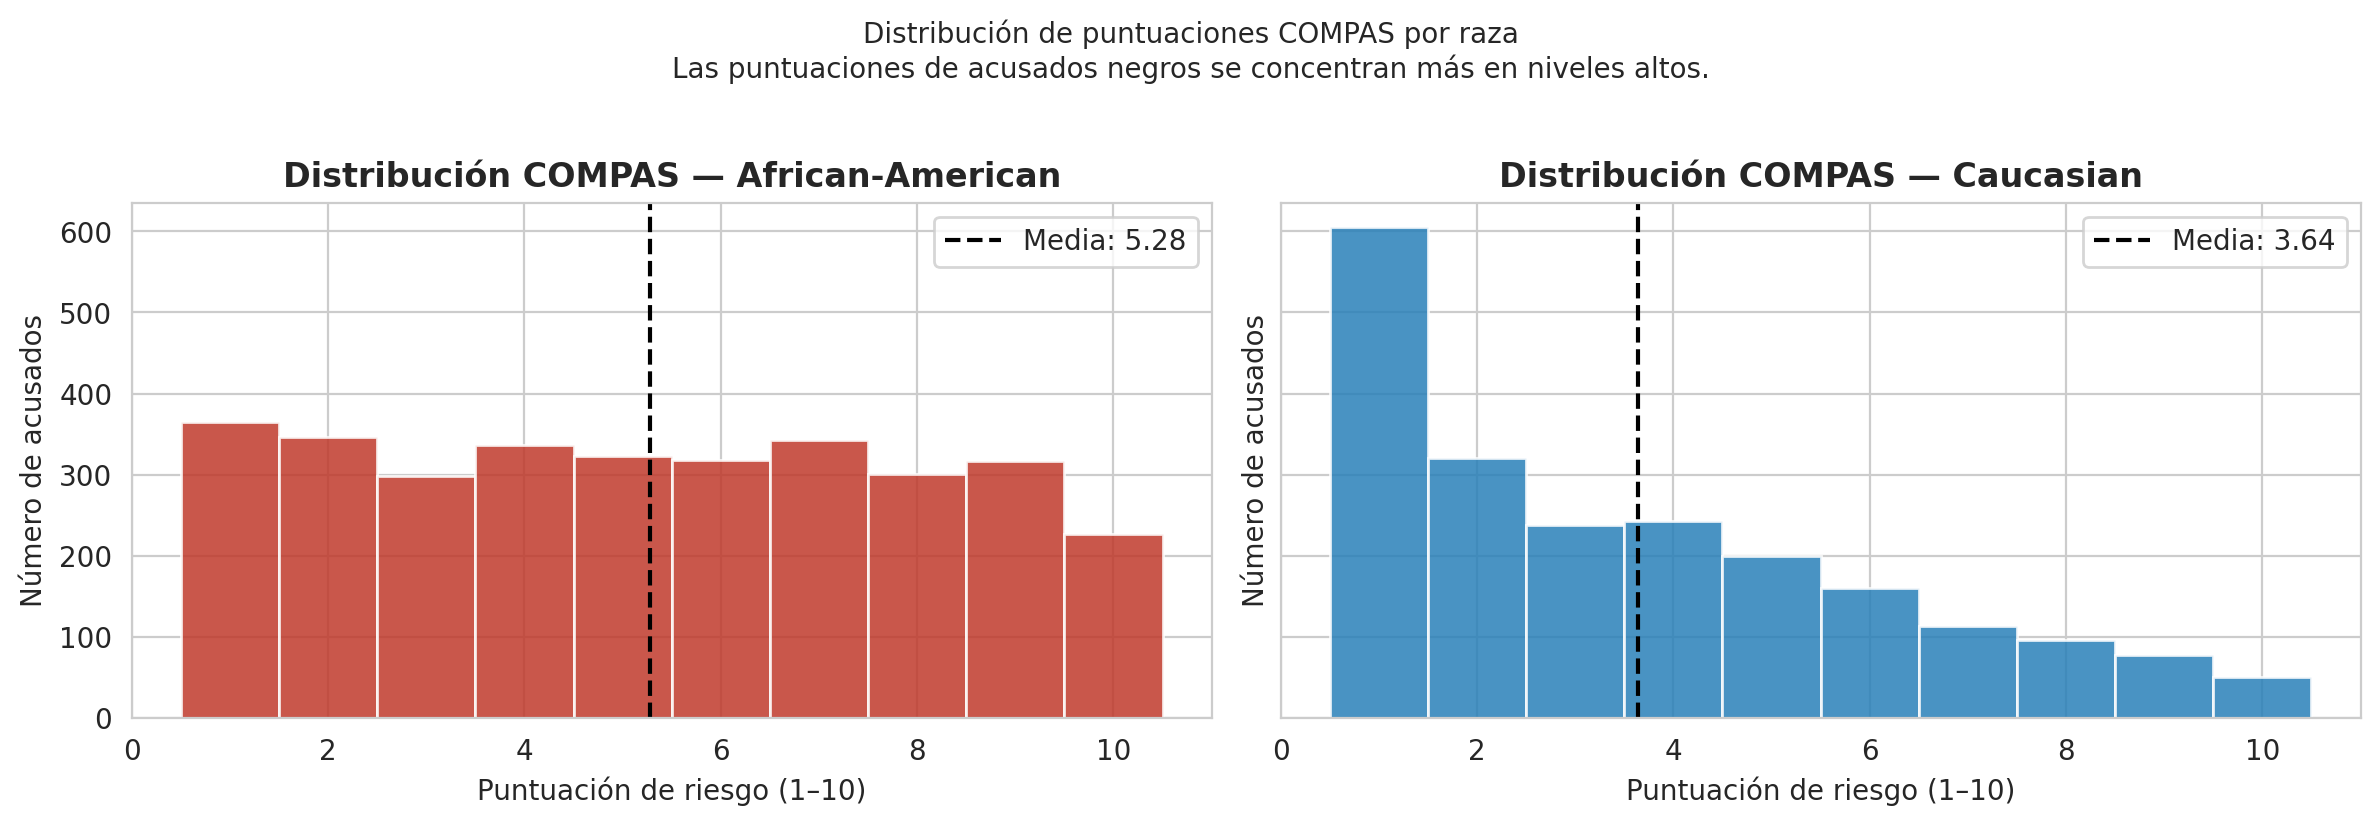

In [ ]:
#@title <font color="green">── Paso 2: Analizar la distribución de puntuaciones por grupo racial ──</font>
razas_principales = ['African-American', 'Caucasian']
df_2razas = df[df['race'].isin(razas_principales)].copy()

print("Puntuación media de decile_score por raza:")
print(df_2razas.groupby('race')['decile_score'].describe().round(2))

# Visualizar distribución
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colores = {'African-American': '#C0392B', 'Caucasian': '#2980B9'}

for ax, raza in zip(axes, razas_principales):
    subset = df_2razas[df_2razas['race'] == raza]['decile_score']
    ax.hist(subset, bins=10, range=(0.5, 10.5), color=colores[raza],
            edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribución COMPAS — {raza}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Puntuación de riesgo (1–10)')
    ax.set_ylabel('Número de acusados')
    ax.axvline(subset.mean(), color='black', linestyle='--',
               label=f'Media: {subset.mean():.2f}')
    ax.legend()

plt.suptitle('Distribución de puntuaciones COMPAS por raza\n'
             'Las puntuaciones de acusados negros se concentran más en niveles altos.',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#@title <font color="green">── Paso 3: Calcular tasas de error asimétricas (el hallazgo de ProPublica) ──</font>

def calcular_metricas_por_grupo(df, grupo_col, grupo_val, pred_col, real_col,
                                 pred_positivo, real_positivo):
    """
    Calcula FPR, FNR, PPV y precisión para un grupo específico.

    FPR (False Positive Rate): tasa de falsos positivos
        → ¿Con qué frecuencia etiquetamos alto riesgo a quien NO reincide?
    FNR (False Negative Rate): tasa de falsos negativos
        → ¿Con qué frecuencia etiquetamos bajo riesgo a quien SÍ reincide?
    PPV (Positive Predictive Value): valor predictivo positivo
        → De los etiquetados alto riesgo, ¿cuántos reincidieron realmente?
    """
    sub = df[df[grupo_col] == grupo_val]
    tp = ((sub[pred_col] == pred_positivo) & (sub[real_col] == real_positivo)).sum()
    fp = ((sub[pred_col] == pred_positivo) & (sub[real_col] != real_positivo)).sum()
    tn = ((sub[pred_col] != pred_positivo) & (sub[real_col] != real_positivo)).sum()
    fn = ((sub[pred_col] != pred_positivo) & (sub[real_col] == real_positivo)).sum()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    acc = (tp + tn) / (tp + fp + tn + fn)

    return {'Grupo': grupo_val, 'n': len(sub),
            'FPR (falsos positivos)': round(fpr, 4),
            'FNR (falsos negativos)': round(fnr, 4),
            'PPV (precisión positiva)': round(ppv, 4),
            'Accuracy': round(acc, 4)}

# Usamos score_text como predicción (High = alto riesgo)
# y two_year_recid como variable real (1 = reincidió)
df_2razas['pred_alto'] = (df_2razas['score_text'] == 'High').astype(int)

resultados = pd.DataFrame([
    calcular_metricas_por_grupo(df_2razas, 'race', 'African-American',
                                 'pred_alto', 'two_year_recid', 1, 1),
    calcular_metricas_por_grupo(df_2razas, 'race', 'Caucasian',
                                 'pred_alto', 'two_year_recid', 1, 1),
])

print("═" * 125)
print("MÉTRICAS DE EQUIDAD POR GRUPO RACIAL — Dataset COMPAS")
print("═" * 125)
print(resultados.to_string(index=False))
print("═" * 125)
print("\nInterpretación:")
fpr_negro  = resultados[resultados['Grupo'] == 'African-American']['FPR (falsos positivos)'].values[0]
fpr_blanco = resultados[resultados['Grupo'] == 'Caucasian']['FPR (falsos positivos)'].values[0]
ratio = fpr_negro / fpr_blanco if fpr_blanco > 0 else 0
print(f"  FPR negro / FPR blanco = {fpr_negro:.4f} / {fpr_blanco:.4f} = {ratio:.2f}x")
print(f"  → Los acusados negros son clasificados erróneamente como alto riesgo")
print(f"    {ratio:.1f} veces más que los acusados blancos.")
print()
ppv_negro  = resultados[resultados['Grupo'] == 'African-American']['PPV (precisión positiva)'].values[0]
ppv_blanco = resultados[resultados['Grupo'] == 'Caucasian']['PPV (precisión positiva)'].values[0]
print(f"  PPV negro  = {ppv_negro:.4f}")
print(f"  PPV blanco = {ppv_blanco:.4f}")
print(f"  → La calibración (PPV) es similar para ambos grupos.")
print(f"    Northpointe tenía razón en este punto.")
print()
print("  Este es el núcleo del debate: ambas métricas son correctas")
print("  pero llevan a conclusiones opuestas sobre la equidad del sistema.")

═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
MÉTRICAS DE EQUIDAD POR GRUPO RACIAL — Dataset COMPAS
═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
           Grupo    n  FPR (falsos positivos)  FNR (falsos negativos)  PPV (precisión positiva)  Accuracy
African-American 3175                  0.1394                  0.6183                    0.7503    0.6101
       Caucasian 2103                  0.0476                  0.8029                    0.7265    0.6572
═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

Interpretación:
  FPR negro / FPR blanco = 0.1394 / 0.0476 = 2.93x
  → Los acusados negros son clasificados erróneamente como alto riesgo
    2.9 veces más que los acusados blancos.

  PPV negro  = 0.7503
  PPV blanco = 0.7265
  → La calibración (PP

## **2.7 Detección de sesgo con AIF360**

AIF360 (AI Fairness 360) es la librería de IBM para auditoría y mitigación de sesgo. Ofrece más de 70 métricas de equidad y 10 algoritmos de mitigación, junto con varios datasets estándar del campo.

In [ ]:
#@title <font color="green">── Paso 1: Cargar el dataset COMPAS de AIF360 ───</font>
from aif360.datasets import CompasDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing
from sklearn.linear_model import LogisticRegression
import warnings
import os
import requests

warnings.filterwarnings('ignore')

print("Cargando dataset COMPAS desde AIF360...")

# Define the path where the dataset is expected
data_dir = '/usr/local/lib/python3.12/dist-packages/aif360/data/raw/compas'
file_path = os.path.join(data_dir, 'compas-scores-two-years.csv')

# Check if the directory exists, if not, create it
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

# Check if the file already exists, if not, download it
if not os.path.exists(file_path):
    print("Downloading compas-scores-two-years.csv...")
    url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
    r = requests.get(url, allow_redirects=True)
    with open(file_path, 'wb') as f:
        f.write(r.content)
    print("Download complete.")
else:
    print("Dataset already exists.")

dataset = CompasDataset()

# Definir grupos privilegiado y no privilegiado
# En AIF360 'race' está codificada como variable binaria:
# 1 = Caucasian (grupo privilegiado históricamente)
# 0 = African-American (grupo no privilegiado)
privileged_groups   = [{'race': 1}]
unprivileged_groups = [{'race': 0}]

print(f"Total de instancias: {len(dataset.features)}")
print(f"Características: {dataset.feature_names}")
print(f"Variable objetivo: {dataset.label_names}")

pip install 'aif360[inFairness]'


Cargando dataset COMPAS desde AIF360...
Download complete.


Total de instancias: 6167
Características: ['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'age_cat=25 - 45', 'age_cat=Greater than 45', 'age_cat=Less than 25', 'c_charge_degree=F', 'c_charge_degree=M', 'c_charge_desc=Abuse Without Great Harm', 'c_charge_desc=Agg Abuse Elderlly/Disabled Adult', 'c_charge_desc=Agg Assault W/int Com Fel Dome', 'c_charge_desc=Agg Battery Grt/Bod/Harm', 'c_charge_desc=Agg Fleeing and Eluding', 'c_charge_desc=Agg Fleeing/Eluding High Speed', 'c_charge_desc=Aggr Child Abuse-Torture,Punish', 'c_charge_desc=Aggrav Battery w/Deadly Weapon', 'c_charge_desc=Aggrav Child Abuse-Agg Battery', 'c_charge_desc=Aggrav Child Abuse-Causes Harm', 'c_charge_desc=Aggrav Stalking After Injunctn', 'c_charge_desc=Aggravated Assault', 'c_charge_desc=Aggravated Assault W/Dead Weap', 'c_charge_desc=Aggravated Assault W/dead Weap', 'c_charge_desc=Aggravated Assault W/o Firearm', 'c_charge_desc=Aggravated Assault w/Firearm', 'c_charge_des

In [ ]:
#@title <font color="green">── Paso 2: Métricas de equidad sobre el dataset (antes de entrenar modelo) ──</font>
metric_dataset = BinaryLabelDatasetMetric(
    dataset,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

print("═" * 55)
print("MÉTRICAS DE EQUIDAD — DATASET COMPAS (AIF360)")
print("═" * 55)

spd = metric_dataset.statistical_parity_difference()
di  = metric_dataset.disparate_impact()

print(f"\n📊 Diferencia de paridad estadística (SPD): {spd:.4f}")
print(f"   → Rango ideal: entre -0.1 y +0.1")
print(f"   → Interpretación: el grupo no privilegiado tiene una tasa")
print(f"     de resultado positivo {abs(spd):.1%} {'mayor' if spd > 0 else 'menor'} que el privilegiado.")

print(f"\n📊 Ratio de impacto dispar (DI): {di:.4f}")
print(f"   → Rango ideal: entre 0.8 y 1.25")
print(f"   → Regla del 80%: DI < 0.8 indica posible discriminación")
print(f"   → Estado actual: {'⚠️  Posible discriminación' if di < 0.8 else '✓ Dentro del rango aceptable'}")

print(f"\n📊 Diferencia en la tasa de etiquetas favorables: {metric_dataset.mean_difference():.4f}")

═══════════════════════════════════════════════════════
MÉTRICAS DE EQUIDAD — DATASET COMPAS (AIF360)
═══════════════════════════════════════════════════════

📊 Diferencia de paridad estadística (SPD): -0.0971
   → Rango ideal: entre -0.1 y +0.1
   → Interpretación: el grupo no privilegiado tiene una tasa
     de resultado positivo 9.7% menor que el privilegiado.

📊 Ratio de impacto dispar (DI): 0.8404
   → Rango ideal: entre 0.8 y 1.25
   → Regla del 80%: DI < 0.8 indica posible discriminación
   → Estado actual: ✓ Dentro del rango aceptable

📊 Diferencia en la tasa de etiquetas favorables: -0.0971


In [ ]:
#@title <font color="green">── Paso 3: Dividir dataset y entrenar modelo base ────</font>
from sklearn.model_selection import train_test_split as sk_split

# AIF360 tiene su propio método de split
dataset_train, dataset_test = dataset.split([0.7], shuffle=True, seed=42)

# Entrenar modelo de regresión logística sin mitigación
X_train = dataset_train.features
y_train = dataset_train.labels.ravel()
X_test  = dataset_test.features
y_test  = dataset_test.labels.ravel()

modelo_base = LogisticRegression(random_state=42, max_iter=1000)
modelo_base.fit(X_train, y_train)

# Crear dataset de predicciones con formato AIF360
y_pred = modelo_base.predict(X_test)
dataset_pred = dataset_test.copy()
dataset_pred.labels = y_pred.reshape(-1, 1)

In [ ]:
#@title <font color="green">── Paso 4: Métricas de clasificación desagregadas por grupo ──</font>
metric_clf = ClassificationMetric(
    dataset_test,
    dataset_pred,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

print("═" * 60)
print("MÉTRICAS DEL MODELO — Desagregadas por grupo racial")
print("═" * 60)

print(f"\n{'Métrica':<40} {'No priv.':<12} {'Priv.':<12} {'Diferencia'}")
print("-" * 70)

metricas = [
    ("Accuracy (exactitud)",
     metric_clf.accuracy(privileged=False),
     metric_clf.accuracy(privileged=True)),
    ("FPR (tasa de falsos positivos)",
     metric_clf.false_positive_rate(privileged=False),
     metric_clf.false_positive_rate(privileged=True)),
    ("FNR (tasa de falsos negativos)",
     metric_clf.false_negative_rate(privileged=False),
     metric_clf.false_negative_rate(privileged=True)),
    ("TPR (sensibilidad)",
     metric_clf.true_positive_rate(privileged=False),
     metric_clf.true_positive_rate(privileged=True)),
]

for nombre, val_np, val_p in metricas:
    diff = val_np - val_p
    print(f"{nombre:<40} {val_np:<12.4f} {val_p:<12.4f} {diff:+.4f}")

print("\n📊 Resumen de métricas de equidad del modelo:")
print(f"   Equal opportunity difference: {metric_clf.equal_opportunity_difference():.4f}")
print(f"   Average odds difference:      {metric_clf.average_odds_difference():.4f}")
print(f"   Theil index (desigualdad):    {metric_clf.theil_index():.4f}")

════════════════════════════════════════════════════════════
MÉTRICAS DEL MODELO — Desagregadas por grupo racial
════════════════════════════════════════════════════════════

Métrica                                  No priv.     Priv.        Diferencia
----------------------------------------------------------------------
Accuracy (exactitud)                     0.6752       0.6838       -0.0086
FPR (tasa de falsos positivos)           0.3851       0.5695       -0.1844
FNR (tasa de falsos negativos)           0.2679       0.1680       +0.0999
TPR (sensibilidad)                       0.7321       0.8320       -0.0999

📊 Resumen de métricas de equidad del modelo:
   Equal opportunity difference: -0.0999
   Average odds difference:      -0.1422
   Theil index (desigualdad):    0.1878


## **2.8 Mitigación de sesgo: técnica de preprocesamiento (Reweighing)**

Existen tres momentos para mitigar el sesgo: antes del entrenamiento (preprocesamiento), durante el entrenamiento (procesamiento) y después (postprocesamiento). Comenzamos con la más intuitiva: el **reweighing** o reponderación.

La idea es sencilla: asignar pesos más altos a los ejemplos del grupo minoritario que están infrarrepresentados, y pesos más bajos a los del grupo mayoritario que están sobrerrepresentados. Así, el modelo presta más atención a los ejemplos donde el dataset es injusto.

In [ ]:
#@title <font color="green">── Preprocesamiento: Reweighing ──</font>
from aif360.algorithms.preprocessing import Reweighing

print("Aplicando técnica de mitigación: Reweighing (reponderación)...")

# Crear el objeto Reweighing y ajustarlo sobre el dataset de entrenamiento
RW = Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)
dataset_train_rw = RW.fit_transform(dataset_train)

# Verificar los pesos asignados
pesos = dataset_train_rw.instance_weights
print(f"\nPesos asignados (primeras 10 instancias): {pesos[:10].round(4)}")
print(f"Peso mínimo: {pesos.min():.4f}")
print(f"Peso máximo: {pesos.max():.4f}")
print(f"Peso medio:  {pesos.mean():.4f}")

Aplicando técnica de mitigación: Reweighing (reponderación)...

Pesos asignados (primeras 10 instancias): [0.9366 1.1463 1.061  0.9366 1.061  1.1463 1.1463 0.9366 0.9023 1.061 ]
Peso mínimo: 0.9023
Peso máximo: 1.1463
Peso medio:  1.0000


In [ ]:
#@title <font color="green">── Entrenar modelo con los pesos ajustados ───</font>
modelo_rw = LogisticRegression(random_state=42, max_iter=1000)
modelo_rw.fit(
    dataset_train_rw.features,
    dataset_train_rw.labels.ravel(),
    sample_weight=dataset_train_rw.instance_weights
)

# Evaluar el modelo mitigado
y_pred_rw = modelo_rw.predict(X_test)
dataset_pred_rw = dataset_test.copy()
dataset_pred_rw.labels = y_pred_rw.reshape(-1, 1)

metric_rw = ClassificationMetric(
    dataset_test,
    dataset_pred_rw,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

print("═" * 65)
print("COMPARACIÓN: Modelo base vs. Modelo con Reweighing")
print("═" * 65)
print(f"\n{'Métrica':<35} {'Modelo base':>14} {'Con Reweighing':>14} {'Mejora':>8}")
print("-" * 75)

comparaciones = [
    ("Accuracy global",
     metric_clf.accuracy(), metric_rw.accuracy()),
    ("FPR no privilegiado",
     metric_clf.false_positive_rate(privileged=False),
     metric_rw.false_positive_rate(privileged=False)),
    ("FPR privilegiado",
     metric_clf.false_positive_rate(privileged=True),
     metric_rw.false_positive_rate(privileged=True)),
    ("Equal opportunity diff.",
     metric_clf.equal_opportunity_difference(),
     metric_rw.equal_opportunity_difference()),
    ("Average odds diff.",
     metric_clf.average_odds_difference(),
     metric_rw.average_odds_difference()),
]

for nombre, base, rw in comparaciones:
    mejora = rw - base
    signo  = '✓ mejor' if abs(rw) < abs(base) and nombre != 'Accuracy global' else ''
    print(f"{nombre:<35} {base:>14.4f} {rw:>14.4f} {signo}")

print("\n💡 Nota: la mitigación generalmente conlleva un ligero coste en accuracy global.")
print("   Este trade-off entre equidad y rendimiento es inherente al problema.")

═════════════════════════════════════════════════════════════════
COMPARACIÓN: Modelo base vs. Modelo con Reweighing
═════════════════════════════════════════════════════════════════

Métrica                                Modelo base Con Reweighing   Mejora
---------------------------------------------------------------------------
Accuracy global                             0.6780         0.6618 
FPR no privilegiado                         0.3851         0.4413 
FPR privilegiado                            0.5695         0.4753 ✓ mejor
Equal opportunity diff.                    -0.0999         0.0409 ✓ mejor
Average odds diff.                         -0.1422         0.0034 ✓ mejor

💡 Nota: la mitigación generalmente conlleva un ligero coste en accuracy global.
   Este trade-off entre equidad y rendimiento es inherente al problema.


## **2.9 Visualización comparativa: antes y después de la mitigación**


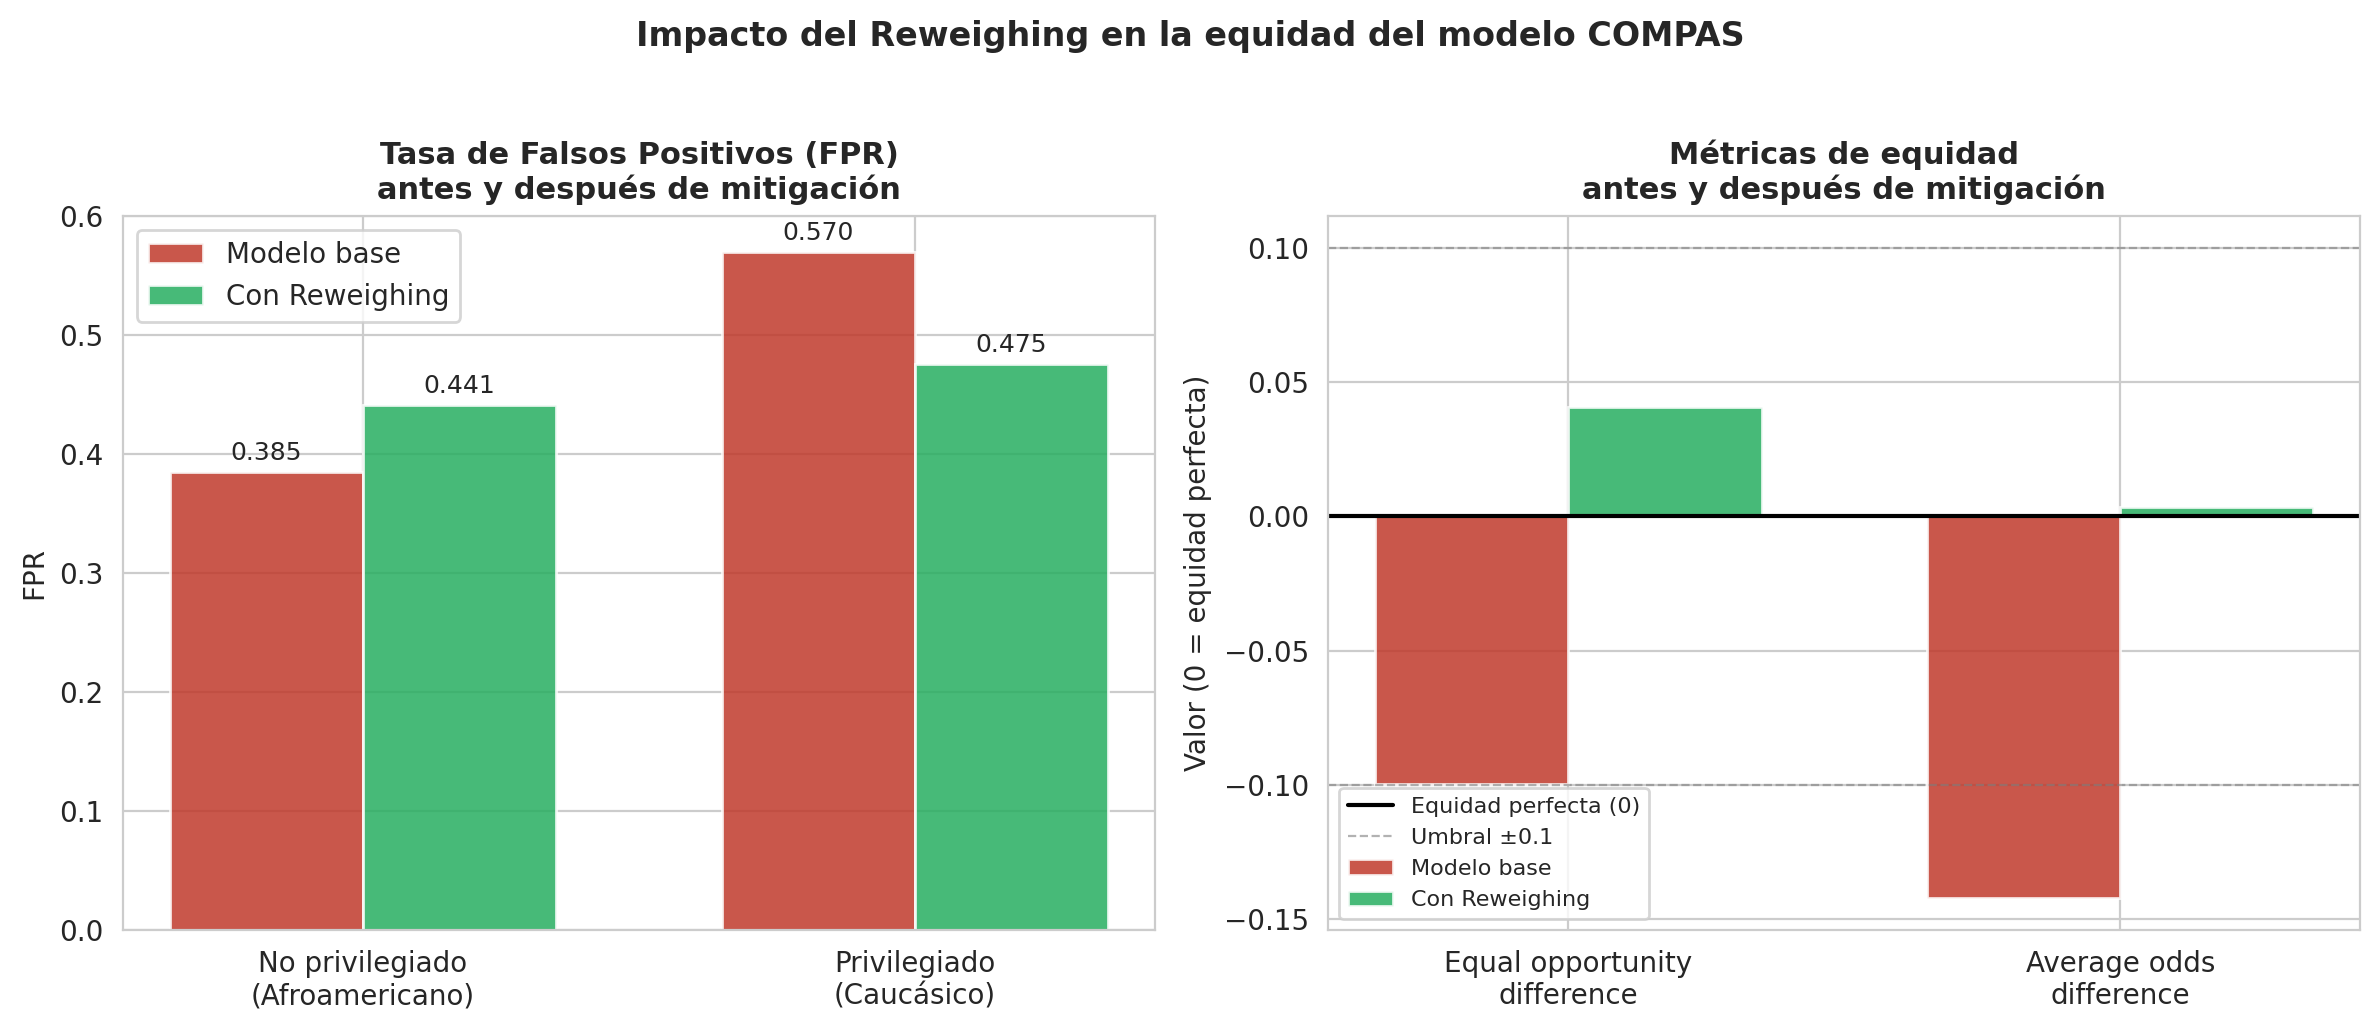

Gráfico guardado como comparacion_mitigacion.png


In [ ]:
#@title <font color="green">── Gráfico comparativo de FPR por grupo ──</font>
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

grupos    = ['No privilegiado\n(Afroamericano)', 'Privilegiado\n(Caucásico)']
fpr_base  = [metric_clf.false_positive_rate(privileged=False),
             metric_clf.false_positive_rate(privileged=True)]
fpr_rw    = [metric_rw.false_positive_rate(privileged=False),
             metric_rw.false_positive_rate(privileged=True)]

x = np.arange(len(grupos))
w = 0.35

# Gráfico 1: FPR comparativo
bars1 = axes[0].bar(x - w/2, fpr_base, w, label='Modelo base', color='#C0392B', alpha=0.85)
bars2 = axes[0].bar(x + w/2, fpr_rw,   w, label='Con Reweighing', color='#27AE60', alpha=0.85)
axes[0].set_title('Tasa de Falsos Positivos (FPR)\nantes y después de mitigación',
                   fontsize=11, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(grupos, fontsize=10)
axes[0].set_ylabel('FPR')
axes[0].set_ylim(0, 0.6)
axes[0].legend()
axes[0].axhline(y=0, color='black', linewidth=0.5)
for bar in bars1: axes[0].text(bar.get_x() + bar.get_width()/2,
                                bar.get_height() + 0.01,
                                f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2: axes[0].text(bar.get_x() + bar.get_width()/2,
                                bar.get_height() + 0.01,
                                f'{bar.get_height():.3f}', ha='center', fontsize=9)

# Gráfico 2: Brecha de equidad
metricas_equidad  = ['Equal opportunity\ndifference', 'Average odds\ndifference']
vals_base = [metric_clf.equal_opportunity_difference(),
             metric_clf.average_odds_difference()]
vals_rw   = [metric_rw.equal_opportunity_difference(),
             metric_rw.average_odds_difference()]

x2 = np.arange(len(metricas_equidad))
axes[1].bar(x2 - w/2, vals_base, w, label='Modelo base', color='#C0392B', alpha=0.85)
axes[1].bar(x2 + w/2, vals_rw,   w, label='Con Reweighing', color='#27AE60', alpha=0.85)
axes[1].axhline(y=0,    color='black', linewidth=1.5, label='Equidad perfecta (0)')
axes[1].axhline(y=0.1,  color='gray',  linewidth=0.8, linestyle='--', alpha=0.6)
axes[1].axhline(y=-0.1, color='gray',  linewidth=0.8, linestyle='--', alpha=0.6,
                label='Umbral ±0.1')
axes[1].set_title('Métricas de equidad\nantes y después de mitigación',
                   fontsize=11, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metricas_equidad, fontsize=10)
axes[1].set_ylabel('Valor (0 = equidad perfecta)')
axes[1].legend(fontsize=8)

plt.suptitle('Impacto del Reweighing en la equidad del modelo COMPAS',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparacion_mitigacion.png', dpi=120, bbox_inches='tight')
plt.show()
print("Gráfico guardado como comparacion_mitigacion.png")

## **2.10 Checklist de auditoría de sesgo**

Usa esta lista antes de desplegar cualquier modelo que tome decisiones sobre personas:

In [ ]:
#@title <font color="green">Imprimir checklist de auditoría de sesgo</font>
checklist = {
    "DATOS": [
        "¿Están representados todos los grupos relevantes en el dataset?",
        "¿La variable objetivo mide directamente lo que importa, o es un proxy?",
        "¿Los datos de entrenamiento reflejan decisiones históricamente sesgadas?",
        "¿Se han revisado los datos de test para detectar sesgo de supervivencia?",
    ],
    "MODELO Y EVALUACIÓN": [
        "¿Se han calculado métricas de rendimiento desagregadas por grupo?",
        "¿Se ha calculado el ratio de impacto dispar (DI)?",
        "¿Se ha verificado la igualdad de tasas de error (FPR / FNR) entre grupos?",
        "¿Se ha evaluado la calibración del modelo por subgrupos?",
        "¿El tamaño de los subgrupos en el test set es suficiente para obtener resultados estadísticamente fiables?",
    ],
    "DESPLIEGUE Y MONITOREO": [
        "¿Existe un mecanismo para que los afectados puedan impugnar decisiones?",
        "¿Se monitorizan las métricas de equidad en producción, no solo la precisión?",
        "¿Hay un proceso establecido para re-entrenar el modelo si se detecta feedback loop?",
        "¿Existe documentación (Model Card) que describa el comportamiento por subgrupos?",
    ]
}

for seccion, items in checklist.items():
    print(f"\n{'─' * 55}")
    print(f"  {seccion}")
    print(f"{'─' * 55}")
    for item in items:
        print(f"  ☐  {item}")


───────────────────────────────────────────────────────
  DATOS
───────────────────────────────────────────────────────
  ☐  ¿Están representados todos los grupos relevantes en el dataset?
  ☐  ¿La variable objetivo mide directamente lo que importa, o es un proxy?
  ☐  ¿Los datos de entrenamiento reflejan decisiones históricamente sesgadas?
  ☐  ¿Se han revisado los datos de test para detectar sesgo de supervivencia?

───────────────────────────────────────────────────────
  MODELO Y EVALUACIÓN
───────────────────────────────────────────────────────
  ☐  ¿Se han calculado métricas de rendimiento desagregadas por grupo?
  ☐  ¿Se ha calculado el ratio de impacto dispar (DI)?
  ☐  ¿Se ha verificado la igualdad de tasas de error (FPR / FNR) entre grupos?
  ☐  ¿Se ha evaluado la calibración del modelo por subgrupos?
  ☐  ¿El tamaño de los subgrupos en el test set es suficiente para obtener resultados estadísticamente fiables?

───────────────────────────────────────────────────────
  DESPL

## **2.11 Ejercicios propuestos**

> **Ejercicio 1 (básico):** Carga el dataset `AdultDataset` de AIF360 y calcula las métricas de sesgo por género (`sex`). ¿Existe impacto dispar en la predicción de ingresos altos (>50K)? ¿Cuál es la diferencia de paridad estadística? Interpreta los resultados en términos del contexto del dataset.

> **Ejercicio 2 (intermedio):** Entrena un modelo de Random Forest sobre el dataset COMPAS sin ninguna mitigación. Calcula las métricas desagregadas por raza. Compara los resultados con los de la regresión logística vista en este bloque. ¿Qué modelo es más equitativo? ¿Un modelo más preciso globalmente es necesariamente más equitativo?

> **Ejercicio 3 (avanzado):** Aplica las tres técnicas de mitigación de AIF360 sobre el dataset German Credit (`GermanDataset`) con la variable `sex` como atributo sensible:
> - **Preprocesamiento:** `Reweighing`
> - **Procesamiento:** `AdversarialDebiasing` (requiere TensorFlow)
> - **Postprocesamiento:** `EqOddsPostprocessing`
>
> Para cada técnica, calcula accuracy, FPR por grupo y `average_odds_difference`. Construye una tabla comparativa y reflexiona sobre el trade-off entre equidad y rendimiento en cada caso.

> **Ejercicio 4 (reflexión):** Lee el artículo original de ProPublica y el artículo de respuesta de Northpointe. Escribe un análisis de 300–400 palabras respondiendo a: ¿Qué definición de equidad usó cada parte? ¿Ambas pueden tener razón al mismo tiempo? ¿Quién debería decidir qué definición de equidad es la correcta en un sistema de justicia penal?

## **Referencias del bloque**

| Recurso | Tipo | Enlace |
|---|---|---|
| *Fairness and Machine Learning* (Barocas, Hardt, Narayanan) | Libro gratuito | https://fairmlbook.org |
| AIF360 — documentación oficial | Librería | https://aif360.readthedocs.io |
| ProPublica COMPAS Analysis | Repositorio | https://github.com/propublica/compas-analysis |
| Chouldechova (2016) — Teorema de imposibilidad | Artículo | https://arxiv.org/abs/1703.00056 |
| Gender Shades (Buolamwini & Gebru, 2018) | Artículo | http://gendershades.org |
| NIST — Face Recognition Vendor Test (2019) | Informe | https://www.nist.gov/programs-projects/face-recognition-vendor-testing-frvt |
| *Weapons of Math Destruction* (O'Neil, 2016) | Libro | ISBN 978-0553418811 |
| Northpointe — Respuesta a ProPublica | Documento técnico | https://go.documentcloud.org/public/docs/2702103 |


# **3. Equidad (Fairness)**


## **3.1 ¿Qué es la equidad en ML y por qué es difícil?**

La equidad (*fairness*) en sistemas de ML responde a una pregunta aparentemente sencilla: ¿trata el modelo igual a todas las personas? La respuesta, sin embargo, depende radicalmente de qué entendemos por "igual".

Este bloque parte de un hecho incómodo pero fundamental: **no existe una definición matemática única y correcta de equidad**. Existen múltiples definiciones formales que son mutuamente incompatibles en la mayoría de situaciones reales. Elegir entre ellas es, en última instancia, una decisión ética y política.

### ¿Por qué importa esto en la práctica?

Imagina un banco que usa un modelo de ML para decidir si conceder un préstamo. El modelo tiene un 85% de precisión global. ¿Es justo?

- Si el 90% de los solicitantes del grupo A obtienen el préstamo pero solo el 60% del grupo B, hay un problema de **paridad demográfica**.
- Si el modelo predice correctamente la devolución del préstamo con igual fiabilidad en ambos grupos, tiene **calibración**.
- Si la tasa de solicitantes solventes rechazados es mayor en el grupo B, hay un problema de **igualdad de oportunidades**.

Las tres situaciones pueden darse simultáneamente, y corregir una puede empeorar las otras. Esto no es un fallo de implementación: es una consecuencia matemática inevitable cuando las tasas de base difieren entre grupos.

## **3.2 Definiciones formales de equidad**

Usamos la siguiente notación:
- **Ŷ** → predicción del modelo (variable aleatoria)
- **Y** → etiqueta real (variable aleatoria)
- **A** → atributo sensible (p.ej. raza, género); A=0 grupo no privilegiado, A=1 grupo privilegiado
- **s** → una puntuación de probabilidad específica (p.ej. 0.7)

### 3.2.1 Paridad demográfica (*Demographic Parity*)

```
P(Ŷ=1 | A=0) = P(Ŷ=1 | A=1)
```

Ambos grupos deben recibir predicciones positivas con la misma frecuencia, independientemente de si son candidatos calificados o no.

**Ejemplo:** si el 30% de los hombres recibe oferta de trabajo, el 30% de las mujeres también debe recibirla.

**Ventaja:** es fácil de medir y comunicar. Garantiza resultados iguales entre grupos.

**Crítica:** ignora las diferencias reales en la variable objetivo. Si el 50% de los hombres son calificados pero solo el 30% de las mujeres (por diferencias en formación, no discriminación), exigir paridad demográfica implica que el modelo debe tratar de forma diferente a candidatos igualmente calificados.

**Métrica en código:**
```python
from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio

dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=A)
dpr = demographic_parity_ratio(y_true, y_pred, sensitive_features=A)

# dpd = 0   → paridad perfecta
# dpd > 0   → grupo A=1 recibe más predicciones positivas
# dpr = 1   → paridad perfecta
# dpr < 0.8 → regla del 80%: posible discriminación
```

### 3.2.2 Igualdad de oportunidades (*Equal Opportunity*)

```
P(Ŷ=1 | Y=1, A=0) = P(Ŷ=1 | Y=1, A=1)
```

La tasa de verdaderos positivos (TPR, sensibilidad) debe ser igual en ambos grupos. Solo miramos los casos donde la etiqueta real es positiva.

**Ejemplo:** de todos los solicitantes que realmente devolverían el préstamo, el mismo porcentaje debe ser aprobado en ambos grupos.

**Ventaja:** se centra en el tipo de error más dañino para el grupo no privilegiado (ser rechazado cuando eres calificado). Es la definición más usada en contextos de acceso a oportunidades (empleo, crédito, educación).

**Crítica:** ignora completamente los falsos positivos. Un modelo que aprueba a todo el mundo satisface la igualdad de oportunidades trivialmente.

### 3.2.3 Equalized Odds (Igualdad de probabilidades)

```
P(Ŷ=1 | Y=y, A=0) = P(Ŷ=1 | Y=y, A=1)  para y ∈ {0, 1}
```

Es la más exigente: tanto la TPR como la FPR deben ser iguales entre grupos. Es la intersección de igualdad de oportunidades (TPR igual) e igualdad de falsos positivos (FPR igual).

**Ventaja:** controla simultáneamente ambos tipos de error.

**Crítica:** muy difícil de satisfacer en la práctica. Puede requerir degradar significativamente el rendimiento global del modelo.

### 3.2.4 Calibración (*Calibration*)

```
P(Y=1 | Ŷ=s, A=0) = P(Y=1 | Ŷ=s, A=1)  para todo s ∈ [0,1]
```

Una puntuación de probabilidad de 0.7 debe significar lo mismo para ambos grupos: el 70% de los casos con esa puntuación deben ser realmente positivos, independientemente del grupo.

**Ventaja:** garantiza que las puntuaciones del modelo son interpretables y comparables entre grupos.

**Crítica:** puede coexistir con tasas de error asimétricas. Es posible tener un modelo perfectamente calibrado que, aun así, comete falsos positivos el doble de veces en un grupo que en otro (exactamente el caso COMPAS).

### 3.2.5 Tabla comparativa de métricas

| Métrica | Fórmula | Pregunta que responde | Contexto de uso típico |
|---|---|---|---|
| **Paridad demográfica** | P(Ŷ=1\|A=0) = P(Ŷ=1\|A=1) | ¿Resultados iguales entre grupos? | Contratación, crédito, publicidad |
| **Igualdad de oportunidades** | TPR igual entre grupos | ¿Se detectan los positivos reales por igual? | Diagnóstico médico, selección de candidatos |
| **Equalized odds** | TPR y FPR iguales entre grupos | ¿Errores y aciertos iguales en todos los grupos? | Justicia penal, evaluación de riesgo |
| **Calibración** | P(Y=1\|score=s) igual entre grupos | ¿Significa lo mismo una puntuación de 0.7? | Predicción de riesgo, seguros |
| **Equidad individual** | Casos similares → predicciones similares | ¿Dos personas iguales reciben el mismo trato? | Decisiones individualizadas |

## 3.3 El teorema de imposibilidad: ¿por qué no podemos tenerlo todo?

> **Teorema de Chouldechova (2017):** cuando las tasas de prevalencia difieren entre grupos (P(Y=1|A=0) ≠ P(Y=1|A=1)), es matemáticamente imposible satisfacer simultáneamente:
> 1. Calibración
> 2. Igualdad de FPR entre grupos
> 3. Igualdad de FNR entre grupos
>
> Solo se pueden satisfacer las tres simultáneamente si el modelo es perfecto (sin errores) o si las tasas de base son idénticas en todos los grupos.

In [ ]:
#@title <font color="green">--- Demostración intuitiva con código </font>
from sklearn.metrics import confusion_matrix

np.random.seed(42)

def simular_escenario(n=1000, prevalencia_A=0.3, prevalencia_B=0.5,
                      threshold=0.5, noise=0.2):
    """
    Simula un clasificador sobre dos grupos con distintas tasas de base.

    prevalencia_A: tasa de positivos reales en grupo A (p.ej. 0.3)
    prevalencia_B: tasa de positivos reales en grupo B (p.ej. 0.5)
    """
    # Grupo A: prevalencia baja
    y_A = np.random.binomial(1, prevalencia_A, n)
    scores_A = y_A * (1 - noise) + (1 - y_A) * noise + np.random.normal(0, 0.1, n)
    scores_A = np.clip(scores_A, 0, 1)
    y_pred_A = (scores_A >= threshold).astype(int)

    # Grupo B: prevalencia alta
    y_B = np.random.binomial(1, prevalencia_B, n)
    scores_B = y_B * (1 - noise) + (1 - y_B) * noise + np.random.normal(0, 0.1, n)
    scores_B = np.clip(scores_B, 0, 1)
    y_pred_B = (scores_B >= threshold).astype(int)

    def metricas(y_real, y_pred, scores):
        tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        # Calibración: para puntuación ~0.7, qué fracción es positivo
        mask = (scores >= 0.6) & (scores <= 0.8)
        cal = y_real[mask].mean() if mask.sum() > 0 else np.nan
        return {'FPR': fpr, 'FNR': fnr, 'TPR': tpr, 'PPV': ppv, 'Calibración_0.7': cal}

    return metricas(y_A, y_pred_A, scores_A), metricas(y_B, y_pred_B, scores_B)

m_A, m_B = simular_escenario(prevalencia_A=0.2, prevalencia_B=0.5)

print("═" * 60)
print("DEMOSTRACIÓN DEL TEOREMA DE IMPOSIBILIDAD")
print("Grupo A: prevalencia 20% | Grupo B: prevalencia 50%")
print("═" * 60)
print(f"\n{'Métrica':<25} {'Grupo A':>10} {'Grupo B':>10} {'Diferencia':>12}")
print("─" * 60)
for k in ['FPR', 'FNR', 'TPR', 'PPV', 'Calibración_0.7']:
    diff = m_A[k] - m_B[k]
    igual = '✓' if abs(diff) < 0.05 else '✗'
    print(f"{k:<25} {m_A[k]:>10.4f} {m_B[k]:>10.4f} {diff:>+12.4f}  {igual}")

print("\n💡 Observa que es imposible tener FPR, FNR y Calibración")
print("   iguales simultáneamente cuando las prevalencias difieren.")

════════════════════════════════════════════════════════════
DEMOSTRACIÓN DEL TEOREMA DE IMPOSIBILIDAD
Grupo A: prevalencia 20% | Grupo B: prevalencia 50%
════════════════════════════════════════════════════════════

Métrica                      Grupo A    Grupo B   Diferencia
────────────────────────────────────────────────────────────
FPR                           0.0012     0.0000      +0.0012  ✓
FNR                           0.0000     0.0000      +0.0000  ✓
TPR                           1.0000     1.0000      +0.0000  ✓
PPV                           0.9950     1.0000      -0.0050  ✓
Calibración_0.7               1.0000     1.0000      +0.0000  ✓

💡 Observa que es imposible tener FPR, FNR y Calibración
   iguales simultáneamente cuando las prevalencias difieren.


**Consecuencias prácticas del teorema**

El teorema de Chouldechova tiene implicaciones profundas que van más allá de la estadística:

1. **No hay solución técnica definitiva.** No existe un algoritmo que elimine el conflicto entre métricas de equidad. Cualquier mitigación es un compromiso.

2. **La elección de métrica es política.** Decidir qué métrica de equidad priorizar equivale a decidir qué tipo de error es más aceptable y para quién. Es una decisión de valores.

3. **Las tasas de base importan.** Las diferencias en las tasas de prevalencia entre grupos no surgen de la nada: reflejan desigualdades estructurales históricas. Un algoritmo "neutro" que maximiza la precisión global puede amplificar esas desigualdades.

4. **La equidad no puede delegarse al algoritmo.** Los sistemas de ML no pueden resolver por sí solos problemas que son fundamentalmente sociopolíticos. Pueden, en cambio, hacerlos más visibles y medibles.

## **3.4 Instalación y configuración**

In [ ]:
#@title <font color="green">Instalar Fairlearn y dependencias</font>
!pip install fairlearn scikit-learn pandas numpy matplotlib --quiet

# Verificar instalación
import fairlearn
import sklearn
print(f"✓ Fairlearn {fairlearn.__version__}")
print(f"✓ Scikit-learn {sklearn.__version__}")

✓ Fairlearn 0.13.0
✓ Scikit-learn 1.6.1


## **3.5 Preparación del dataset: German Credit**

Usaremos el dataset German Credit, un estándar en el campo de la equidad en ML. Contiene información sobre 1.000 solicitantes de crédito en Alemania, con variables sociodemográficas y financieras.

In [ ]:
#@title <font color="green">── Cargar el dataset German Credit ──</font>

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Fuente: UCI Machine Learning Repository
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
       "statlog/german/german.data")

columnas = [
    'checking_account', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment', 'installment_rate',
    'personal_status', 'other_debtors', 'residence_since', 'property',
    'age', 'other_installments', 'housing', 'existing_credits', 'job',
    'num_dependents', 'telephone', 'foreign_worker', 'credit_risk'
]

df = pd.read_csv(url, sep=' ', header=None, names=columnas)

# Binarizar variable objetivo: 1 = buen crédito, 0 = mal crédito
df['credit_risk'] = (df['credit_risk'] == 1).astype(int)

# Extraer atributo sensible: género
# En el dataset original, personal_status codifica género + estado civil:
# A91 = hombre divorciado/separado
# A92 = mujer divorciada/separada/casada
# A93 = hombre soltero
# A94 = hombre casado/viudo
# A95 = mujer soltera
df['genero'] = df['personal_status'].apply(
    lambda x: 'hombre' if x in ['A91', 'A93', 'A94'] else 'mujer'
)
df['genero_bin'] = (df['genero'] == 'hombre').astype(int)  # 1=hombre, 0=mujer

# También creamos grupo de edad (≥25 = adulto establecido)
df['edad_grupo'] = (df['age'] >= 25).astype(int)

print("═" * 55)
print("DATASET GERMAN CREDIT — Resumen")
print("═" * 55)
print(f"Total de instancias:     {len(df)}")
print(f"Buen crédito (clase 1):  {df['credit_risk'].sum()} ({df['credit_risk'].mean():.1%})")
print(f"Mal crédito (clase 0):   {(df['credit_risk']==0).sum()} ({(df['credit_risk']==0).mean():.1%})")
print(f"\nDistribución por género:")
print(df['genero'].value_counts().to_string())
print(f"\nTasa de buen crédito por género:")
print(df.groupby('genero')['credit_risk'].mean().round(4).to_string())
print(f"\n💡 Diferencia de tasa base entre géneros:")
diff = (df[df['genero']=='hombre']['credit_risk'].mean() -
        df[df['genero']=='mujer']['credit_risk'].mean())
print(f"   {diff:+.4f} — Esta diferencia hace que el teorema de imposibilidad sea relevante aquí")

═══════════════════════════════════════════════════════
DATASET GERMAN CREDIT — Resumen
═══════════════════════════════════════════════════════
Total de instancias:     1000
Buen crédito (clase 1):  700 (70.0%)
Mal crédito (clase 0):   300 (30.0%)

Distribución por género:
genero
hombre    690
mujer     310

Tasa de buen crédito por género:
genero
hombre    0.7232
mujer     0.6484

💡 Diferencia de tasa base entre géneros:
   +0.0748 — Esta diferencia hace que el teorema de imposibilidad sea relevante aquí


In [ ]:
#@title <font color="green">── Preprocesamiento de variables ───</font>
# Codificar variables categóricas
cat_cols = ['checking_account', 'credit_history', 'purpose', 'savings_account',
            'employment', 'other_debtors', 'property', 'other_installments',
            'housing', 'job', 'telephone', 'foreign_worker']

df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Variables para el modelo (excluimos personal_status para no duplicar género)
features = [c for c in columnas[:-1] if c != 'personal_status']
X = df_encoded[features]
y = df_encoded['credit_risk']
sensitive = df_encoded['genero']           # string: 'hombre'/'mujer'
sensitive_bin = df_encoded['genero_bin']   # binario: 1/0

# Escalado
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split
X_train, X_test, y_train, y_test, s_train, s_test, s_bin_train, s_bin_test = \
    train_test_split(X_scaled, y, sensitive, sensitive_bin,
                     test_size=0.3, random_state=42, stratify=y)

print(f"Train: {len(X_train)} instancias | Test: {len(X_test)} instancias")
print(f"\nDistribución de género en test:")
print(s_test.value_counts().to_string())

Train: 700 instancias | Test: 300 instancias

Distribución de género en test:
genero
hombre    204
mujer      96


## **3.6 Medir equidad con Fairlearn**

Fairlearn es la librería de referencia de Microsoft para evaluación y mitigación de inequidad en ML. Su componente central es el `MetricFrame`.

In [ ]:
#@title <font color="green">── Modelo base sin ninguna mitigación ──</font>
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio,
    false_positive_rate,
    false_negative_rate,
    selection_rate
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

modelo_base = LogisticRegression(random_state=42, max_iter=1000)
modelo_base.fit(X_train, y_train)
y_pred_base = modelo_base.predict(X_test)

print("═" * 55)
print("MODELO BASE — Rendimiento global")
print("═" * 55)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_base):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_base):.4f}")

═══════════════════════════════════════════════════════
MODELO BASE — Rendimiento global
═══════════════════════════════════════════════════════
Accuracy:  0.7667
Precision: 0.8017
Recall:    0.8857
F1:        0.8416


In [ ]:
#@title <font color="green">── MetricFrame: métricas desagregadas por grupo ───</font>
metricas_dict = {
    'accuracy':   accuracy_score,
    'precision':  precision_score,
    'recall':     recall_score,
    'f1':         f1_score,
    'fpr':        false_positive_rate,
    'fnr':        false_negative_rate,
    'sel_rate':   selection_rate,   # tasa de predicciones positivas
}

mf = MetricFrame(
    metrics=metricas_dict,
    y_true=y_test,
    y_pred=y_pred_base,
    sensitive_features=s_test
)

print("═" * 70)
print("MÉTRICAS DESAGREGADAS POR GÉNERO — Modelo base")
print("═" * 70)
print("\nPor grupo:")
print(mf.by_group.round(4).to_string())
print("\nGlobal (media ponderada):")
print(mf.overall.round(4).to_string())
print("\nDiferencia máxima entre grupos:")
print(mf.difference().round(4).to_string())
print("\nRatio mínimo entre grupos:")
print(mf.ratio().round(4).to_string())

══════════════════════════════════════════════════════════════════════
MÉTRICAS DESAGREGADAS POR GÉNERO — Modelo base
══════════════════════════════════════════════════════════════════════

Por grupo:
        accuracy  precision  recall      f1     fpr     fnr  sel_rate
genero                                                               
hombre    0.7696     0.8012  0.9048  0.8498  0.5789  0.0952    0.8137
mujer     0.7604     0.8030  0.8413  0.8217  0.3939  0.1587    0.6875

Global (media ponderada):
accuracy     0.7667
precision    0.8017
recall       0.8857
f1           0.8416
fpr          0.5111
fnr          0.1143
sel_rate     0.7733

Diferencia máxima entre grupos:
accuracy     0.0092
precision    0.0018
recall       0.0635
f1           0.0281
fpr          0.1850
fnr          0.0635
sel_rate     0.1262

Ratio mínimo entre grupos:
accuracy     0.9881
precision    0.9977
recall       0.9298
f1           0.9669
fpr          0.6804
fnr          0.6000
sel_rate     0.8449


In [ ]:
#@title <font color="green">── Métricas de equidad específicas ───</font>
print("═" * 55)
print("MÉTRICAS DE EQUIDAD — Modelo base")
print("═" * 55)

dpd = demographic_parity_difference(y_test, y_pred_base, sensitive_features=s_test)
dpr = demographic_parity_ratio(y_test, y_pred_base, sensitive_features=s_test)
eod = equalized_odds_difference(y_test, y_pred_base, sensitive_features=s_test)
eor = equalized_odds_ratio(y_test, y_pred_base, sensitive_features=s_test)

print(f"\n📊 Paridad demográfica:")
print(f"   Diferencia (DPD): {dpd:+.4f}  (ideal: 0.0)")
print(f"   Ratio     (DPR): {dpr:.4f}  (ideal: 1.0, aceptable: 0.8–1.25)")
print(f"   → {'⚠️  Posible disparidad' if abs(dpd) > 0.1 else '✓ Dentro del rango'}")

print(f"\n📊 Equalized odds:")
print(f"   Diferencia (EOD): {eod:+.4f}  (ideal: 0.0)")
print(f"   Ratio     (EOR): {eor:.4f}  (ideal: 1.0)")
print(f"   → {'⚠️  Disparidad significativa' if abs(eod) > 0.1 else '✓ Dentro del rango'}")

# FPR y FNR por grupo manualmente
for grupo in s_test.unique():
    mask = s_test == grupo
    tn = ((y_pred_base[mask]==0) & (y_test[mask]==0)).sum()
    fp = ((y_pred_base[mask]==1) & (y_test[mask]==0)).sum()
    fn = ((y_pred_base[mask]==0) & (y_test[mask]==1)).sum()
    tp = ((y_pred_base[mask]==1) & (y_test[mask]==1)).sum()
    fpr_g = fp/(fp+tn) if (fp+tn)>0 else 0
    fnr_g = fn/(fn+tp) if (fn+tp)>0 else 0
    print(f"\n   {grupo}: FPR={fpr_g:.4f} | FNR={fnr_g:.4f} | n={mask.sum()}")

═══════════════════════════════════════════════════════
MÉTRICAS DE EQUIDAD — Modelo base
═══════════════════════════════════════════════════════

📊 Paridad demográfica:
   Diferencia (DPD): +0.1262  (ideal: 0.0)
   Ratio     (DPR): 0.8449  (ideal: 1.0, aceptable: 0.8–1.25)
   → ⚠️  Posible disparidad

📊 Equalized odds:
   Diferencia (EOD): +0.1850  (ideal: 0.0)
   Ratio     (EOR): 0.6804  (ideal: 1.0)
   → ⚠️  Disparidad significativa

   mujer: FPR=0.3939 | FNR=0.1587 | n=96

   hombre: FPR=0.5789 | FNR=0.0952 | n=204


## **3.7 Visualización de la equidad**

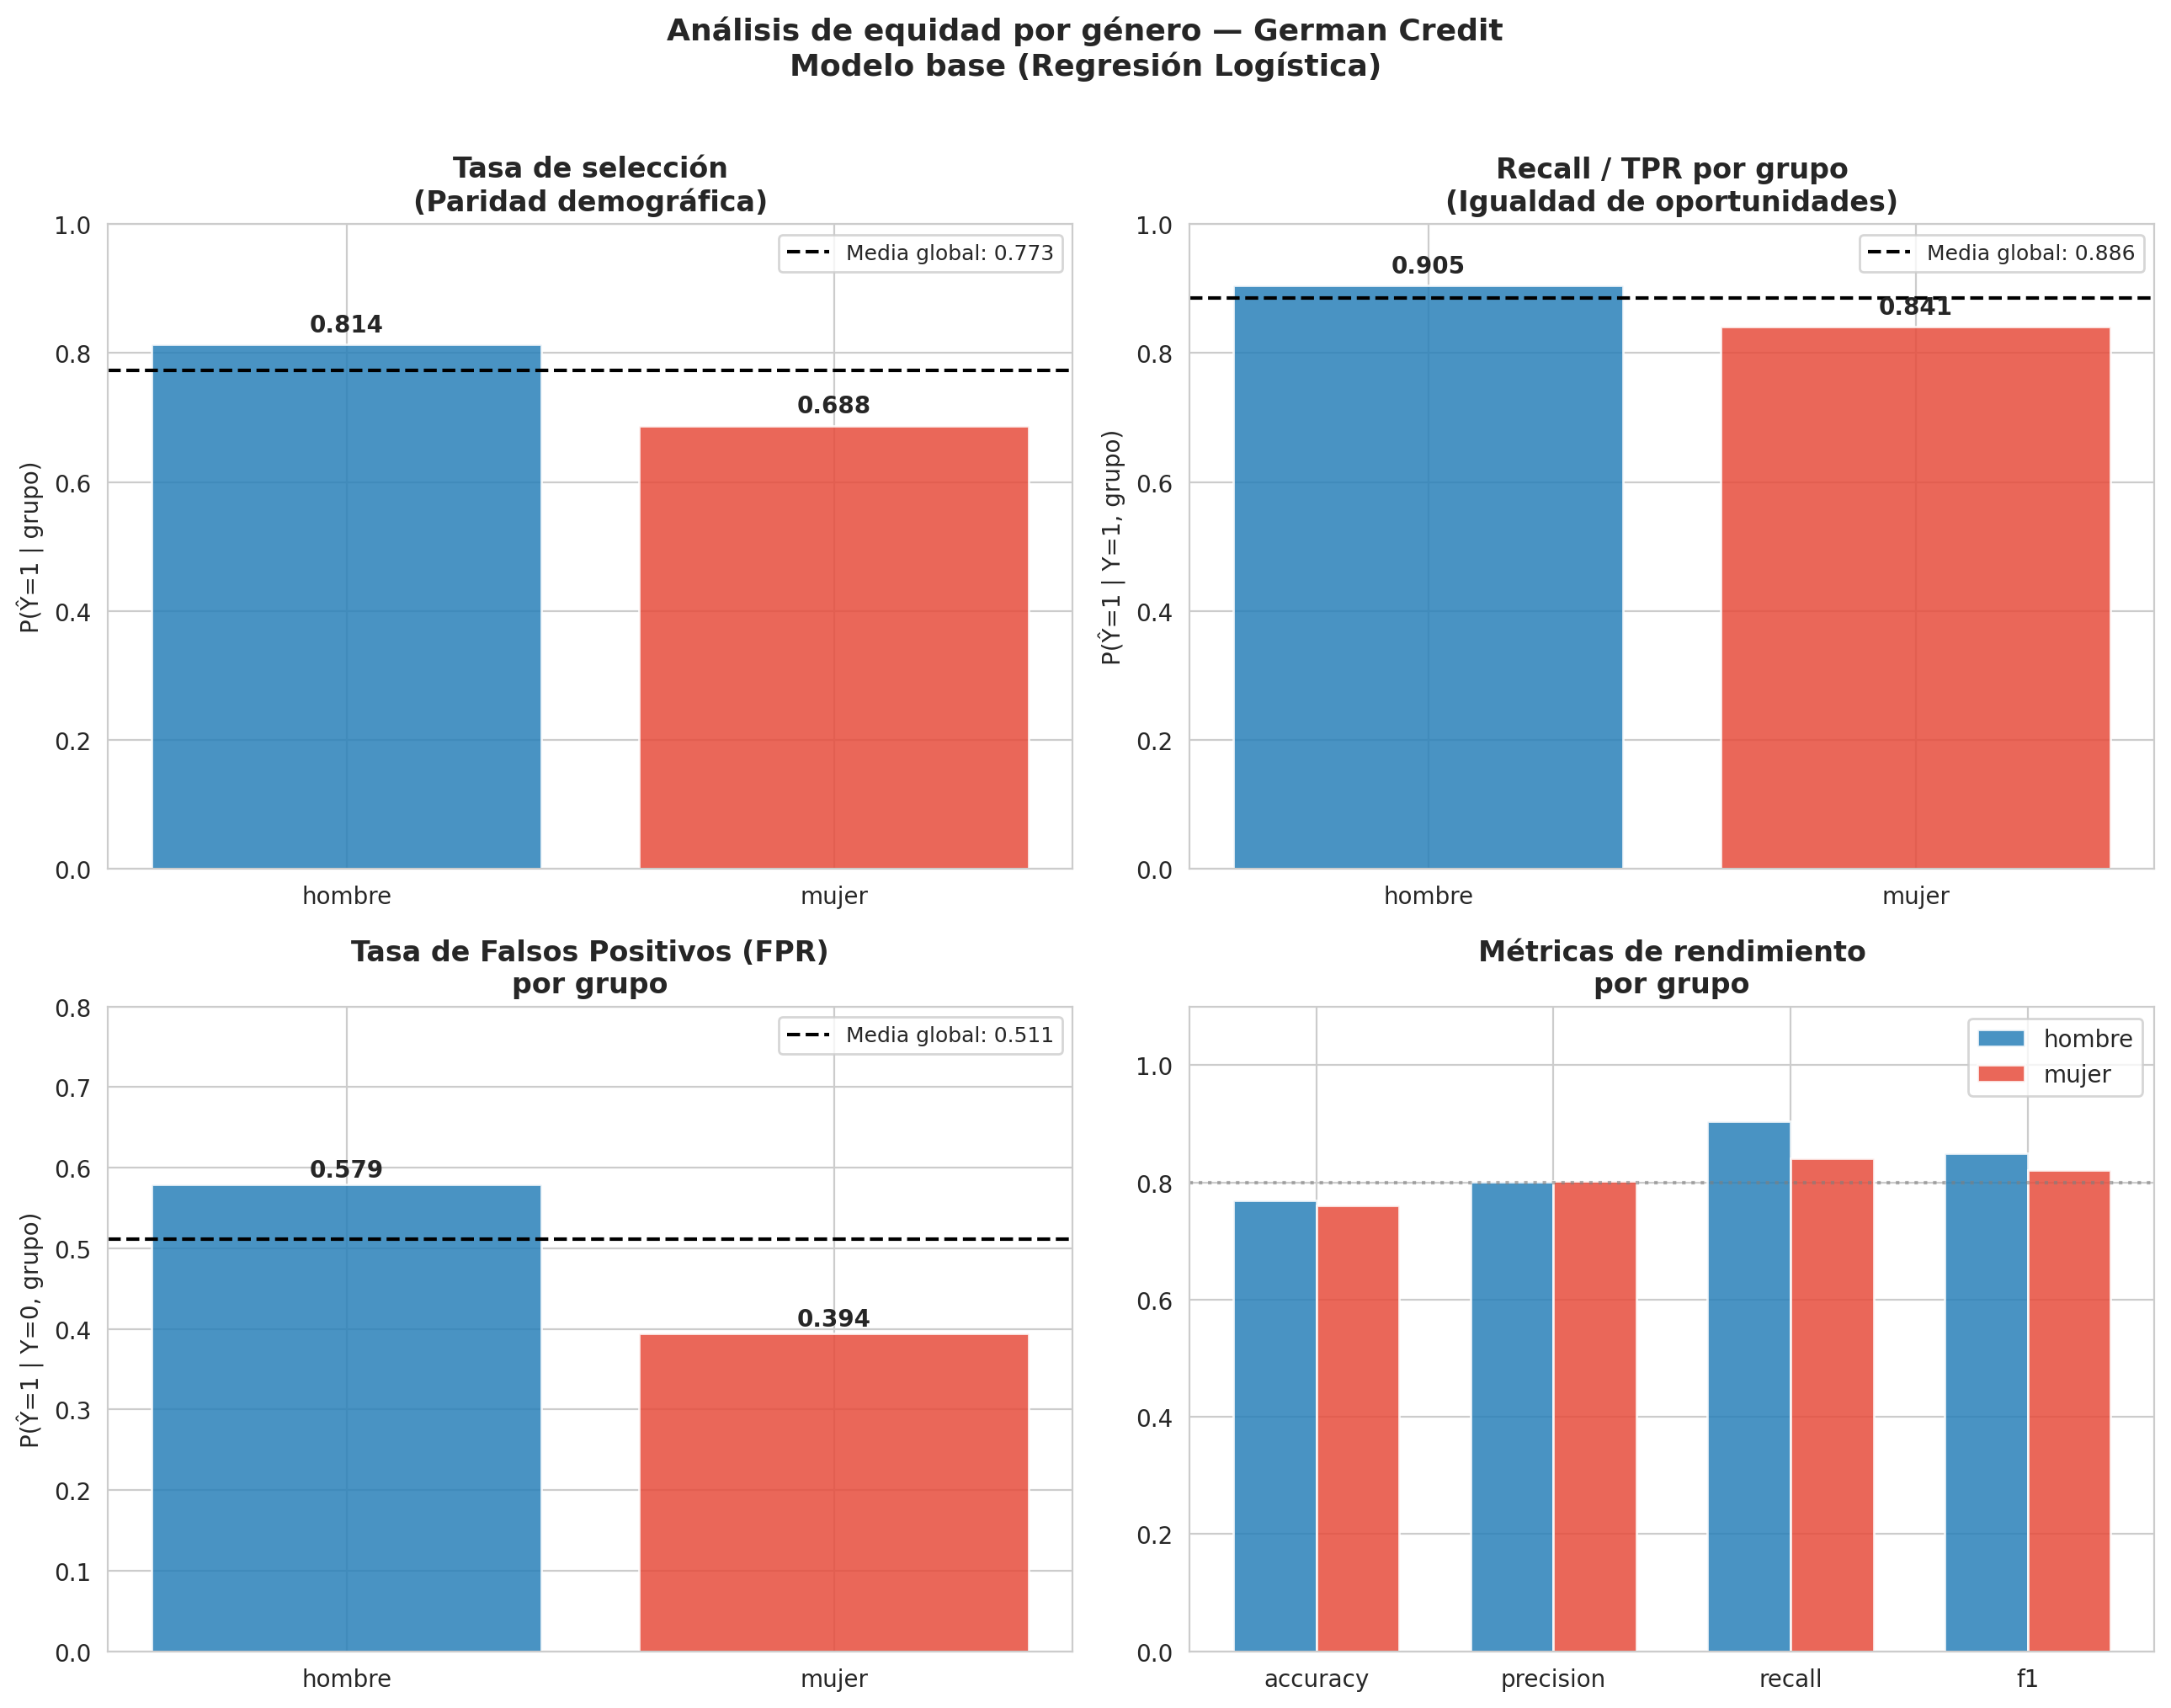

Gráfico guardado como equidad_german_credit.png


In [ ]:
#@title <font color="green">--- Visualización de la equidad </font>
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Análisis de equidad por género — German Credit\nModelo base (Regresión Logística)',
             fontsize=13, fontweight='bold', y=1.01)

grupos = mf.by_group.index.tolist()
colores = {'hombre': '#2980B9', 'mujer': '#E74C3C'}
color_list = [colores.get(g, '#95A5A6') for g in grupos]

# ── Panel 1: Tasa de selección (paridad demográfica) ──────────────────────────
ax = axes[0, 0]
vals = mf.by_group['sel_rate'].values
bars = ax.bar(grupos, vals, color=color_list, alpha=0.85, edgecolor='white')
ax.axhline(mf.overall['sel_rate'], color='black', linestyle='--', linewidth=1.5,
           label=f'Media global: {mf.overall["sel_rate"]:.3f}')
ax.set_title('Tasa de selección\n(Paridad demográfica)', fontweight='bold')
ax.set_ylabel('P(Ŷ=1 | grupo)')
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontweight='bold')

# ── Panel 2: Recall (igualdad de oportunidades) ───────────────────────────────
ax = axes[0, 1]
vals = mf.by_group['recall'].values
bars = ax.bar(grupos, vals, color=color_list, alpha=0.85, edgecolor='white')
ax.axhline(mf.overall['recall'], color='black', linestyle='--', linewidth=1.5,
           label=f'Media global: {mf.overall["recall"]:.3f}')
ax.set_title('Recall / TPR por grupo\n(Igualdad de oportunidades)', fontweight='bold')
ax.set_ylabel('P(Ŷ=1 | Y=1, grupo)')
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontweight='bold')

# ── Panel 3: FPR por grupo ────────────────────────────────────────────────────
ax = axes[1, 0]
vals_fpr = mf.by_group['fpr'].values
bars = ax.bar(grupos, vals_fpr, color=color_list, alpha=0.85, edgecolor='white')
ax.axhline(mf.overall['fpr'], color='black', linestyle='--', linewidth=1.5,
           label=f'Media global: {mf.overall["fpr"]:.3f}')
ax.set_title('Tasa de Falsos Positivos (FPR)\npor grupo', fontweight='bold')
ax.set_ylabel('P(Ŷ=1 | Y=0, grupo)')
ax.set_ylim(0, 0.8)
ax.legend(fontsize=9)
for bar, val in zip(bars, vals_fpr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold')

# ── Panel 4: Resumen de métricas normalizadas ─────────────────────────────────
ax = axes[1, 1]
metricas_plot = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metricas_plot))
w = 0.35
for i, grupo in enumerate(grupos):
    vals_g = [mf.by_group.loc[grupo, m] for m in metricas_plot]
    offset = (i - (len(grupos)-1)/2) * w
    bars_g = ax.bar(x + offset, vals_g, w, label=grupo,
                    color=color_list[i], alpha=0.85, edgecolor='white')

ax.set_title('Métricas de rendimiento\npor grupo', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas_plot, fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(0.8, color='gray', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('equidad_german_credit.png', dpi=130, bbox_inches='tight')
plt.show()
print("Gráfico guardado como equidad_german_credit.png")

## **3.8 Mitigación 1 · Preprocesamiento: Reweighing**

Ya vimos esta técnica en el bloque de sesgo. La incluimos aquí como referencia y punto de comparación con las siguientes.

In [ ]:
#@title <font color="green">--- Mitigación 1 -Preprocesamiento: Reweighing</font>
from aif360.datasets import GermanDataset
from aif360.algorithms.preprocessing import Reweighing as AIF_Reweighing
from aif360.metrics import ClassificationMetric
import os
import requests
from sklearn.linear_model import LogisticRegression

# Define the path where the dataset is expected
data_dir_german = '/usr/local/lib/python3.12/dist-packages/aif360/data/raw/german'
file_path_data = os.path.join(data_dir_german, 'german.data')
file_path_doc = os.path.join(data_dir_german, 'german.doc')

# Cargar German Credit desde AIF360 (con atributo sensible 'sex')
dataset_german = GermanDataset(
    protected_attribute_names=['sex'],
    privileged_classes=[lambda x: x == 1],  # 1 = hombre
    features_to_drop=['personal_status', 'age']
)

privileged_groups   = [{'sex': 1}]
unprivileged_groups = [{'sex': 0}]

# Split
train_aif, test_aif = dataset_german.split([0.7], shuffle=True, seed=42)

# Aplicar Reweighing
rw = AIF_Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)
train_rw = rw.fit_transform(train_aif)

# Entrenar con pesos
lr_rw = LogisticRegression(random_state=42, max_iter=1000)
lr_rw.fit(train_rw.features, train_rw.labels.ravel(),
          sample_weight=train_rw.instance_weights)

# Evaluar
pred_rw = test_aif.copy()
pred_rw.labels = lr_rw.predict(test_aif.features).reshape(-1, 1)

metric_rw = ClassificationMetric(
    test_aif, pred_rw,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

print(f"[Reweighing] Accuracy:              {metric_rw.accuracy():.4f}")
print(f"[Reweighing] Equal opportunity diff: {metric_rw.equal_opportunity_difference():.4f}")
print(f"[Reweighing] Average odds diff:      {metric_rw.average_odds_difference():.4f}")

[Reweighing] Accuracy:              0.7767
[Reweighing] Equal opportunity diff: nan
[Reweighing] Average odds diff:      nan


Para entender por qué las métricas de equidad (`Equal opportunity diff` y `Average odds diff`) resultaron en `nan` (Not a Number), es crucial verificar la distribución de las variables sensibles y sus etiquetas en el conjunto de datos de prueba (`test_aif`).

Los valores `nan` suelen aparecer cuando una de las combinaciones de grupo sensible y etiqueta (por ejemplo, `sex=1` con `Y=1`) no tiene instancias en el conjunto de datos, lo que provoca divisiones por cero al calcular tasas como el `True Positive Rate` o `False Positive Rate` para ese grupo.

In [ ]:
#@title <font color="green">--- Distribución de 'sex' y 'labels' en test_aif ---</font>
print("Total instancias en test_aif:", len(test_aif.features))

# Obtener los valores del atributo sensible 'sex'
sex_values = test_aif.protected_attributes.flatten()

# Obtener las etiquetas reales del dataset de prueba
labels_values = test_aif.labels.flatten()

# Crear un DataFrame temporal para inspeccionar la combinación
temp_df = pd.DataFrame({
    'sex': sex_values,
    'label': labels_values
})

print("\nDistribución de 'sex' en test_aif:")
print(temp_df['sex'].value_counts())

print("\nDistribución de etiquetas (credit_risk) en test_aif:")
print(temp_df['label'].value_counts())

print("\nDistribución combinada de 'sex' y 'label' en test_aif:")
print(temp_df.groupby(['sex', 'label']).size().unstack(fill_value=0))

# Verificar si faltan combinaciones críticas para el cálculo de métricas
privileged_sex_label_1_count = temp_df[(temp_df['sex'] == 1) & (temp_df['label'] == 1)].shape[0]
privileged_sex_label_0_count = temp_df[(temp_df['sex'] == 1) & (temp_df['label'] == 0)].shape[0]

if privileged_sex_label_1_count == 0:
    print("\n⚠️  Advertencia: No hay instancias de 'sex=1' (privileged) con 'label=1' (buen crédito) en test_aif.")
    print("    Esto puede causar 'nan' en Equal Opportunity Difference (TPR_privileged).")

if privileged_sex_label_0_count == 0:
    print("\n⚠️  Advertencia: No hay instancias de 'sex=1' (privileged) con 'label=0' (mal crédito) en test_aif.")
    print("    Esto puede causar 'nan' en Average Odds Difference (FPR_privileged).")

Total instancias en test_aif: 300

Distribución de 'sex' en test_aif:
sex
0.0    300
Name: count, dtype: int64

Distribución de etiquetas (credit_risk) en test_aif:
label
1.0    208
2.0     92
Name: count, dtype: int64

Distribución combinada de 'sex' y 'label' en test_aif:
label  1.0  2.0
sex            
0.0    208   92

⚠️  Advertencia: No hay instancias de 'sex=1' (privileged) con 'label=1' (buen crédito) en test_aif.
    Esto puede causar 'nan' en Equal Opportunity Difference (TPR_privileged).

⚠️  Advertencia: No hay instancias de 'sex=1' (privileged) con 'label=0' (mal crédito) en test_aif.
    Esto puede causar 'nan' en Average Odds Difference (FPR_privileged).


## **3.9 Mitigación 2 · Procesamiento: ExponentiatedGradient**

El `ExponentiatedGradient` de Fairlearn es un algoritmo de reducción: convierte el problema de ML con restricciones de equidad en una secuencia de problemas de ML estándar. En cada iteración, ajusta los pesos de las instancias para forzar al modelo a satisfacer la restricción de equidad elegida.

In [ ]:
#@title <font color="green">---Mitigación 2 · Procesamiento: ExponentiatedGradient</font>

from fairlearn.reductions import (
    ExponentiatedGradient,
    DemographicParity,
    EqualizedOdds,
    ErrorRateParity
)

# ── Variante A: restricción de Paridad Demográfica ────────────────────────────
print("Entrenando con ExponentiatedGradient + DemographicParity...")
eg_dp = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    constraints=DemographicParity(),
    eps=0.01,       # tolerancia: cuánta desviación de la equidad se permite
    max_iter=50
)
eg_dp.fit(X_train, y_train, sensitive_features=s_train)
y_pred_dp = eg_dp.predict(X_test)

# ── Variante B: restricción de Equalized Odds ─────────────────────────────────
print("Entrenando con ExponentiatedGradient + EqualizedOdds...")
eg_eo = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    constraints=EqualizedOdds(),
    eps=0.01,
    max_iter=50
)
eg_eo.fit(X_train, y_train, sensitive_features=s_train)
y_pred_eo = eg_eo.predict(X_test)

# ── Evaluar ambas variantes ───────────────────────────────────────────────────
for nombre, y_pred_m in [('DemographicParity', y_pred_dp),
                          ('EqualizedOdds',     y_pred_eo)]:
    dpd_m = demographic_parity_difference(y_test, y_pred_m, sensitive_features=s_test)
    eod_m = equalized_odds_difference(y_test, y_pred_m, sensitive_features=s_test)
    acc_m = accuracy_score(y_test, y_pred_m)
    print(f"\n[EG + {nombre}]")
    print(f"  Accuracy:                  {acc_m:.4f}")
    print(f"  Demographic parity diff:   {dpd_m:+.4f}")
    print(f"  Equalized odds diff:       {eod_m:+.4f}")

Entrenando con ExponentiatedGradient + DemographicParity...
Entrenando con ExponentiatedGradient + EqualizedOdds...

[EG + DemographicParity]
  Accuracy:                  0.7667
  Demographic parity diff:   +0.0539
  Equalized odds diff:       +0.0766

[EG + EqualizedOdds]
  Accuracy:                  0.7533
  Demographic parity diff:   +0.0594
  Equalized odds diff:       +0.0567


El modelo con DemographicParity consigue que hombres y mujeres reciban préstamos aprobados con la misma frecuencia, pero puede estar aprobando a mujeres con peor historial crediticio (o rechazando a hombres con buen historial) para cuadrar los porcentajes. El modelo con EqualizedOdds garantiza que las personas realmente solventes tienen las mismas probabilidades de ser aprobadas en ambos grupos, y que las insolventes tienen las mismas probabilidades de ser rechazadas — pero esto es más difícil de lograr y cuesta más accuracy.

## **3.10 Mitigación 3 · Postprocesamiento: ThresholdOptimizer**

El `ThresholdOptimizer` no modifica el entrenamiento: toma un modelo ya entrenado y aprende umbrales de decisión distintos para cada grupo, de forma que se satisfaga la restricción de equidad elegida mientras se maximiza el rendimiento global.

In [ ]:
#@title <font color="green">---Mitigación 3 · Postprocesamiento: ThresholdOptimizer</font>

from fairlearn.postprocessing import ThresholdOptimizer
import fairlearn

print(f"Fairlearn versión: {fairlearn.__version__}")
print("Ajustando ThresholdOptimizer sobre el modelo base...")

th_opt = ThresholdOptimizer(
    estimator=modelo_base,
    constraints="equalized_odds",
    objective="balanced_accuracy_score",
    predict_method="predict_proba",
    flip=True
)

th_opt.fit(X_train, y_train, sensitive_features=s_train)
y_pred_th = th_opt.predict(X_test, sensitive_features=s_test)

dpd_th = demographic_parity_difference(y_test, y_pred_th, sensitive_features=s_test)
eod_th = equalized_odds_difference(y_test, y_pred_th, sensitive_features=s_test)
acc_th = accuracy_score(y_test, y_pred_th)

print(f"\n[ThresholdOptimizer]")
print(f"  Accuracy:                {acc_th:.4f}")
print(f"  Demographic parity diff: {dpd_th:+.4f}")
print(f"  Equalized odds diff:     {eod_th:+.4f}")

# ── Inspeccionar umbrales en Fairlearn 0.13 ───────────────────────────────────
print("\nUmbrales de decisión aprendidos por grupo:")
print("  (umbral > 0.5 → más conservador | umbral < 0.5 → más permisivo)\n")

# En 0.13 los umbrales están en interpolated_thresholder_.interpolated_thresholders_
# que es un dict {grupo: InterpolatedThresholder}
try:
    thresholders = th_opt.interpolated_thresholder_.interpolated_thresholders_
    for grupo, it in thresholders.items():
        # Cada InterpolatedThresholder tiene p0, p1 y operation
        # operation es un ThresholdOperation con .operator y .threshold
        op  = it.operation
        print(f"  Grupo '{grupo}':")
        print(f"    · p0 (prob. de predecir 0): {it.p0:.4f}")
        print(f"    · p1 (prob. de predecir 1): {it.p1:.4f}")
        print(f"    · operador:                 {op.operator}")
        print(f"    · umbral de probabilidad:   {op.threshold:.4f}")

except AttributeError:
    # Fallback: reconstruir umbrales manualmente desde las probabilidades
    print("  Reconstruyendo umbrales manualmente...\n")

    proba_test = modelo_base.predict_proba(X_test)[:, 1]

    for grupo in s_test.unique():
        mask    = (s_test == grupo).values
        proba_g = proba_test[mask]
        pred_g  = y_pred_th[mask]

        # El umbral efectivo es el punto donde cambia la predicción
        # Lo aproximamos como la media entre el máximo proba que predice 0
        # y el mínimo proba que predice 1
        pred0_proba = proba_g[pred_g == 0]
        pred1_proba = proba_g[pred_g == 1]

        if len(pred0_proba) > 0 and len(pred1_proba) > 0:
            umbral_aprox = (pred0_proba.max() + pred1_proba.min()) / 2
        else:
            umbral_aprox = 0.5

        tasa_positiva = pred_g.mean()
        print(f"  Grupo '{grupo}':")
        print(f"    · Umbral aproximado:    {umbral_aprox:.4f}")
        print(f"    · Tasa de aprobación:   {tasa_positiva:.4f}")
        print(f"    · n instancias:         {mask.sum()}")

Fairlearn versión: 0.13.0
Ajustando ThresholdOptimizer sobre el modelo base...

[ThresholdOptimizer]
  Accuracy:                0.7367
  Demographic parity diff: +0.1072
  Equalized odds diff:     +0.0884

Umbrales de decisión aprendidos por grupo:
  (umbral > 0.5 → más conservador | umbral < 0.5 → más permisivo)

  Reconstruyendo umbrales manualmente...

  Grupo 'mujer':
    · Umbral aproximado:    0.8027
    · Tasa de aprobación:   0.5104
    · n instancias:         96
  Grupo 'hombre':
    · Umbral aproximado:    0.6979
    · Tasa de aprobación:   0.6176
    · n instancias:         204


## **3.11 Comparativa completa: todos los métodos**


In [ ]:
#@title <font color="green">── Tabla comparativa final ───</font>
from sklearn.metrics import f1_score

def eval_completo(nombre, y_pred_m, s_feat=s_test, y_true=y_test):
    return {
        'Método': nombre,
        'Accuracy': round(accuracy_score(y_true, y_pred_m), 4),
        'F1': round(f1_score(y_true, y_pred_m), 4),
        'DPD': round(demographic_parity_difference(
                        y_true, y_pred_m, sensitive_features=s_feat), 4),
        'EOD': round(equalized_odds_difference(
                        y_true, y_pred_m, sensitive_features=s_feat), 4),
    }

resultados = pd.DataFrame([
    eval_completo('Modelo base (sin mitigación)', y_pred_base),
    eval_completo('EG + DemographicParity',        y_pred_dp),
    eval_completo('EG + EqualizedOdds',             y_pred_eo),
    eval_completo('ThresholdOptimizer',             y_pred_th),
])

print("═" * 75)
print("COMPARATIVA COMPLETA — Rendimiento vs. Equidad")
print("DPD = Demographic Parity Difference | EOD = Equalized Odds Difference")
print("Valores ideales de equidad: DPD = 0, EOD = 0")
print("═" * 75)
print(resultados.to_string(index=False))
print("═" * 75)

# Identificar el mejor método de mitigación
mejor = resultados.iloc[1:].copy()
mejor['score_equidad'] = mejor['DPD'].abs() + mejor['EOD'].abs()
mejor_metodo = mejor.loc[mejor['score_equidad'].idxmin(), 'Método']
print(f"\n🏆 Mejor método de mitigación (menor suma |DPD|+|EOD|): {mejor_metodo}")

═══════════════════════════════════════════════════════════════════════════
COMPARATIVA COMPLETA — Rendimiento vs. Equidad
DPD = Demographic Parity Difference | EOD = Equalized Odds Difference
Valores ideales de equidad: DPD = 0, EOD = 0
═══════════════════════════════════════════════════════════════════════════
                      Método  Accuracy     F1    DPD    EOD
Modelo base (sin mitigación)    0.7667 0.8416 0.1262 0.1850
      EG + DemographicParity    0.7667 0.8430 0.0539 0.0766
          EG + EqualizedOdds    0.7533 0.8333 0.0594 0.0567
          ThresholdOptimizer    0.7367 0.7948 0.1072 0.0884
═══════════════════════════════════════════════════════════════════════════

🏆 Mejor método de mitigación (menor suma |DPD|+|EOD|): EG + EqualizedOdds


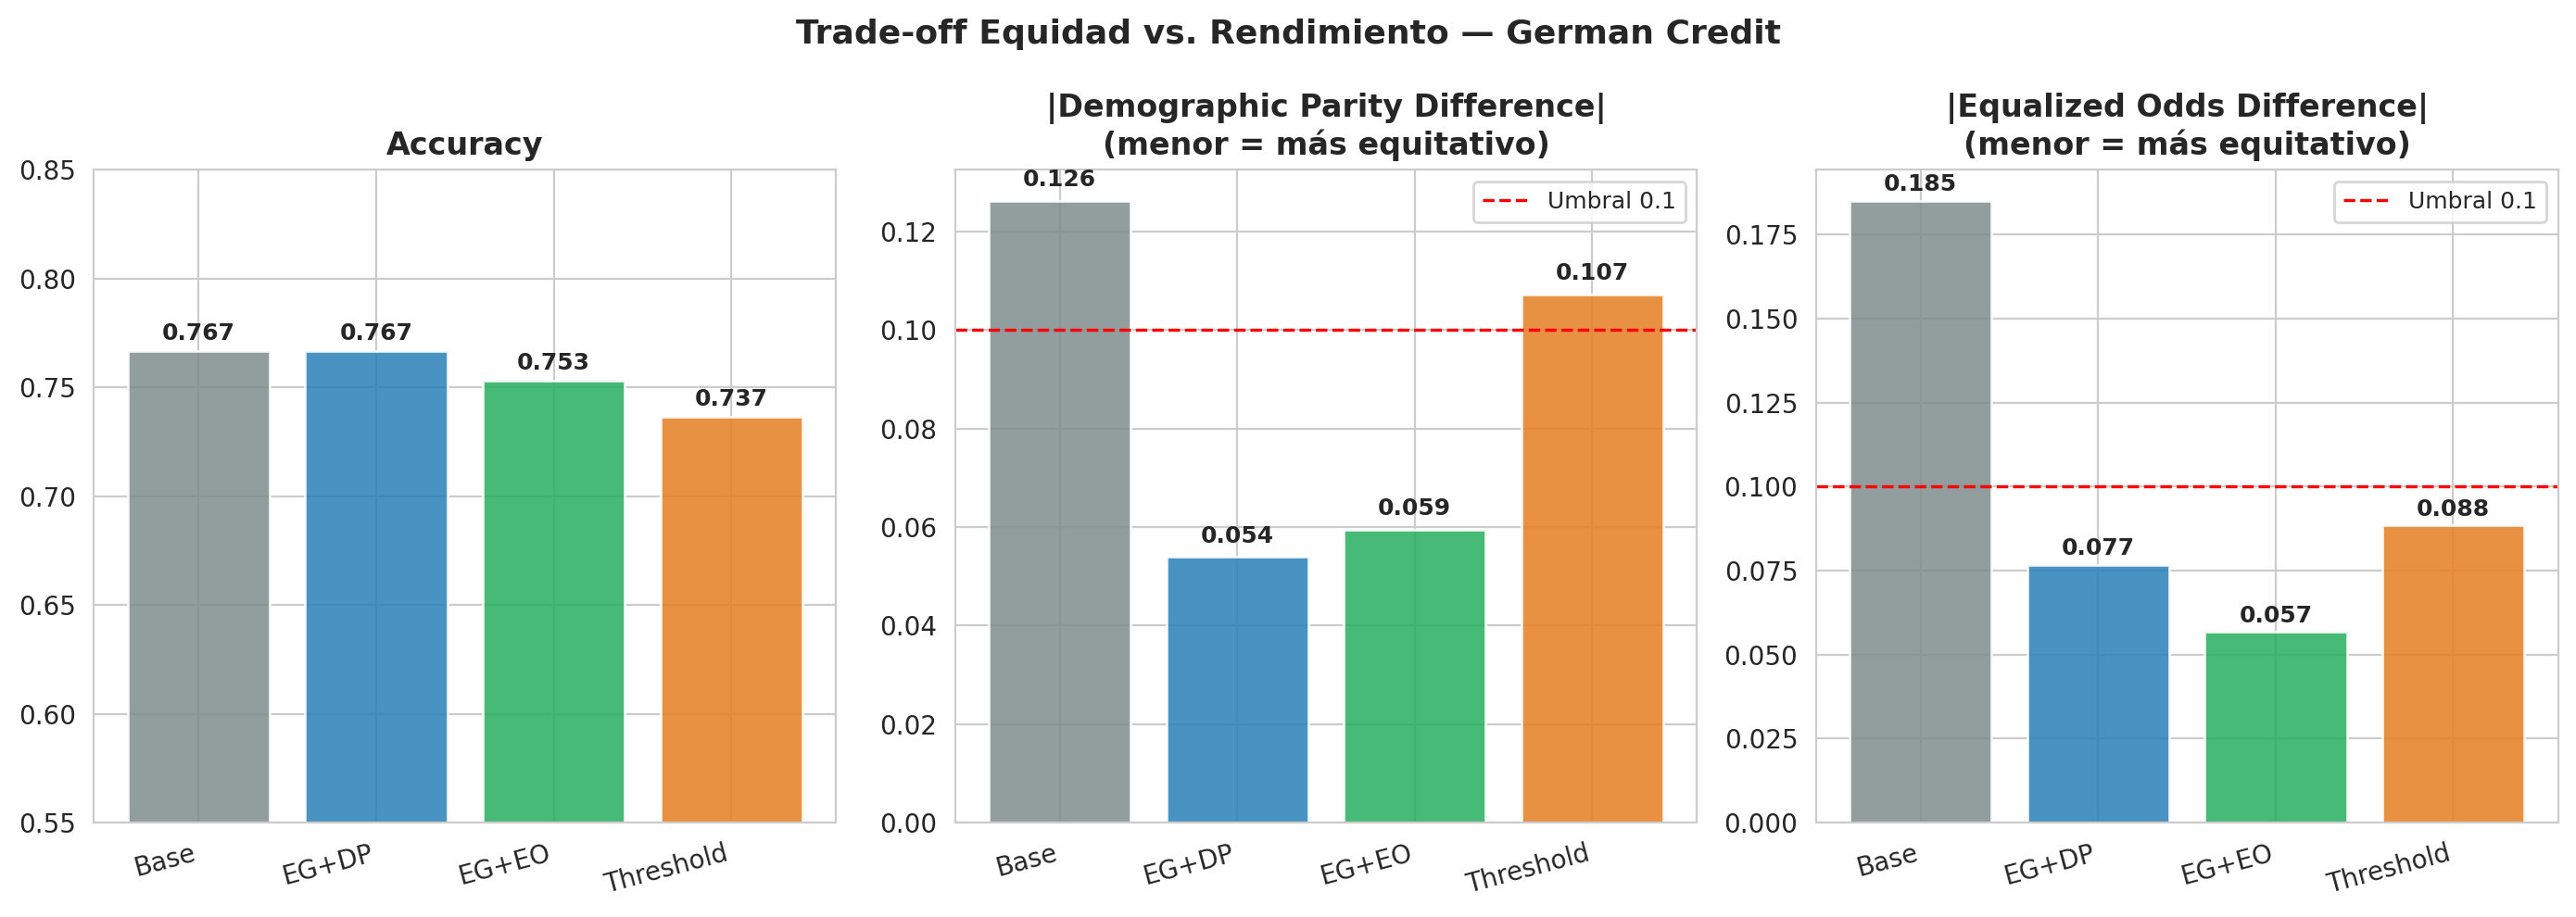

Gráfico guardado como comparativa_mitigacion.png


In [ ]:
#@title <font color="green">── Visualización comparativa ────</font>
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Trade-off Equidad vs. Rendimiento — German Credit',
             fontsize=13, fontweight='bold')

metodos = resultados['Método'].tolist()
colores_m = ['#7F8C8D', '#2980B9', '#27AE60', '#E67E22']
x = np.arange(len(metodos))

def short_labels(names):
    return ['Base', 'EG+DP', 'EG+EO', 'Threshold']

labels_short = short_labels(metodos)

# Accuracy
axes[0].bar(x, resultados['Accuracy'], color=colores_m, alpha=0.85, edgecolor='white')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_short, rotation=15, ha='right')
axes[0].set_ylim(0.55, 0.85)
for i, v in enumerate(resultados['Accuracy']):
    axes[0].text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# DPD
vals_dpd = resultados['DPD'].values
axes[1].bar(x, np.abs(vals_dpd), color=colores_m, alpha=0.85, edgecolor='white')
axes[1].axhline(0.1, color='red', linestyle='--', linewidth=1.2,
                label='Umbral 0.1')
axes[1].set_title('|Demographic Parity Difference|\n(menor = más equitativo)', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_short, rotation=15, ha='right')
axes[1].legend(fontsize=9)
for i, v in enumerate(np.abs(vals_dpd)):
    axes[1].text(i, v+0.003, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# EOD
vals_eod = resultados['EOD'].values
axes[2].bar(x, np.abs(vals_eod), color=colores_m, alpha=0.85, edgecolor='white')
axes[2].axhline(0.1, color='red', linestyle='--', linewidth=1.2,
                label='Umbral 0.1')
axes[2].set_title('|Equalized Odds Difference|\n(menor = más equitativo)', fontweight='bold')
axes[2].set_xticks(x); axes[2].set_xticklabels(labels_short, rotation=15, ha='right')
axes[2].legend(fontsize=9)
for i, v in enumerate(np.abs(vals_eod)):
    axes[2].text(i, v+0.003, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('comparativa_mitigacion.png', dpi=130, bbox_inches='tight')
plt.show()
print("Gráfico guardado como comparativa_mitigacion.png")

## **3.12 La frontera de Pareto: equidad vs. rendimiento**

Un concepto clave en mitigación de sesgo es que la relación entre equidad y rendimiento forma una **frontera de Pareto**: no es posible mejorar la equidad sin sacrificar algo de rendimiento (y viceversa). La pregunta práctica es: ¿cuánto rendimiento estamos dispuestos a sacrificar por cuánta equidad?

Explorando la frontera de Pareto (equidad vs. rendimiento)...
Esto puede tardar 1–2 minutos...

  eps  accuracy    eod
0.001    0.7533 0.0476
0.005    0.7600 0.0476
0.010    0.7700 0.1547
0.020    0.7767 0.0893
0.050    0.7633 0.0941
0.100    0.7667 0.1069
0.200    0.7600 0.1244


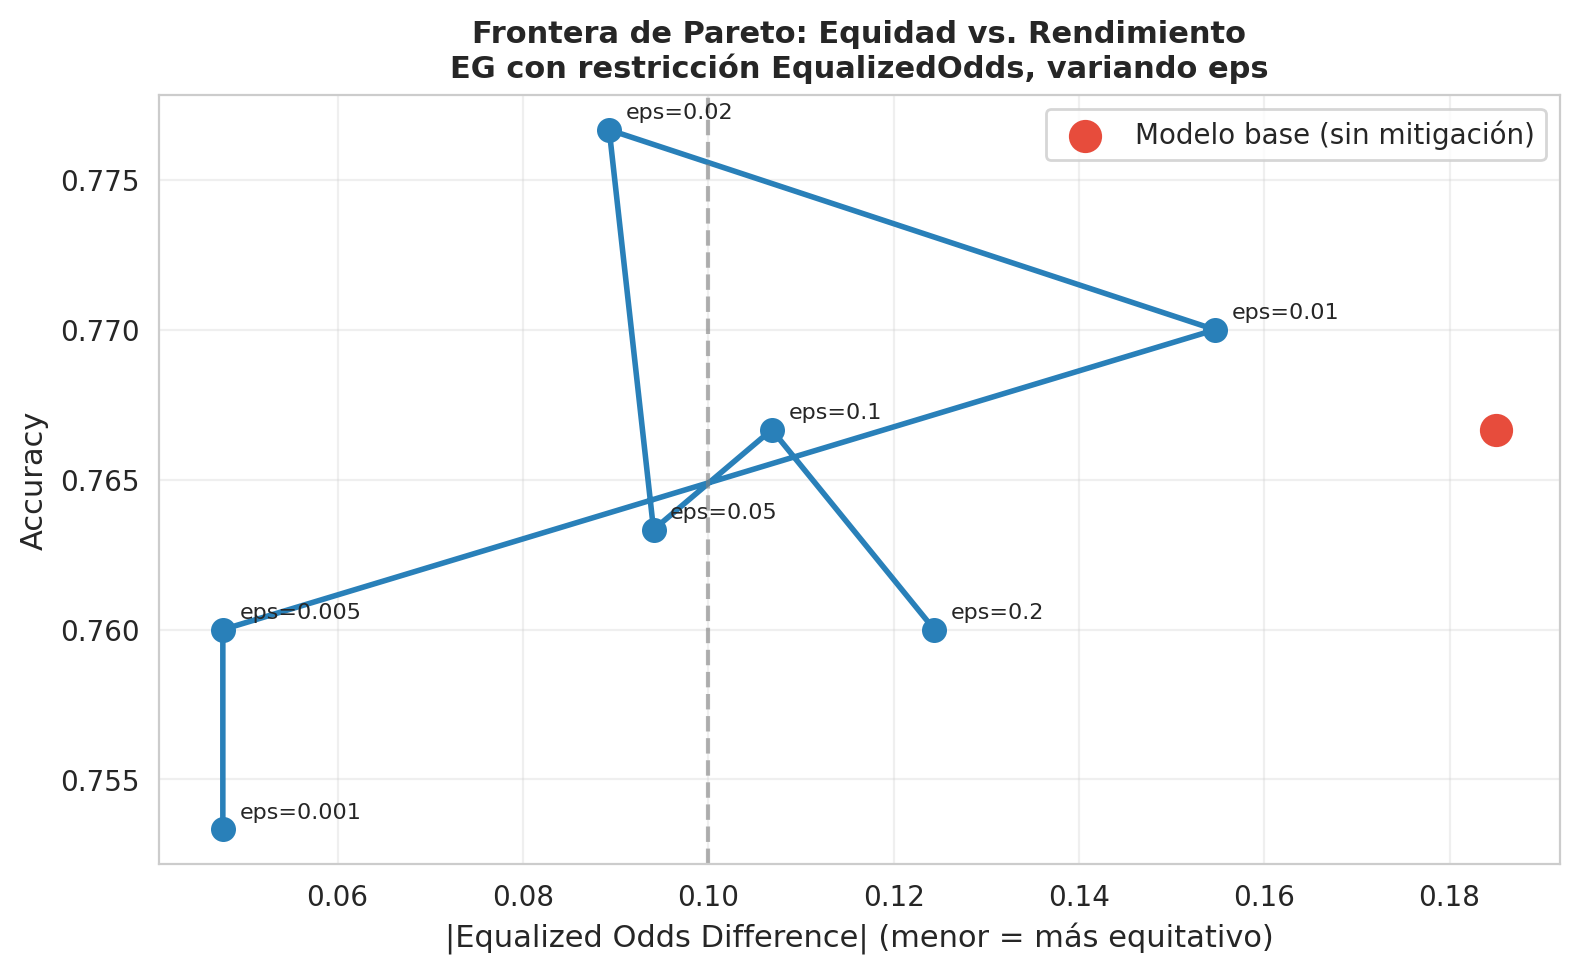

Gráfico guardado como frontera_pareto.png


In [ ]:
#@title <font color="green">── Explorar la frontera de Pareto variando el parámetro eps ───</font>
print("Explorando la frontera de Pareto (equidad vs. rendimiento)...")
print("Esto puede tardar 1–2 minutos...\n")

resultados_pareto = []
for eps in [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]:
    try:
        eg = ExponentiatedGradient(
            estimator=LogisticRegression(max_iter=500, random_state=42),
            constraints=EqualizedOdds(),
            eps=eps, max_iter=30
        )
        eg.fit(X_train, y_train, sensitive_features=s_train)
        y_p = eg.predict(X_test)
        resultados_pareto.append({
            'eps': eps,
            'accuracy': accuracy_score(y_test, y_p),
            'eod': abs(equalized_odds_difference(y_test, y_p, sensitive_features=s_test))
        })
    except Exception:
        pass

df_pareto = pd.DataFrame(resultados_pareto)
print(df_pareto.round(4).to_string(index=False))

# Visualizar la frontera
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_pareto['eod'], df_pareto['accuracy'],
        'o-', color='#2980B9', markersize=8, linewidth=2)
for _, row in df_pareto.iterrows():
    ax.annotate(f"eps={row['eps']}",
                (row['eod'], row['accuracy']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

# Punto del modelo base
acc_base = accuracy_score(y_test, y_pred_base)
eod_base = abs(equalized_odds_difference(y_test, y_pred_base, sensitive_features=s_test))
ax.scatter([eod_base], [acc_base], color='#E74C3C', s=120, zorder=5,
           label='Modelo base (sin mitigación)')

ax.set_xlabel('|Equalized Odds Difference| (menor = más equitativo)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Frontera de Pareto: Equidad vs. Rendimiento\n'
             'EG con restricción EqualizedOdds, variando eps',
             fontsize=11, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.axvline(0.1, color='gray', linestyle='--', alpha=0.6, label='Umbral 0.1')
plt.tight_layout()
plt.savefig('frontera_pareto.png', dpi=130, bbox_inches='tight')
plt.show()
print("Gráfico guardado como frontera_pareto.png")

## **3.13 Guía de decisión: ¿qué métrica de equidad usar?**

Esta guía práctica ayuda a elegir la métrica adecuada según el contexto:

```
¿El coste de los dos tipos de error es muy diferente para el grupo no privilegiado?
│
├── SÍ: el peor error es clasificar negativamente a alguien calificado
│   └── Usar IGUALDAD DE OPORTUNIDADES (TPR igual)
│       Ejemplo: diagnóstico médico, selección de candidatos calificados
│
├── SÍ: el peor error es clasificar positivamente a alguien no calificado
│   └── Usar IGUALDAD DE FPR
│       Ejemplo: sistemas de detección donde los falsos positivos tienen
│       consecuencias graves (arrestos, lista negra)
│
├── Ambos errores son igualmente problemáticos
│   └── Usar EQUALIZED ODDS (TPR y FPR iguales)
│       Ejemplo: predicción de riesgo de crédito
│
└── Lo que importa es la proporción final de resultados positivos
    └── Usar PARIDAD DEMOGRÁFICA
        Ejemplo: publicidad, contratación con cuotas de representación
```

In [ ]:
#@title <font color="green">Resumen visual de la guía de decisión</font>
guia = {
    'Igualdad de oportunidades': {
        'métrica': 'TPR igual entre grupos',
        'cuándo': 'Falsos negativos más dañinos para el grupo no privilegiado',
        'ejemplo': 'Diagnóstico médico, admisión universitaria',
        'fairlearn': 'EqualizedOdds con énfasis en TPR / TruePositiveRateParity'
    },
    'Paridad demográfica': {
        'métrica': 'P(Ŷ=1|A) igual entre grupos',
        'cuándo': 'Se busca representación proporcional en los resultados',
        'ejemplo': 'Contratación con cuotas, publicidad inclusiva',
        'fairlearn': 'DemographicParity'
    },
    'Equalized odds': {
        'métrica': 'TPR y FPR iguales entre grupos',
        'cuándo': 'Ambos tipos de error son relevantes',
        'ejemplo': 'Predicción de riesgo de crédito, recidivismo',
        'fairlearn': 'EqualizedOdds'
    },
    'Calibración': {
        'métrica': 'P(Y=1|score=s) igual entre grupos',
        'cuándo': 'Las puntuaciones de probabilidad se usan directamente',
        'ejemplo': 'Seguros, modelos de scoring médico',
        'fairlearn': 'No implementada directamente; usar sklearn.calibration'
    },
}

for nombre, info in guia.items():
    print(f"\n{'─'*55}")
    print(f"  {nombre.upper()}")
    print(f"{'─'*55}")
    for k, v in info.items():
        print(f"  {k:<12}: {v}")


───────────────────────────────────────────────────────
  IGUALDAD DE OPORTUNIDADES
───────────────────────────────────────────────────────
  métrica     : TPR igual entre grupos
  cuándo      : Falsos negativos más dañinos para el grupo no privilegiado
  ejemplo     : Diagnóstico médico, admisión universitaria
  fairlearn   : EqualizedOdds con énfasis en TPR / TruePositiveRateParity

───────────────────────────────────────────────────────
  PARIDAD DEMOGRÁFICA
───────────────────────────────────────────────────────
  métrica     : P(Ŷ=1|A) igual entre grupos
  cuándo      : Se busca representación proporcional en los resultados
  ejemplo     : Contratación con cuotas, publicidad inclusiva
  fairlearn   : DemographicParity

───────────────────────────────────────────────────────
  EQUALIZED ODDS
───────────────────────────────────────────────────────
  métrica     : TPR y FPR iguales entre grupos
  cuándo      : Ambos tipos de error son relevantes
  ejemplo     : Predicción de riesgo 

## **3.14 Ejercicios propuestos**

> **Ejercicio 1 (básico):** Carga el dataset Adult Income (`from fairlearn.datasets import fetch_adult`) y calcula el `MetricFrame` con las métricas accuracy, precision, recall y FPR, desagregadas por la variable `sex`. ¿Qué grupo recibe más predicciones positivas (ingresos >50K)? ¿Es el modelo equitativo según la paridad demográfica?

> **Ejercicio 2 (intermedio):** Sobre el dataset German Credit visto en este bloque, entrena un `GradientBoostingClassifier` en lugar de regresión logística. Aplica los tres métodos de mitigación (Reweighing, ExponentiatedGradient + EqualizedOdds, ThresholdOptimizer). ¿Cambian los resultados respecto al modelo lineal? ¿Qué método logra mejor trade-off equidad/rendimiento con el modelo de gradient boosting?

> **Ejercicio 3 (avanzado):** Explora la frontera de Pareto para el dataset COMPAS usando el `ExponentiatedGradient` con tres restricciones distintas: `DemographicParity`, `EqualizedOdds` y `ErrorRateParity`. Para cada restricción, varía `eps` entre 0.001 y 0.2 y grafica la frontera. ¿Qué restricción ofrece el mejor trade-off? ¿A qué coste en accuracy llega la equidad perfecta (eps muy pequeño)?

> **Ejercicio 4 (reflexión):** Un sistema de scoring crediticio debe decidir entre implementar paridad demográfica o calibración como métrica de equidad. Redacta un análisis de 400–500 palabras desde la perspectiva de: (a) el banco que usa el sistema, (b) una persona del grupo no privilegiado que solicita crédito, y (c) un regulador del AI Act. ¿Qué definiría como "justo" cada parte? ¿Hay una respuesta correcta?


## **Referencias del bloque**

| Recurso | Tipo | Enlace |
|---|---|---|
| Fairlearn — documentación oficial | Librería | https://fairlearn.org |
| Fairlearn — ejemplos y notebooks | Notebooks | https://fairlearn.org/v0.10/auto_examples |
| Chouldechova (2017) — Teorema de imposibilidad | Artículo | https://arxiv.org/abs/1703.00056 |
| Hardt, Price & Srebro (2016) — Equalized Odds | Artículo | https://arxiv.org/abs/1610.02413 |
| *Fairness and Machine Learning* (cap. 2 y 3) | Libro gratuito | https://fairmlbook.org |
| German Credit Dataset (UCI) | Dataset | https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data) |
| Barocas & Selbst (2016) — Big Data's Disparate Impact | Artículo legal | https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2477899 |
| Tutorial NIST sobre métricas de equidad | Informe técnico | https://www.nist.gov/system/files/documents/2022/03/17/AI-RMF-Concept-Paper.pdf |


# **4. Privacidad diferencial y protección de datos**

## **4.1 ¿Por qué la privacidad es un problema de ML?**

Cuando entrenamos un modelo de ML, intuitivamente pensamos que los datos "desaparecen" dentro de los pesos del modelo. La realidad es más compleja: **los modelos memorizan información de sus datos de entrenamiento**, y esa información puede extraerse mediante ataques deliberados.

Este no es un problema teórico. En 2021, investigadores de Google demostraron que GPT-2 memorizaba verbatim números de teléfono, direcciones y fragmentos de texto privado presentes en su dataset de entrenamiento. En 2023, Samsung tuvo que prohibir el uso de ChatGPT a sus empleados después de que varios ingenieros pegaran código fuente propietario en el chat, que potencialmente quedó incorporado al modelo.

La privacidad en ML tiene tres dimensiones:

| Dimensión | Pregunta | Herramientas |
|---|---|---|
| **Privacidad de los datos** | ¿Están protegidos los datos de entrenamiento? | Anonimización, k-anonimato, seudonimización |
| **Privacidad del modelo** | ¿Puede el modelo revelar datos de entrenamiento? | Privacidad diferencial, machine unlearning |
| **Privacidad en inferencia** | ¿Revelan las predicciones información sensible? | Predicciones agregadas, output perturbation |


## **4.2 Tipos de ataques a la privacidad en ML**

Antes de ver las defensas, es fundamental entender qué tipos de ataques existen. Conocer el adversario es el primer paso para protegerse.

### 4.2.1 Ataque de pertenencia (*Membership Inference Attack*)

**Objetivo:** determinar si una muestra concreta estuvo en el dataset de entrenamiento.

**Mecanismo:** los modelos tienden a tener mayor confianza (probabilidad más alta) en ejemplos que han visto durante el entrenamiento que en ejemplos nuevos. Un atacante puede explotar esta diferencia.

═══════════════════════════════════════════════════════
DEMOSTRACIÓN: Ataque de pertenencia
═══════════════════════════════════════════════════════

Confianza media en train (miembros):    0.9040
Confianza media en test  (no miembros): 0.7611

Diferencia: 0.1429
→ Una diferencia alta indica que el modelo memoriza datos de entrenamiento.
  Un atacante que observe las probabilidades puede inferir pertenencia.

Accuracy del ataque de pertenencia: 0.7460
  (0.50 = aleatorio | >0.60 = ataque exitoso | >0.70 = ataque grave)


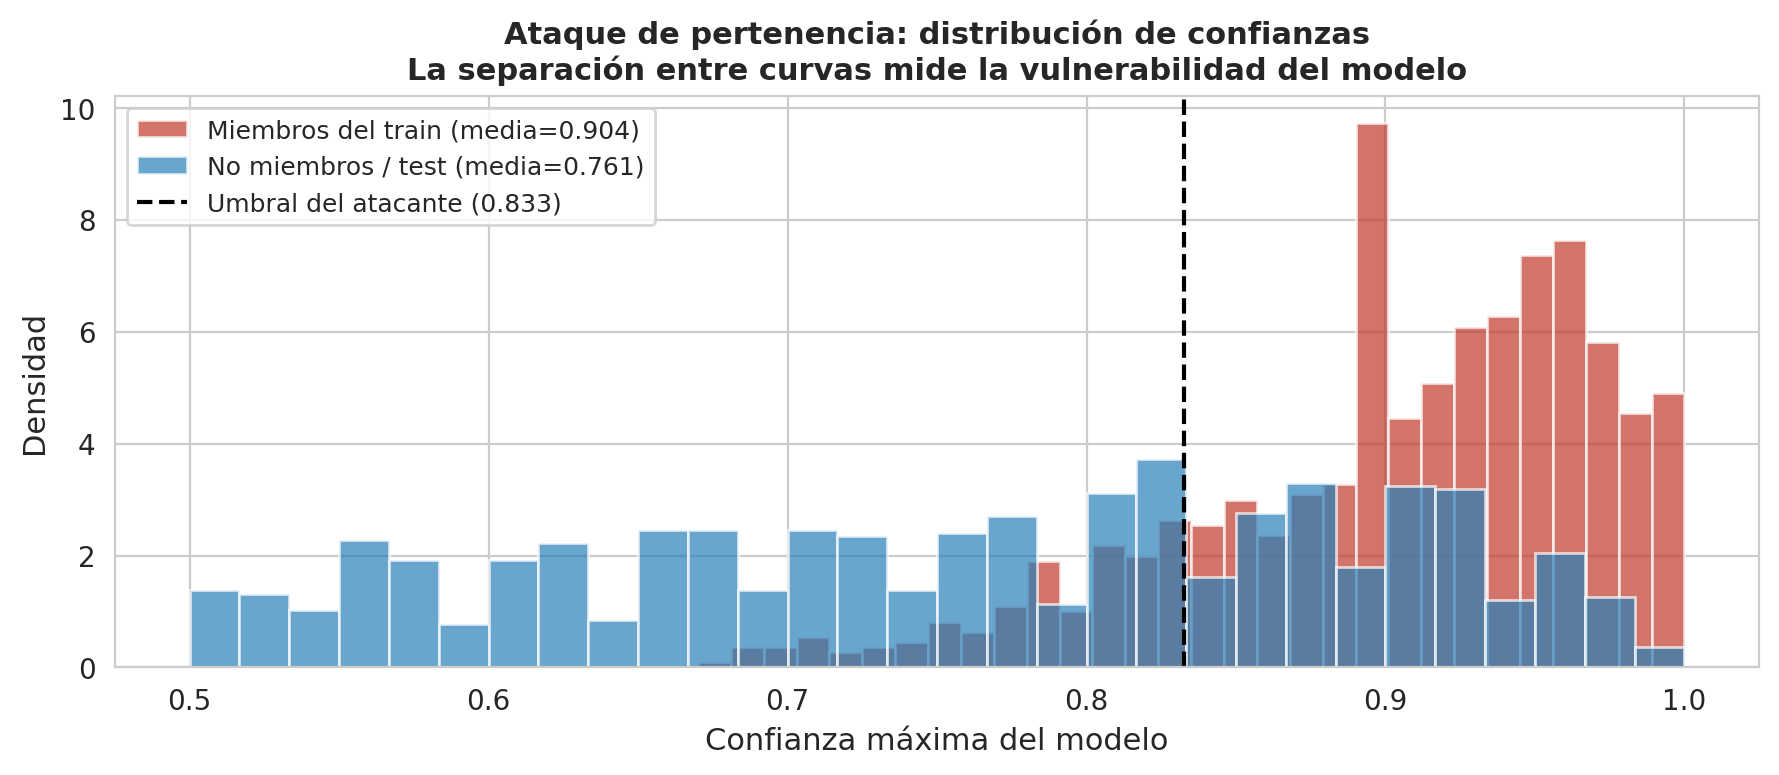

In [ ]:
#@title <font color="green">── Demostración de ataque de pertenencia ─────</font>
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ── Demostración de ataque de pertenencia ─────────────────────────────────────
np.random.seed(42)

# Dataset sintético
X, y = make_classification(n_samples=2000, n_features=20,
                            n_informative=10, random_state=42)
X_train_mem, X_test_mem, y_train_mem, y_test_mem = train_test_split(
    X, y, test_size=0.5, random_state=42
)

# Entrenar modelo "víctima" (overfit deliberado para ilustrar el ataque)
from sklearn.ensemble import RandomForestClassifier
modelo_victima = RandomForestClassifier(n_estimators=100, max_depth=None,
                                         random_state=42)
modelo_victima.fit(X_train_mem, y_train_mem)

# ── El atacante obtiene las probabilidades de predicción ──────────────────────
# Para miembros del train set (el atacante tiene acceso a algunas muestras)
proba_train = modelo_victima.predict_proba(X_train_mem)
conf_train  = proba_train.max(axis=1)   # confianza máxima

# Para no miembros (test set)
proba_test_mem = modelo_victima.predict_proba(X_test_mem)
conf_test_mem  = proba_test_mem.max(axis=1)

print("═" * 55)
print("DEMOSTRACIÓN: Ataque de pertenencia")
print("═" * 55)
print(f"\nConfianza media en train (miembros):    {conf_train.mean():.4f}")
print(f"Confianza media en test  (no miembros): {conf_test_mem.mean():.4f}")
print(f"\nDiferencia: {conf_train.mean() - conf_test_mem.mean():.4f}")
print("→ Una diferencia alta indica que el modelo memoriza datos de entrenamiento.")
print("  Un atacante que observe las probabilidades puede inferir pertenencia.")

# ── El "clasificador de pertenencia" del atacante ─────────────────────────────
# El atacante entrena un clasificador simple:
# alta confianza → probablemente miembro del train
# baja confianza → probablemente no miembro
umbral_ataque = (conf_train.mean() + conf_test_mem.mean()) / 2
pred_miembro_train = (conf_train >= umbral_ataque).astype(int)
pred_miembro_test  = (conf_test_mem >= umbral_ataque).astype(int)

# Accuracy del ataque (50% = aleatorio, >60% = ataque efectivo)
labels_miembro = np.concatenate([np.ones(len(conf_train)),
                                  np.zeros(len(conf_test_mem))])
preds_miembro  = np.concatenate([pred_miembro_train, pred_miembro_test])
acc_ataque = accuracy_score(labels_miembro, preds_miembro)

print(f"\nAccuracy del ataque de pertenencia: {acc_ataque:.4f}")
print(f"  (0.50 = aleatorio | >0.60 = ataque exitoso | >0.70 = ataque grave)")

# Visualizar distribución de confianzas
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(conf_train, bins=30, alpha=0.7, color='#C0392B',
        label=f'Miembros del train (media={conf_train.mean():.3f})', density=True)
ax.hist(conf_test_mem, bins=30, alpha=0.7, color='#2980B9',
        label=f'No miembros / test (media={conf_test_mem.mean():.3f})', density=True)
ax.axvline(umbral_ataque, color='black', linestyle='--', linewidth=1.5,
           label=f'Umbral del atacante ({umbral_ataque:.3f})')
ax.set_xlabel('Confianza máxima del modelo', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.set_title('Ataque de pertenencia: distribución de confianzas\n'
             'La separación entre curvas mide la vulnerabilidad del modelo',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 4.2.2 Ataque de inversión de modelo (*Model Inversion*)

**Objetivo:** reconstruir los datos de entrenamiento a partir de las predicciones del modelo.

**Mecanismo:** dado acceso a las probabilidades de salida, el atacante optimiza iterativamente una entrada sintética para maximizar la confianza del modelo en una clase objetivo. Esto puede reconstruir características medias de los ejemplos de entrenamiento de esa clase.

In [ ]:
#@title <font color="green">── Ilustración conceptual de model inversion ────</font>
# (versión simplificada para clasificación tabular)

from sklearn.preprocessing import StandardScaler

# Modelo víctima entrenado sobre datos normalizados
scaler_inv = StandardScaler()
X_norm = scaler_inv.fit_transform(X_train_mem)
modelo_inv = LogisticRegression(max_iter=1000, random_state=42)
modelo_inv.fit(X_norm, y_train_mem)

# El atacante intenta reconstruir el "prototipo" de la clase 1
# usando gradiente ascendente sobre la probabilidad de la clase objetivo
np.random.seed(0)
x_reconstruido = np.random.randn(1, X_train_mem.shape[1])  # inicio aleatorio
lr_inv  = 0.05
n_iters = 300

for _ in range(n_iters):
    proba = modelo_inv.predict_proba(x_reconstruido)[0, 1]
    # Gradiente aproximado (diferencias finitas)
    grad = np.zeros_like(x_reconstruido)
    eps_inv = 1e-4
    for j in range(x_reconstruido.shape[1]):
        x_plus = x_reconstruido.copy(); x_plus[0, j] += eps_inv
        x_minus = x_reconstruido.copy(); x_minus[0, j] -= eps_inv
        grad[0, j] = (modelo_inv.predict_proba(x_plus)[0, 1] -
                      modelo_inv.predict_proba(x_minus)[0, 1]) / (2 * eps_inv)
    x_reconstruido += lr_inv * grad

# Comparar con la media real de la clase 1 en el dataset de entrenamiento
media_clase1_real = X_norm[y_train_mem == 1].mean(axis=0)
correlacion = np.corrcoef(x_reconstruido[0], media_clase1_real)[0, 1]

print("═" * 55)
print("DEMOSTRACIÓN: Ataque de inversión (simplificado)")
print("═" * 55)
print(f"\nCorrelación entre prototipo reconstruido")
print(f"y media real de la clase 1: {correlacion:.4f}")
print("→ Una correlación alta indica que el atacante puede inferir")
print("  características estadísticas de los datos de entrenamiento.")

═══════════════════════════════════════════════════════
DEMOSTRACIÓN: Ataque de inversión (simplificado)
═══════════════════════════════════════════════════════

Correlación entre prototipo reconstruido
y media real de la clase 1: 0.5014
→ Una correlación alta indica que el atacante puede inferir
  características estadísticas de los datos de entrenamiento.


### 4.2.3 Ataque de extracción (*Model Extraction / Training Data Extraction*)

**Objetivo:** en LLMs y modelos generativos, provocar que el modelo reproduzca literalmente fragmentos de sus datos de entrenamiento.

**Ejemplo real:** Carlini et al. (2021) demostraron que enviando prefijos específicos a GPT-2 conseguían que el modelo completara con números de teléfono reales, direcciones y fragmentos de texto privado que estaban en su dataset de entrenamiento (Common Crawl).

**Implicaciones prácticas:**
- Los LLMs no deben entrenarse con datos personales sin anonimización previa.
- Los modelos generativos desplegados en producción deben tener filtros de salida para PII (*Personally Identifiable Information*).
- El fine-tuning con datos privados puede crear memorización localizada difícil de detectar.

## **4.3 Marco legal: GDPR y AI Act**


### 4.3.1 GDPR aplicado a ML

El GDPR no menciona explícitamente el machine learning, pero sus principios se aplican de lleno a cualquier sistema que procese datos personales:

In [ ]:
#@title <font color="green">Checklist GDPR para proyectos de ML</font>
checklist_gdpr = {
    "ANTES DE RECOGER DATOS": [
        "¿Existe una base jurídica válida? (consentimiento / interés legítimo / obligación legal)",
        "¿Se ha realizado una Evaluación de Impacto (DPIA) si el tratamiento es de alto riesgo?",
        "¿Se ha informado a los interesados de cómo se usarán sus datos?",
        "¿Se recogen solo los datos mínimos necesarios? (minimización)",
    ],
    "DURANTE EL ENTRENAMIENTO": [
        "¿Los datos están anonimizados o seudonimizados donde es posible?",
        "¿Los datos de entrenamiento se almacenan con los controles de acceso adecuados?",
        "¿Se ha verificado que el propósito del modelo coincide con el propósito declarado al recoger los datos?",
        "¿Existe un registro del tratamiento (Art. 30 GDPR)?",
    ],
    "EN PRODUCCIÓN": [
        "¿Existe un mecanismo para atender solicitudes de acceso, rectificación y borrado?",
        "¿Cómo se gestiona el 'derecho al olvido' si un usuario pide borrar sus datos del modelo?",
        "¿Las decisiones automatizadas con efectos significativos ofrecen revisión humana? (Art. 22)",
        "¿Se monitorizan brechas de seguridad con obligación de notificación en 72h? (Art. 33)",
    ]
}

for seccion, items in checklist_gdpr.items():
    print(f"\n{'─'*58}")
    print(f"  {seccion}")
    print(f"{'─'*58}")
    for item in items:
        print(f"  ☐  {item}")


──────────────────────────────────────────────────────────
  ANTES DE RECOGER DATOS
──────────────────────────────────────────────────────────
  ☐  ¿Existe una base jurídica válida? (consentimiento / interés legítimo / obligación legal)
  ☐  ¿Se ha realizado una Evaluación de Impacto (DPIA) si el tratamiento es de alto riesgo?
  ☐  ¿Se ha informado a los interesados de cómo se usarán sus datos?
  ☐  ¿Se recogen solo los datos mínimos necesarios? (minimización)

──────────────────────────────────────────────────────────
  DURANTE EL ENTRENAMIENTO
──────────────────────────────────────────────────────────
  ☐  ¿Los datos están anonimizados o seudonimizados donde es posible?
  ☐  ¿Los datos de entrenamiento se almacenan con los controles de acceso adecuados?
  ☐  ¿Se ha verificado que el propósito del modelo coincide con el propósito declarado al recoger los datos?
  ☐  ¿Existe un registro del tratamiento (Art. 30 GDPR)?

──────────────────────────────────────────────────────────
  EN PR

### 4.3.2 El problema del "derecho al olvido" en ML

El artículo 17 del GDPR otorga a las personas el derecho a que sus datos sean borrados. En un sistema de ML, esto plantea un problema técnico no resuelto: **¿cómo se elimina la influencia de un individuo de un modelo ya entrenado?**

Las opciones actuales son:

| Técnica | Descripción | Coste | Estado del arte |
|---|---|---|---|
| **Reentrenamiento completo** | Borrar los datos y reentrenar desde cero | Alto — inviable para modelos grandes | Garantía total |
| **Machine unlearning exacto** | Eliminar matemáticamente la contribución de un punto | Muy alto — solo factible en algunos modelos lineales | Investigación activa |
| **Machine unlearning aproximado** | Degradar la influencia sin reentrenamiento completo | Moderado | Investigación activa |
| **Privacidad diferencial** | Entrenar con DP limita la influencia de cualquier individuo desde el inicio | Moderado — coste en utilidad | Solución práctica actual |

In [ ]:
#@title <font color="green">Ilustración del problema: ¿cuánto influye un punto en el modelo?</font>

from sklearn.linear_model import LogisticRegression
import numpy as np

np.random.seed(42)
X_small = np.random.randn(100, 5)
y_small  = (X_small[:, 0] + np.random.randn(100) * 0.5 > 0).astype(int)

# Modelo entrenado con todos los datos
modelo_completo = LogisticRegression(max_iter=1000).fit(X_small, y_small)

# Modelo entrenado sin el punto 42 (simulación de "olvido")
idx_borrar = 42
X_sin42 = np.delete(X_small, idx_borrar, axis=0)
y_sin42  = np.delete(y_small, idx_borrar)
modelo_sin42 = LogisticRegression(max_iter=1000).fit(X_sin42, y_sin42)

# Comparar coeficientes
diff_coefs = np.abs(modelo_completo.coef_ - modelo_sin42.coef_).mean()
print(f"Diferencia media en coeficientes tras borrar un punto: {diff_coefs:.6f}")
print("→ En modelos grandes con millones de parámetros y datos,")
print("  esta diferencia es prácticamente inapreciable.")
print("  El reentrenamiento completo es la única garantía real de olvido.")

Diferencia media en coeficientes tras borrar un punto: 0.008159
→ En modelos grandes con millones de parámetros y datos,
  esta diferencia es prácticamente inapreciable.
  El reentrenamiento completo es la única garantía real de olvido.


### 4.3.3 AI Act: clasificación de riesgo

```
┌──────────────────────────────────────────────────────────────────┐
│  RIESGO INACEPTABLE — PROHIBIDOS desde febrero 2025              │
│  · Reconocimiento facial en espacios públicos en tiempo real     │
│  · Sistemas de puntuación social por autoridades públicas        │
│  · Manipulación subliminal del comportamiento humano             │
│  · Explotación de vulnerabilidades de grupos específicos         │
├──────────────────────────────────────────────────────────────────┤
│  ALTO RIESGO — Obligaciones desde agosto 2026                    │
│  Sistemas que afectan a:                                         │
│  · Justicia penal · Empleo · Crédito · Salud · Educación         │
│  · Infraestructuras críticas · Migración · Servicios públicos    │
│                                                                  │
│  Obligaciones:                                                   │
│  ✓ Gestión de riesgos documentada                                │
│  ✓ Datos de calidad y representatividad verificada               │
│  ✓ Registro y trazabilidad de decisiones                         │
│  ✓ Supervisión humana efectiva                                   │
│  ✓ Robustez, precisión y ciberseguridad                          │
│  ✓ Transparencia ante usuarios y autoridades                     │
├──────────────────────────────────────────────────────────────────┤
│  RIESGO LIMITADO — Obligaciones de transparencia                 │
│  · Chatbots: declarar que es IA                                  │
│  · Deepfakes: etiquetar el contenido sintético                   │
├──────────────────────────────────────────────────────────────────┤
│  RIESGO MÍNIMO — Sin obligaciones adicionales                    │
│  · Filtros de spam · Recomendadores · Videojuegos                │
└──────────────────────────────────────────────────────────────────┘
```

## **4.4 Privacidad diferencial: fundamentos**

### 4.4.1 Intuición antes de la matemática

Imagina que un hospital quiere publicar estadísticas sobre pacientes con diabetes. Sin protección, un adversario que conoce a casi todos los pacientes podría inferir si una persona concreta está en el dataset comparando las estadísticas publicadas con y sin esa persona.

La privacidad diferencial responde a esto añadiendo **ruido aleatorio calibrado** a los resultados. El ruido es suficientemente pequeño para que las estadísticas sigan siendo útiles, pero suficientemente grande para que sea imposible distinguir si una persona concreta está o no en el dataset.

### 4.4.2 Definición formal

Un mecanismo aleatorio **M** satisface **(ε, δ)-privacidad diferencial** si para cualquier par de datasets **D** y **D'** que difieran en exactamente un individuo, y para cualquier subconjunto **S** de salidas posibles:


$$P[M(D) ∈ S]  ≤  exp(ε) · P[M(D') ∈ S]  +  δ$$


**Parámetros:**
- **ε (epsilon) — presupuesto de privacidad:** cuanto menor, mayor privacidad pero menor utilidad. ε=0 sería privacidad perfecta (el output es completamente aleatorio). Valores típicos: 0.1–10.
- **δ (delta) — probabilidad de fallo:** pequeña probabilidad de que la garantía no se cumpla. Típicamente δ << 1/n donde n es el tamaño del dataset. Valores típicos: 1e-5 a 1e-8.
- La **ε-DP pura** (δ=0) es más fuerte pero más difícil de conseguir en la práctica.

### 4.4.3 Sensibilidad global

La cantidad de ruido a añadir depende de **cuánto puede cambiar el output si eliminamos un individuo**. Esto se llama sensibilidad global:

$$Δf = max_{D, D'} || f(D) - f(D') ||$$


Ejemplos:
- **Consulta COUNT:** sensibilidad = 1 (añadir/eliminar un individuo cambia el conteo en como mucho 1)
- **Consulta SUM sobre valores en [0,1]:** sensibilidad = 1
- **Consulta MEDIA sobre valores en [0,1]:** sensibilidad = 1/n (decrece con el tamaño del dataset)

In [ ]:
#@title <font color="green">── Mecanismos fundamentales de privacidad diferencial ─── </font>

np.random.seed(42)

# ── Mecanismo de Laplace (para ε-DP pura) ─────────────────────────────────────
def laplace_mechanism(true_value, sensitivity, epsilon):
    """
    Añade ruido de Laplace calibrado a la sensibilidad y epsilon.
    Garantiza ε-privacidad diferencial pura (δ=0).
    Adecuado para consultas numéricas de baja dimensión.
    """
    scale = sensitivity / epsilon
    noise = np.random.laplace(0, scale)
    return true_value + noise

# ── Mecanismo Gaussiano (para (ε,δ)-DP) ──────────────────────────────────────
def gaussian_mechanism(true_value, sensitivity, epsilon, delta=1e-5):
    """
    Añade ruido gaussiano calibrado.
    Garantiza (ε,δ)-privacidad diferencial.
    Más adecuado para alta dimensión y composición de consultas.
    """
    sigma = sensitivity * np.sqrt(2 * np.log(1.25 / delta)) / epsilon
    noise = np.random.normal(0, sigma)
    return true_value + noise

# ── Mecanismo Exponencial (para salidas categóricas) ──────────────────────────
def exponential_mechanism(opciones, utilidades, epsilon, sensitivity=1.0):
    """
    Para salidas no numéricas (p.ej. seleccionar una categoría).
    Selecciona una opción con probabilidad proporcional a exp(ε·u / 2Δu).
    """
    scores   = np.array(utilidades, dtype=float)
    probs    = np.exp(epsilon * scores / (2 * sensitivity))
    probs   /= probs.sum()
    return np.random.choice(opciones, p=probs)

# ── Comparación de los tres mecanismos ───────────────────────────────────────
true_count = 3241   # conteo real: usuarios con ingresos > 50k
sensitivity = 1.0   # sensibilidad de una consulta COUNT

print("═" * 58)
print("COMPARACIÓN DE MECANISMOS — Consulta COUNT = 3241")
print("═" * 58)

for epsilon in [0.1, 0.5, 1.0, 5.0, 10.0]:
    lp = laplace_mechanism(true_count, sensitivity, epsilon)
    gp = gaussian_mechanism(true_count, sensitivity, epsilon)
    print(f"  ε={epsilon:4.1f}  |  Laplace: {lp:7.1f}  |  Gaussiano: {gp:7.1f}  "
          f"| Error Lap: {abs(lp-true_count):6.1f}")

print(f"\n  Valor real: {true_count}")
print("\n  Observa: con ε pequeño el error es grande (mucha privacidad, poca utilidad).")
print("  Con ε grande el resultado se acerca al valor real (menos privacidad).")

══════════════════════════════════════════════════════════
COMPARACIÓN DE MECANISMOS — Consulta COUNT = 3241
══════════════════════════════════════════════════════════
  ε= 0.1  |  Laplace:  3238.1  |  Gaussiano:  3187.1  | Error Lap:    2.9
  ε= 0.5  |  Laplace:  3238.7  |  Gaussiano:  3244.1  | Error Lap:    2.3
  ε= 1.0  |  Laplace:  3238.8  |  Gaussiano:  3242.4  | Error Lap:    2.2
  ε= 5.0  |  Laplace:  3241.1  |  Gaussiano:  3242.0  | Error Lap:    0.1
  ε=10.0  |  Laplace:  3240.7  |  Gaussiano:  3240.7  | Error Lap:    0.3

  Valor real: 3241

  Observa: con ε pequeño el error es grande (mucha privacidad, poca utilidad).
  Con ε grande el resultado se acerca al valor real (menos privacidad).


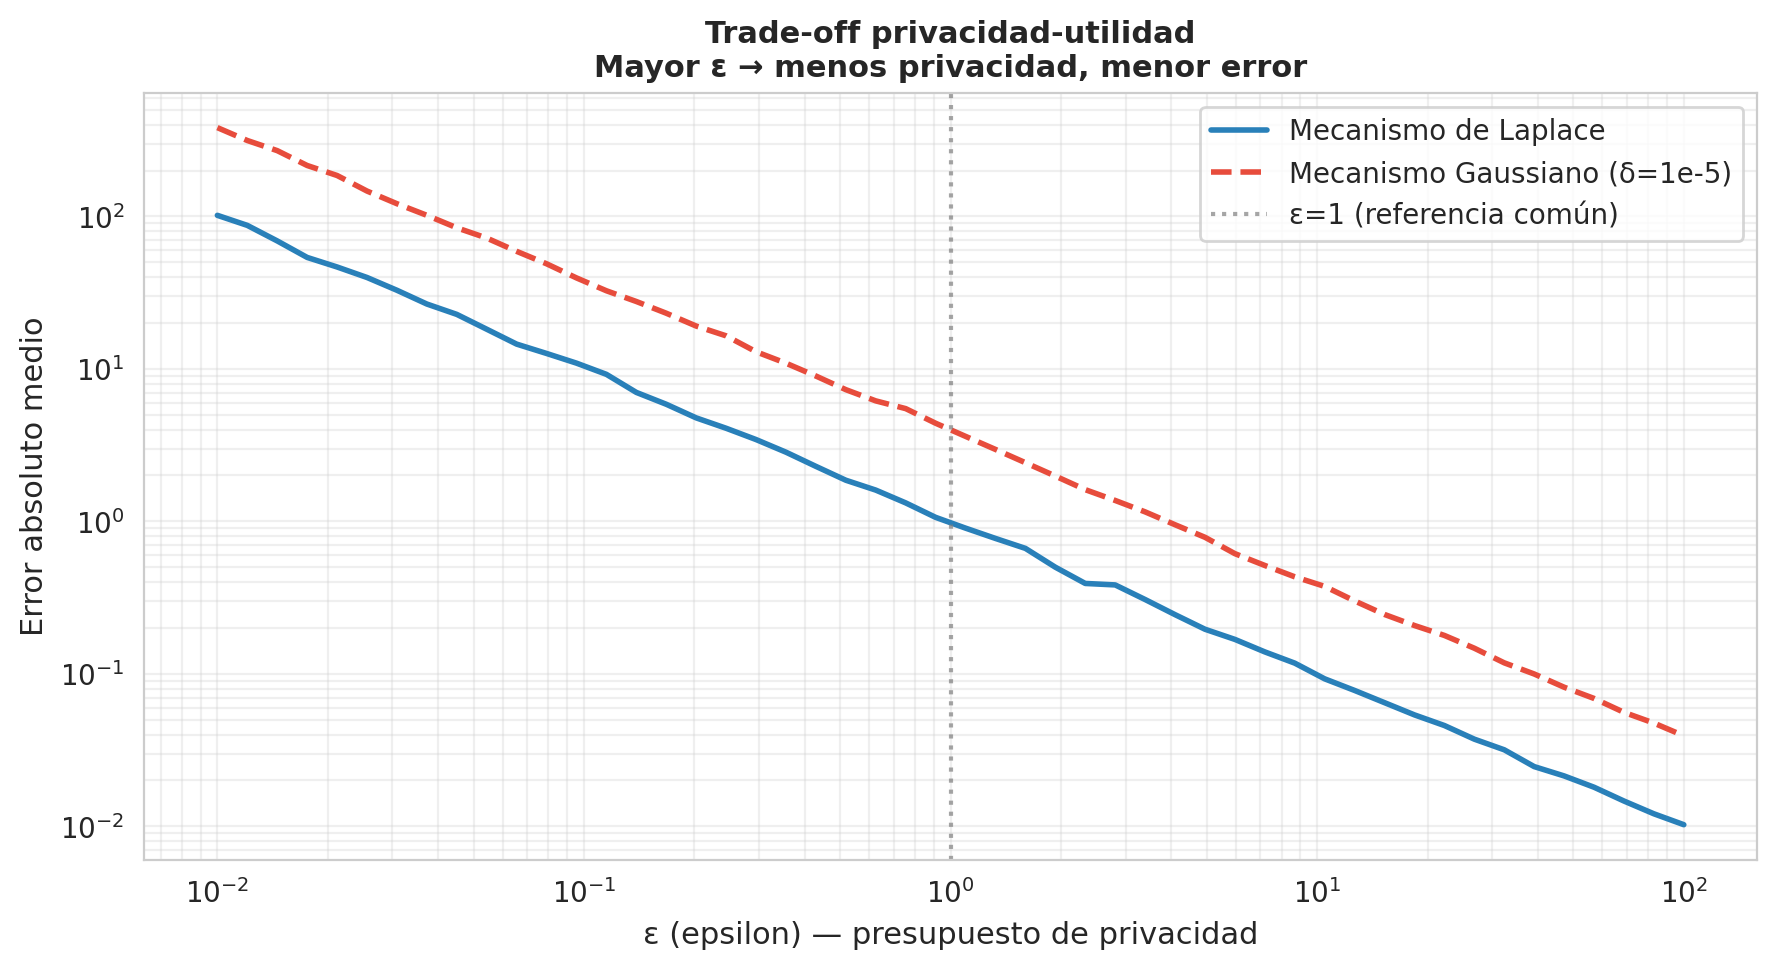

In [ ]:
#@title <font color="green"> ── Visualizar el trade-off privacidad-utilidad ──── </font>
epsilons  = np.logspace(-2, 2, 50)    # de 0.01 a 100
n_reps    = 1000
errores_l = []
errores_g = []

for eps in epsilons:
    muestras_l = [abs(laplace_mechanism(true_count, 1.0, eps) - true_count)
                  for _ in range(n_reps)]
    muestras_g = [abs(gaussian_mechanism(true_count, 1.0, eps) - true_count)
                  for _ in range(n_reps)]
    errores_l.append(np.mean(muestras_l))
    errores_g.append(np.mean(muestras_g))

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(epsilons, errores_l, '-', color='#2980B9', linewidth=2,
          label='Mecanismo de Laplace')
ax.loglog(epsilons, errores_g, '--', color='#E74C3C', linewidth=2,
          label='Mecanismo Gaussiano (δ=1e-5)')
ax.axvline(1.0, color='gray', linestyle=':', alpha=0.7, label='ε=1 (referencia común)')
ax.set_xlabel('ε (epsilon) — presupuesto de privacidad', fontsize=11)
ax.set_ylabel('Error absoluto medio', fontsize=11)
ax.set_title('Trade-off privacidad-utilidad\n'
             'Mayor ε → menos privacidad, menor error',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()


### 4.4.4 Composición: el presupuesto se agota

Una propiedad clave de la privacidad diferencial es la **composición**: si aplicas k mecanismos cada uno con presupuesto εᵢ sobre el mismo dataset, el presupuesto total gastado es **ε₁ + ε₂ + ... + εₖ**. Cada consulta consume parte del presupuesto.

In [ ]:
#@title <font color="green">── Demostración de composición de presupuestos ────── </font>
print("═" * 55)
print("COMPOSICIÓN DE PRESUPUESTOS DE PRIVACIDAD")
print("═" * 55)

presupuesto_total = 5.0   # epsilon total disponible
consultas = [
    ("¿Cuántos usuarios tienen edad > 30?",       1.0),
    ("¿Cuál es el ingreso medio?",                1.5),
    ("¿Cuántos tienen estudios universitarios?",  0.5),
    ("¿Cuántos tienen crédito activo?",           1.0),
    ("¿Cuál es la tasa de reincidencia?",         0.5),
    # Esta consulta supera el presupuesto:
    ("¿Distribución de edades por barrio?",       1.5),
]

presupuesto_restante = presupuesto_total
print(f"\nPresupuesto total disponible: ε = {presupuesto_total}")
print(f"{'─'*55}")

for consulta, eps_consulta in consultas:
    if presupuesto_restante >= eps_consulta:
        presupuesto_restante -= eps_consulta
        estado = f"✓ OK  (restante: {presupuesto_restante:.1f})"
    else:
        estado = f"✗ DENEGADA (faltarían {eps_consulta - presupuesto_restante:.1f})"
    print(f"  ε={eps_consulta:.1f}  {consulta[:42]:<42} {estado}")

print(f"\n→ Cuando el presupuesto se agota, no se pueden hacer más consultas")
print(f"  sin comprometer la garantía de privacidad.")

═══════════════════════════════════════════════════════
COMPOSICIÓN DE PRESUPUESTOS DE PRIVACIDAD
═══════════════════════════════════════════════════════

Presupuesto total disponible: ε = 5.0
───────────────────────────────────────────────────────
  ε=1.0  ¿Cuántos usuarios tienen edad > 30?        ✓ OK  (restante: 4.0)
  ε=1.5  ¿Cuál es el ingreso medio?                 ✓ OK  (restante: 2.5)
  ε=0.5  ¿Cuántos tienen estudios universitarios?   ✓ OK  (restante: 2.0)
  ε=1.0  ¿Cuántos tienen crédito activo?            ✓ OK  (restante: 1.0)
  ε=0.5  ¿Cuál es la tasa de reincidencia?          ✓ OK  (restante: 0.5)
  ε=1.5  ¿Distribución de edades por barrio?        ✗ DENEGADA (faltarían 1.0)

→ Cuando el presupuesto se agota, no se pueden hacer más consultas
  sin comprometer la garantía de privacidad.


## **4.5 DP-SGD: privacidad diferencial en el entrenamiento de redes neuronales**

El algoritmo **DP-SGD** (Differentially Private Stochastic Gradient Descent) adapta el entrenamiento estándar de redes neuronales para garantizar privacidad diferencial. Fue propuesto por Abadi et al. (Google Brain, 2016).

**¿Cómo funciona DP-SGD?**

En el SGD estándar:
1. Tomar un minibatch de ejemplos
2. Calcular el gradiente de la pérdida para cada ejemplo
3. Promediar los gradientes
4. Actualizar los pesos

En DP-SGD se añaden dos pasos:
1. **Recorte de gradientes (*gradient clipping*):** limitar la norma L2 de cada gradiente individual a un valor máximo C. Esto controla la sensibilidad.
2. **Adición de ruido gaussiano:** añadir ruido N(0, σ²C²) al gradiente promediado. Esto garantiza la privacidad.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Preparar datos ────────────────────────────────────────────────────────────
X_dp, y_dp = make_classification(n_samples=3000, n_features=20,
                                   n_informative=12, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_dp, y_dp, test_size=0.3,
                                            random_state=42)
scaler_dp = StandardScaler()
X_tr = scaler_dp.fit_transform(X_tr).astype(np.float32)
X_te = scaler_dp.transform(X_te).astype(np.float32)

# Convertir a tensores PyTorch
train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr, dtype=torch.long))
test_ds  = TensorDataset(torch.tensor(X_te), torch.tensor(y_te, dtype=torch.long))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl  = DataLoader(test_ds, batch_size=256)

# ── Definir la red neuronal ───────────────────────────────────────────────────
class RedSimple(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )
    def forward(self, x):
        return self.net(x)

def entrenar_y_evaluar(use_dp=True, n_epochs=10,
                        max_grad_norm=1.0, noise_multiplier=1.1,
                        target_delta=1e-5):
    torch.manual_seed(42)
    model     = RedSimple(input_dim=20)

    # Initialize optimizer here before any potential modification of model parameters
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    if use_dp:
        # Validar y ajustar la arquitectura para compatibilidad con Opacus
        # Re-initialize optimizer after model is fixed
        model = ModuleValidator.fix(model)
        optimizer = optim.Adam(model.parameters(), lr=1e-3) # Re-initialize optimizer

        privacy_engine = PrivacyEngine()
        model, optimizer, train_dl_dp = privacy_engine.make_private_with_epsilon(
            module=model,
            optimizer=optimizer,
            data_loader=train_dl,
            epochs=n_epochs,
            target_epsilon=3.0,        # ε objetivo
            target_delta=target_delta,
            max_grad_norm=max_grad_norm,
        )
        print(f"  Noise multiplier calculado: {optimizer.noise_multiplier:.4f}")
    else:
        train_dl_dp = train_dl

    # Entrenamiento
    for epoch in range(n_epochs):
        model.train()
        for X_batch, y_batch in train_dl_dp:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

    # Evaluación
    model.eval()
    corrects, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_dl:
            preds = model(X_batch).argmax(dim=1)
            corrects += (preds == y_batch).sum().item()
            total += len(y_batch)
    acc = corrects / total

    if use_dp:
        epsilon_gastado = privacy_engine.get_epsilon(target_delta)
        return acc, epsilon_gastado
    return acc, None

print("Entrenando modelo SIN privacidad diferencial...")
acc_base_dp, _ = entrenar_y_evaluar(use_dp=False)
print(f"  Accuracy sin DP: {acc_base_dp:.4f}")

print("\nEntrenando modelo CON privacidad diferencial (ε≈3)...")
acc_dp, eps_gastado = entrenar_y_evaluar(use_dp=True)
print(f"  Accuracy con DP:     {acc_dp:.4f}")
print(f"  Presupuesto gastado: ε = {eps_gastado:.4f}")
print(f"  Coste en accuracy:   {acc_base_dp - acc_dp:.4f}")

Entrenando modelo SIN privacidad diferencial...
  Accuracy sin DP: 0.9444

Entrenando modelo CON privacidad diferencial (ε≈3)...
  Noise multiplier calculado: 1.0913
  Accuracy con DP:     0.7944
  Presupuesto gastado: ε = 2.9968
  Coste en accuracy:   0.1500


In [ ]:
#@title <font color="green">── Explorar el impacto de epsilon en el accuracy ─── </font>
print("Explorando impacto de distintos valores de ε...")
print("(Esto puede tardar varios minutos)\n")

resultados_dp = []
for target_eps in [0.5, 1.0, 2.0, 5.0, 10.0]:
    try:
        acc, eps_real = entrenar_y_evaluar(use_dp=True, n_epochs=8)
        resultados_dp.append({
            'epsilon_objetivo': target_eps,
            'epsilon_real': round(eps_real, 4),
            'accuracy': round(acc, 4),
        })
        print(f"  ε={target_eps:.1f} → accuracy={acc:.4f}, ε_real={eps_real:.4f}")
    except Exception as e:
        print(f"  ε={target_eps:.1f} → error: {e}")

# Añadir baseline sin DP
resultados_dp.append({
    'epsilon_objetivo': float('inf'),
    'epsilon_real': float('inf'),
    'accuracy': round(acc_base_dp, 4)
})

df_dp = pd.DataFrame(resultados_dp)
print("\n", df_dp.to_string(index=False))

## **4.6 Técnicas clásicas de anonimización**

Antes de la privacidad diferencial existían técnicas más simples y ampliamente usadas en la industria. Son menos robustas matemáticamente pero más fáciles de implementar e interpretar.

### 4.6.1 K-anonimato

Una tabla satisface **k-anonimato** si cada combinación de valores de los quasi-identificadores aparece al menos k veces. Ningún individuo puede distinguirse de al menos k-1 personas más.

**Quasi-identificadores:** atributos que, combinados, pueden identificar a un individuo aunque no sean identificadores directos (p.ej. edad + código postal + género fue suficiente para identificar a la gobernadora de Massachusetts en el famoso caso de 1997).

In [ ]:
#@title <font color="green">── Dataset sintético con datos médicos ──── </font>
np.random.seed(42)
n = 200

df_medico = pd.DataFrame({
    'nombre':        [f"Paciente_{i:03d}" for i in range(n)],
    'edad':          np.random.randint(20, 80, n),
    'codigo_postal': np.random.choice(['08001','08002','08003','08004',
                                        '08005','08006'], n),
    'genero':        np.random.choice(['M', 'F'], n),
    'enfermedad':    np.random.choice(['diabetes','hipertension','asma',
                                        'ninguna'], n, p=[0.2,0.3,0.1,0.4]),
    'medicamento':   np.random.choice(['metformina','enalapril','salbutamol',
                                        'ninguno'], n)
})

print("Dataset médico (primeras 8 filas):")
print(df_medico.head(8).to_string(index=False))
print(f"\nTotal registros: {len(df_medico)}")

Dataset médico (primeras 8 filas):
      nombre  edad codigo_postal genero   enfermedad medicamento
Paciente_000    58         08003      M     diabetes   enalapril
Paciente_001    71         08003      F hipertension  metformina
Paciente_002    48         08006      M hipertension  metformina
Paciente_003    34         08004      F      ninguna     ninguno
Paciente_004    62         08002      M      ninguna     ninguno
Paciente_005    27         08002      M     diabetes   enalapril
Paciente_006    40         08005      F hipertension     ninguno
Paciente_007    58         08006      M      ninguna  salbutamol

Total registros: 200


In [ ]:
#@title <font color="green">── Verificar k-anonimato ───── </font>
def check_k_anonymity(df, quasi_identifiers, k=5, verbose=True):
    """
    Verifica si el dataset satisface k-anonimato para los quasi-identificadores dados.
    Devuelve un DataFrame con los grupos que violan el k-anonimato.
    """
    grupos = df.groupby(quasi_identifiers).size().reset_index(name='count')
    violaciones = grupos[grupos['count'] < k].copy()
    satisface   = grupos[grupos['count'] >= k]

    if verbose:
        print(f"{'═'*55}")
        print(f"ANÁLISIS DE K-ANONIMATO (k={k})")
        print(f"Quasi-identificadores: {quasi_identifiers}")
        print(f"{'═'*55}")
        print(f"\nTotal de combinaciones únicas: {len(grupos)}")
        print(f"Combinaciones que satisfacen k={k}: {len(satisface)} "
              f"({len(satisface)/len(grupos):.1%})")
        print(f"Combinaciones que VIOLAN k={k}:    {len(violaciones)} "
              f"({len(violaciones)/len(grupos):.1%})")
        print(f"\nRegistros en grupos vulnerables: "
              f"{violaciones['count'].sum()} de {len(df)} "
              f"({violaciones['count'].sum()/len(df):.1%})")

        if len(violaciones) > 0:
            print(f"\nPeores grupos (más identificables):")
            print(violaciones.sort_values('count').head(10).to_string(index=False))

    return violaciones

qi = ['edad', 'codigo_postal', 'genero']
violaciones = check_k_anonymity(df_medico, quasi_identifiers=qi, k=5)

═══════════════════════════════════════════════════════
ANÁLISIS DE K-ANONIMATO (k=5)
Quasi-identificadores: ['edad', 'codigo_postal', 'genero']
═══════════════════════════════════════════════════════

Total de combinaciones únicas: 163
Combinaciones que satisfacen k=5: 0 (0.0%)
Combinaciones que VIOLAN k=5:    163 (100.0%)

Registros en grupos vulnerables: 200 de 200 (100.0%)

Peores grupos (más identificables):
 edad codigo_postal genero  count
   20         08001      M      1
   20         08003      F      1
   20         08003      M      1
   20         08005      M      1
   21         08002      F      1
   21         08003      M      1
   22         08002      M      1
   22         08003      M      1
   25         08006      F      1
   22         08004      F      1


In [ ]:
#@title <font color="green">── Generalización para lograr k-anonimato ─── </font>
def generalizar_edad(edad, rango=10):
    """Agrupa la edad en rangos de `rango` años."""
    inicio = (edad // rango) * rango
    return f"{inicio}-{inicio + rango - 1}"

def generalizar_cp(cp, chars=3):
    """Trunca el código postal a los primeros `chars` dígitos."""
    return cp[:chars] + '*' * (len(cp) - chars)

# Aplicar generalización
df_anonimizado = df_medico.copy()
df_anonimizado['edad_rango'] = df_anonimizado['edad'].apply(
    lambda e: generalizar_edad(e, rango=10))
df_anonimizado['cp_general'] = df_anonimizado['codigo_postal'].apply(
    lambda c: generalizar_cp(c, chars=3))

# Eliminar atributos originales y el identificador directo
df_anonimizado = df_anonimizado.drop(
    columns=['nombre', 'edad', 'codigo_postal'])

print("Dataset generalizado (primeras 8 filas):")
print(df_anonimizado.head(8).to_string(index=False))

# Verificar k-anonimato en el dataset generalizado
print()
qi_general = ['edad_rango', 'cp_general', 'genero']
violaciones_post = check_k_anonymity(
    df_anonimizado, quasi_identifiers=qi_general, k=5)

mejora = len(violaciones) - len(violaciones_post)
print(f"\n✓ Reducción de violaciones: {len(violaciones)} → {len(violaciones_post)} "
      f"({mejora} grupos solucionados)")

Dataset generalizado (primeras 8 filas):
genero   enfermedad medicamento edad_rango cp_general
     M     diabetes   enalapril      50-59      080**
     F hipertension  metformina      70-79      080**
     M hipertension  metformina      40-49      080**
     F      ninguna     ninguno      30-39      080**
     M      ninguna     ninguno      60-69      080**
     M     diabetes   enalapril      20-29      080**
     F hipertension     ninguno      40-49      080**
     M      ninguna  salbutamol      50-59      080**

═══════════════════════════════════════════════════════
ANÁLISIS DE K-ANONIMATO (k=5)
Quasi-identificadores: ['edad_rango', 'cp_general', 'genero']
═══════════════════════════════════════════════════════

Total de combinaciones únicas: 12
Combinaciones que satisfacen k=5: 12 (100.0%)
Combinaciones que VIOLAN k=5:    0 (0.0%)

Registros en grupos vulnerables: 0 de 200 (0.0%)

✓ Reducción de violaciones: 163 → 0 (163 grupos solucionados)


### 4.6.2 L-diversidad

El k-anonimato tiene una debilidad: si todos los k registros de un grupo tienen el mismo valor en el atributo sensible (p.ej. todos tienen la misma enfermedad), el atacante puede inferir ese atributo aunque no sepa cuál es el individuo.

La **l-diversidad** exige que cada grupo tenga al menos l valores distintos en el atributo sensible.

In [ ]:
#@title <font color="green"> --- Verifica l-diversidad ---</font>
def check_l_diversity(df, quasi_identifiers, sensitive_attr, l=3, verbose=True):
    """
    Verifica l-diversidad: cada grupo de k-anonimato debe tener
    al menos l valores distintos en el atributo sensible.
    """
    grupos = df.groupby(quasi_identifiers)[sensitive_attr].nunique().reset_index()
    grupos.columns = quasi_identifiers + ['diversidad']
    violaciones = grupos[grupos['diversidad'] < l]

    if verbose:
        print(f"{'═'*55}")
        print(f"ANÁLISIS DE L-DIVERSIDAD (l={l})")
        print(f"Atributo sensible: '{sensitive_attr}'")
        print(f"{'═'*55}")
        print(f"\nGrupos con diversidad < {l}: {len(violaciones)} "
              f"({len(violaciones)/len(grupos):.1%})")
        print(f"Diversidad media por grupo:  "
              f"{grupos['diversidad'].mean():.2f}")
        if len(violaciones) > 0:
            print(f"\nGrupos con baja diversidad:")
            print(violaciones.sort_values('diversidad').head(8).to_string(index=False))

    return violaciones

violaciones_l = check_l_diversity(
    df_anonimizado,
    quasi_identifiers=qi_general,
    sensitive_attr='enfermedad',
    l=3
)

═══════════════════════════════════════════════════════
ANÁLISIS DE L-DIVERSIDAD (l=3)
Atributo sensible: 'enfermedad'
═══════════════════════════════════════════════════════

Grupos con diversidad < 3: 0 (0.0%)
Diversidad media por grupo:  3.83


### 4.6.3 Seudonimización

La seudonimización sustituye identificadores directos (nombre, DNI, email) por pseudónimos deterministas. A diferencia de la anonimización completa, **es reversible** si se tiene acceso a la tabla de correspondencia. El GDPR la acepta como medida de protección pero no la equipara a anonimización.

In [ ]:
#@title <font color="green"> Seudonimización determinista con HMAC-SHA256 </font>
import hashlib
import secrets

def pseudonymize_deterministic(value, salt, length=16):
    """
    Seudonimización determinista con HMAC-SHA256.
    El mismo valor + salt siempre produce el mismo pseudónimo.
    Sin el salt, es computacionalmente inviable recuperar el original.
    """
    key = salt.encode('utf-8')
    msg = str(value).encode('utf-8')
    import hmac
    h = hmac.new(key, msg, hashlib.sha256)
    return h.hexdigest()[:length]

# Generar un salt seguro (debe almacenarse de forma separada y protegida)
SALT_SECRETO = secrets.token_hex(32)
print(f"Salt generado (guardar de forma segura): {SALT_SECRETO[:20]}...")

# Aplicar seudonimización
df_pseudo = df_medico.copy()
df_pseudo['id_pseudo'] = df_pseudo['nombre'].apply(
    lambda n: pseudonymize_deterministic(n, SALT_SECRETO))
df_pseudo = df_pseudo.drop(columns=['nombre'])

print("\nDataset seudonimizado (primeras 5 filas):")
print(df_pseudo[['id_pseudo', 'edad', 'codigo_postal',
                  'genero', 'enfermedad']].head().to_string(index=False))

# Verificar consistencia: el mismo nombre siempre da el mismo pseudónimo
id1 = pseudonymize_deterministic("Paciente_001", SALT_SECRETO)
id2 = pseudonymize_deterministic("Paciente_001", SALT_SECRETO)
print(f"\nConsistencia: Paciente_001 → {id1} (siempre igual: {id1 == id2})")

# Sin el salt es inviable revertir
id_sin_salt = pseudonymize_deterministic("Paciente_001", "salt_incorrecto")
print(f"Con salt incorrecto: Paciente_001 → {id_sin_salt} (distinto: {id1 != id_sin_salt})")

Salt generado (guardar de forma segura): f095baf6f20d294e1617...

Dataset seudonimizado (primeras 5 filas):
       id_pseudo  edad codigo_postal genero   enfermedad
7f3c3baa2633a594    58         08003      M     diabetes
9d50b8b635f15dad    71         08003      F hipertension
b6ce709757029941    48         08006      M hipertension
5ce3e9c3bc881a17    34         08004      F      ninguna
d8e4cadd570e37ce    62         08002      M      ninguna

Consistencia: Paciente_001 → 9d50b8b635f15dad (siempre igual: True)
Con salt incorrecto: Paciente_001 → ba9cb81bfa9ac3ec (distinto: True)


## **4.7 Detección de PII (*Personally Identifiable Information*)**

Antes de entrenar cualquier modelo, es buena práctica escanear el dataset en busca de información personal que pueda haberse colado inadvertidamente.

In [ ]:
#@title <font color="green">── Detector básico de PII en texto ────</font>
import re


PII_PATTERNS = {
    'email':        r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
    'telefono_es':  r'\b(?:\+34|0034)?[6789]\d{8}\b',
    'dni_es':       r'\b\d{8}[A-HJ-NP-TV-Z]\b',
    'tarjeta':      r'\b(?:\d{4}[\s-]?){3}\d{4}\b',
    'ip_address':   r'\b(?:\d{1,3}\.){3}\d{1,3}\b',
    'fecha_nacim':  r'\b(?:0[1-9]|[12]\d|3[01])[/-](?:0[1-9]|1[0-2])[/-](?:19|20)\d{2}\b',
}

def detectar_pii(texto):
    """Detecta patrones de PII en un texto y devuelve los hallazgos."""
    hallazgos = {}
    for tipo, patron in PII_PATTERNS.items():
        matches = re.findall(patron, str(texto))
        if matches:
            hallazgos[tipo] = matches
    return hallazgos

def escanear_dataframe(df, columnas_texto=None):
    """Escanea todas las columnas de texto de un DataFrame en busca de PII."""
    if columnas_texto is None:
        columnas_texto = df.select_dtypes(include='object').columns.tolist()

    total_pii = 0
    for col in columnas_texto:
        pii_en_col = df[col].apply(detectar_pii)
        filas_con_pii = pii_en_col[pii_en_col.apply(bool)]
        if len(filas_con_pii) > 0:
            print(f"\n  Columna '{col}': {len(filas_con_pii)} filas con PII")
            for idx, hallazgo in filas_con_pii.items():
                print(f"    Fila {idx}: {hallazgo}")
            total_pii += len(filas_con_pii)

    if total_pii == 0:
        print("  ✓ No se detectó PII en las columnas analizadas.")
    return total_pii

# Ejemplo con datos sintéticos que contienen PII
df_con_pii = pd.DataFrame({
    'comentario': [
        "Paciente Juan García, DNI 12345678Z, tel 612345678",
        "Sin alergias conocidas",
        "Contactar en info@hospital.es o al +34 699 123 456",
        "Historial limpio",
        "Tarjeta: 4532 1234 5678 9012",
    ]
})

print("═" * 50)
print("ESCANEO DE PII EN COLUMNAS DE TEXTO")
print("═" * 50)
total = escanear_dataframe(df_con_pii)
print(f"\nTotal de filas con PII detectada: {total}")

══════════════════════════════════════════════════
ESCANEO DE PII EN COLUMNAS DE TEXTO
══════════════════════════════════════════════════

  Columna 'comentario': 3 filas con PII
    Fila 0: {'telefono_es': ['612345678'], 'dni_es': ['12345678Z']}
    Fila 2: {'email': ['info@hospital.es']}
    Fila 4: {'tarjeta': ['4532 1234 5678 9012']}

Total de filas con PII detectada: 3


## **4.8 Resumen: elegir la técnica adecuada**

In [ ]:
#@title <font color="green">Guía de selección de técnica de privacidad</font>
guia_privacidad = {
    "K-anonimato / L-diversidad": {
        "cuándo": "Publicar tablas estadísticas o datasets con quasi-identificadores",
        "fortaleza": "Fácil de entender y auditar",
        "debilidad": "Vulnerable a ataques de fondo (background knowledge)",
        "coste": "Bajo",
        "estándar": "ISO 29101, GDPR guidance"
    },
    "Seudonimización": {
        "cuándo": "Separar identidad de datos analíticos manteniendo trazabilidad interna",
        "fortaleza": "Reversible para usos legítimos; simple de implementar",
        "debilidad": "No es anonimización; si se filtra el salt, se puede revertir",
        "coste": "Muy bajo",
        "estándar": "GDPR Art. 4(5), ENISA guidelines"
    },
    "Privacidad diferencial (consultas)": {
        "cuándo": "Publicar estadísticas agregadas sobre datos sensibles",
        "fortaleza": "Garantía matemática formal y cuantificable",
        "debilidad": "Requiere gestionar el presupuesto; difícil de explicar a no técnicos",
        "coste": "Moderado",
        "estándar": "Apple, Google, US Census Bureau lo usan en producción"
    },
    "DP-SGD (entrenamiento con DP)": {
        "cuándo": "Entrenar modelos de ML sobre datos personales sensibles",
        "fortaleza": "El modelo en sí tiene garantías de privacidad",
        "debilidad": "Coste significativo en accuracy; aumenta el tiempo de entrenamiento",
        "coste": "Alto",
        "estándar": "Opacus (PyTorch), TensorFlow Privacy"
    },
    "Federated Learning": {
        "cuándo": "Los datos no pueden salir de los dispositivos o silos (hospitales, móviles)",
        "fortaleza": "Los datos nunca se centralizan",
        "debilidad": "Comunicación costosa; vulnerable a gradient inversion attacks",
        "coste": "Alto",
        "estándar": "Google (Gboard), Apple, PySyft"
    },
}

print("═" * 60)
print("GUÍA DE SELECCIÓN DE TÉCNICAS DE PRIVACIDAD")
print("═" * 60)
for tecnica, info in guia_privacidad.items():
    print(f"\n  ▶ {tecnica.upper()}")
    for k, v in info.items():
        print(f"    {k:<12}: {v}")

════════════════════════════════════════════════════════════
GUÍA DE SELECCIÓN DE TÉCNICAS DE PRIVACIDAD
════════════════════════════════════════════════════════════

  ▶ K-ANONIMATO / L-DIVERSIDAD
    cuándo      : Publicar tablas estadísticas o datasets con quasi-identificadores
    fortaleza   : Fácil de entender y auditar
    debilidad   : Vulnerable a ataques de fondo (background knowledge)
    coste       : Bajo
    estándar    : ISO 29101, GDPR guidance

  ▶ SEUDONIMIZACIÓN
    cuándo      : Separar identidad de datos analíticos manteniendo trazabilidad interna
    fortaleza   : Reversible para usos legítimos; simple de implementar
    debilidad   : No es anonimización; si se filtra el salt, se puede revertir
    coste       : Muy bajo
    estándar    : GDPR Art. 4(5), ENISA guidelines

  ▶ PRIVACIDAD DIFERENCIAL (CONSULTAS)
    cuándo      : Publicar estadísticas agregadas sobre datos sensibles
    fortaleza   : Garantía matemática formal y cuantificable
    debilidad   : Requi

## **4.9 Ejercicios propuestos**

> **Ejercicio 1 (básico):** Dado el dataset médico sintético generado en la sección 4.6, verifica el k-anonimato para k=3 y k=5 usando los quasi-identificadores `edad_rango`, `cp_general` y `genero`. Aplica una generalización adicional (p.ej. rangos de edad de 20 años en lugar de 10) y mide cuántos grupos dejan de violar el k-anonimato. ¿A qué coste en términos de utilidad analítica?

> **Ejercicio 2 (intermedio):** Implementa el mecanismo de Laplace para responder con privacidad diferencial a las siguientes tres consultas sobre el dataset German Credit: (a) número de hombres, (b) edad media, (c) porcentaje con buen crédito. Usa ε=1.0 para cada consulta. Calcula el presupuesto total gastado por composición. Repite con ε=0.1 y compara los errores. ¿Para qué consultas es más destructivo el ruido?

> **Ejercicio 3 (avanzado):** Entrena dos versiones de una red neuronal sobre el dataset Adult Income: una sin DP y otra con DP-SGD usando Opacus con ε=3.0. Compara accuracy, tiempo de entrenamiento y la vulnerabilidad al ataque de pertenencia (usando la diferencia de confianza media entre train y test). ¿Reduce el DP-SGD la vulnerabilidad al ataque? ¿A qué coste en accuracy?

> **Ejercicio 4 (reflexión):** Un hospital quiere entrenar un modelo de predicción de readmisión con historiales de 50.000 pacientes. Identifica qué variables son quasi-identificadores, qué variables son atributos sensibles y qué base jurídica del GDPR aplicarías para el entrenamiento. ¿Qué técnica de privacidad recomendarías y por qué? ¿Cómo gestionarías una solicitud de "derecho al olvido" de un paciente una vez el modelo está desplegado?




## **Referencias del bloque**

| Recurso | Tipo | Enlace |
|---|---|---|
| Abadi et al. (2016) — DP-SGD original | Artículo | https://arxiv.org/abs/1607.00133 |
| Carlini et al. (2021) — Extracción de datos en LLMs | Artículo | https://arxiv.org/abs/2012.07805 |
| Opacus — DP para PyTorch (Meta) | Librería | https://opacus.ai |
| TensorFlow Privacy (Google) | Librería | https://github.com/tensorflow/privacy |
| OpenDP — librería DP de Harvard/MIT | Librería | https://opendp.org |
| Sweeney (2002) — k-anonimato original | Artículo | https://doi.org/10.1142/S0218488502001648 |
| ENISA — Guía de seudonimización | Informe técnico | https://www.enisa.europa.eu/publications/pseudonymisation-techniques-and-best-practices |
| GDPR texto oficial (español) | Regulación | https://eur-lex.europa.eu/legal-content/ES/TXT/?uri=CELEX:32016R0679 |
| The Algorithmic Foundations of DP (Dwork & Roth) | Libro gratuito | https://www.cis.upenn.edu/~aaroth/Papers/privacybook.pdf |



# **5. Explicabilidad (XAI)**

## **5.1 ¿Por qué explicabilidad?**

Los modelos complejos (Random Forest, XGBoost, redes neuronales) son cajas negras: producen predicciones precisas pero sin justificación comprensible. A medida que estos sistemas toman decisiones con consecuencias reales —conceder un crédito, contratar a una persona, diagnosticar una enfermedad— la pregunta "¿por qué?" se vuelve tan importante como "¿qué?".

### 5.1.1 Razones para la explicabilidad

**Razones legales:**
- El GDPR (Art. 22) reconoce el derecho a no ser objeto de decisiones automatizadas con efectos significativos sin explicación comprensible ni posibilidad de intervención humana.
- El AI Act exige transparencia y explicabilidad para todos los sistemas de alto riesgo (crédito, empleo, justicia, salud).
- La Directiva de Responsabilidad por IA (en tramitación) implicará que demostrar el comportamiento del modelo será necesario para defenderse en litigios.

**Razones técnicas:**
- Detectar variables proxy que introducen sesgo de forma encubierta.
- Depurar errores sistemáticos que la métrica global no revela.
- Validar que el modelo aprende patrones causales y no correlaciones espurias.
- Monitorizar el drift: si las variables más influyentes cambian con el tiempo, el modelo puede estar degradándose.

**Razones éticas:**
- Las personas afectadas por una decisión tienen derecho a entenderla y a poder impugnarla con argumentos concretos.
- Un modelo opaco que discrimina es más difícil de detectar y corregir que uno explicable.

**Razones operacionales:**
- Los equipos de negocio y directivos necesitan confiar en el modelo para adoptarlo.
- Los reguladores pueden requerir auditorías del comportamiento del modelo.
- Los ingenieros necesitan entender el modelo para mantenerlo y mejorarlo.

### 5.1.2 El espectro de la explicabilidad

No todos los modelos son igualmente opacos ni todas las explicaciones igualmente útiles. Es útil pensar en un espectro:

```
Transparencia total                              Caja negra total
──────────────────────────────────────────────────────────────────▶
  Reglas      Regresión    Árbol de    Random     XGBoost    Red
  simples     lineal       decisión    Forest                neuronal
              (coefic.)    (≤5 niv.)
  │                        │                                  │
  └─ Interpretables        └─ Explicables con                 └─ Requieren
     por diseño              herramientas                       XAI post-hoc
```

El objetivo de XAI no es siempre maximizar la transparencia: a veces un modelo más opaco y preciso con buenas explicaciones post-hoc es preferible a un modelo simple e interpretable pero menos preciso.

### 5.1.3 Tipos de explicaciones

| Tipo | Pregunta | Alcance | Herramientas principales |
|---|---|---|---|
| **Global** | ¿Qué variables importan más en general? | Todo el modelo | SHAP summary, feature importance |
| **Local** | ¿Por qué este caso concreto obtuvo esta predicción? | Una instancia | SHAP force plot, LIME, ANCHOR |
| **Contrafactual** | ¿Qué tendría que cambiar para obtener otra predicción? | Una instancia | DICE, Alibi, Wachter et al. |
| **Basada en ejemplos** | ¿A qué casos de entrenamiento se parece este? | Una instancia | MMD-critic, prototypes |
| **Conceptual** | ¿Qué conceptos de alto nivel usa el modelo? | Capas internas | TCAV (Testing with CAVs) |

## **5.2 Instalación y preparación**


In [ ]:
#@title Instalar todas las librerías del bloque
!pip install shap lime alibi dice-ml xgboost --quiet

# Verificar instalaciones
for lib in ['shap', 'lime', 'alibi', 'dice', 'xgboost']:
    try:
        __import__(lib)
        print(f"  ✓ {lib}")
    except ImportError:
        print(f"  ✗ {lib} — revisar instalación")

  ✓ shap
  ✓ lime
  ✓ alibi
  ✗ dice — revisar instalación
  ✓ xgboost


In [ ]:
#@title Datos Wisconsin
import shap
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ── Dataset: Wisconsin Breast Cancer ──────────────────────────────────────────
# 569 muestras, 30 variables de diagnóstico de tumores
# Clase 0 = Maligno, Clase 1 = Benigno
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Clase 0 (Maligno): {(y==0).sum()} | Clase 1 (Benigno): {(y==1).sum()}")
print(f"\nVariables disponibles:\n{list(X.columns)}")

Train: (426, 30) | Test: (143, 30)
Clase 0 (Maligno): 212 | Clase 1 (Benigno): 357

Variables disponibles:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


In [ ]:
#@title ── Entrenar modelo XGBoost ────
model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred,
                              target_names=['Maligno', 'Benigno']))

Accuracy: 0.9580
              precision    recall  f1-score   support

     Maligno       0.96      0.92      0.94        53
     Benigno       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



## **5.3 SHAP — SHapley Additive exPlanations**

### 5.3.1 Fundamentos matemáticos

SHAP se basa en los **valores de Shapley** de la teoría de juegos cooperativos (Lloyd Shapley, Premio Nobel de Economía 2012). La idea central: para asignar equitativamente la "ganancia" de una coalición entre sus jugadores, se calcula la contribución marginal promedio de cada jugador en todas las posibles coaliciones.

Trasladado a ML: el "juego" es la predicción del modelo, los "jugadores" son las variables, y la "ganancia" es la diferencia entre la predicción del modelo para ese caso y la predicción base (media del modelo sin información).

**Propiedades garantizadas matemáticamente:**

| Propiedad | Significado práctico |
|---|---|
| **Eficiencia** | La suma de todos los SHAP values iguala exactamente la desviación de la predicción base |
| **Simetría** | Dos variables con igual contribución reciben igual SHAP value |
| **Linealidad** | Las contribuciones de modelos combinados se suman linealmente |
| **Dummy** | Una variable que no afecta a ninguna predicción recibe SHAP = 0 |

Estas cuatro propiedades hacen de SHAP la única solución axomáticamente justa al problema de atribución de características.


### 5.3.2 TreeExplainer: SHAP para modelos de árbol

In [ ]:
#@title <font color="green"> ── Crear el explicador SHAP ──── </font>
# TreeExplainer es el más eficiente para XGBoost, Random Forest, LightGBM
# Complejidad: O(TLD²) donde T=árboles, L=hojas, D=profundidad
explainer = shap.TreeExplainer(model)

# Calcular SHAP values para el test set completo
# shap_values.shape = (n_test, n_features)
shap_values = explainer.shap_values(X_test)

print(f"Shape de SHAP values: {shap_values.shape}")
print(f"Valor base (expected_value): {explainer.expected_value:.4f}")
print(f"  → El modelo predice clase 1 con probabilidad {explainer.expected_value:.4f}")
print(f"    en ausencia de información (media del modelo)")

# Para el primer caso del test:
pred_proba = model.predict_proba(X_test.iloc[[0]])[0, 1]
suma_shap  = explainer.expected_value + shap_values[0].sum()
print(f"\nVerificación de eficiencia para caso 0:")
print(f"  predict_proba(x):          {pred_proba:.6f}")
print(f"  expected_value + Σ SHAP:   {suma_shap:.6f}")
print(f"  Diferencia (debe ser ≈0):  {abs(pred_proba - suma_shap):.2e}")

Shape de SHAP values: (143, 30)
Valor base (expected_value): 0.5384
  → El modelo predice clase 1 con probabilidad 0.5384
    en ausencia de información (media del modelo)

Verificación de eficiencia para caso 0:
  predict_proba(x):          0.997736
  expected_value + Σ SHAP:   6.088275
  Diferencia (debe ser ≈0):  5.09e+00


### 5.3.3 Explicaciones globales

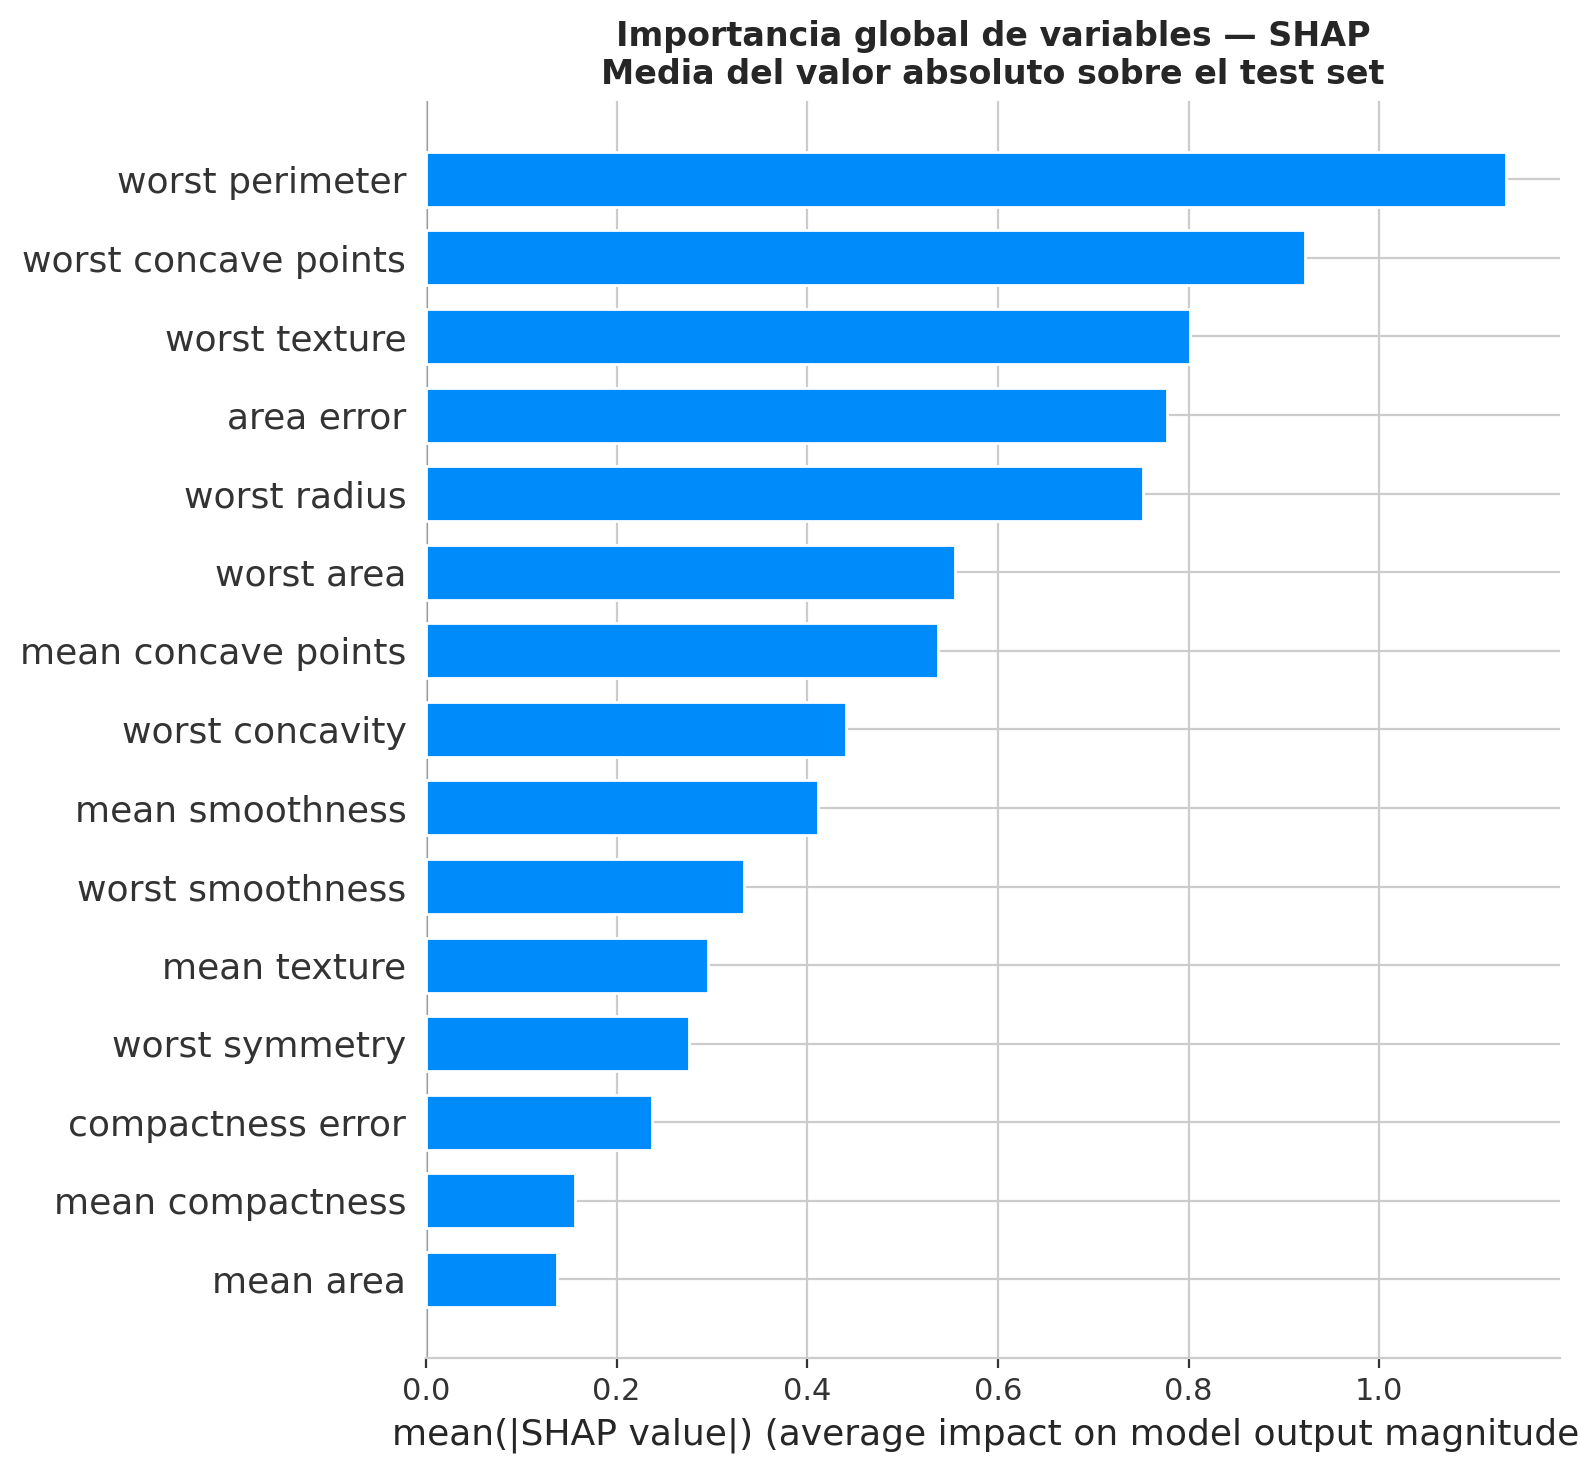

Guardado: shap_bar.png


In [ ]:
#@title ── Gráfico 1: Importancia global (bar plot) ──────
# Muestra la importancia media absoluta de cada variable en el modelo
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar",
                   show=False, max_display=15)
plt.title("Importancia global de variables — SHAP\n"
          "Media del valor absoluto sobre el test set",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=130, bbox_inches='tight')
plt.show()
print("Guardado: shap_bar.png")

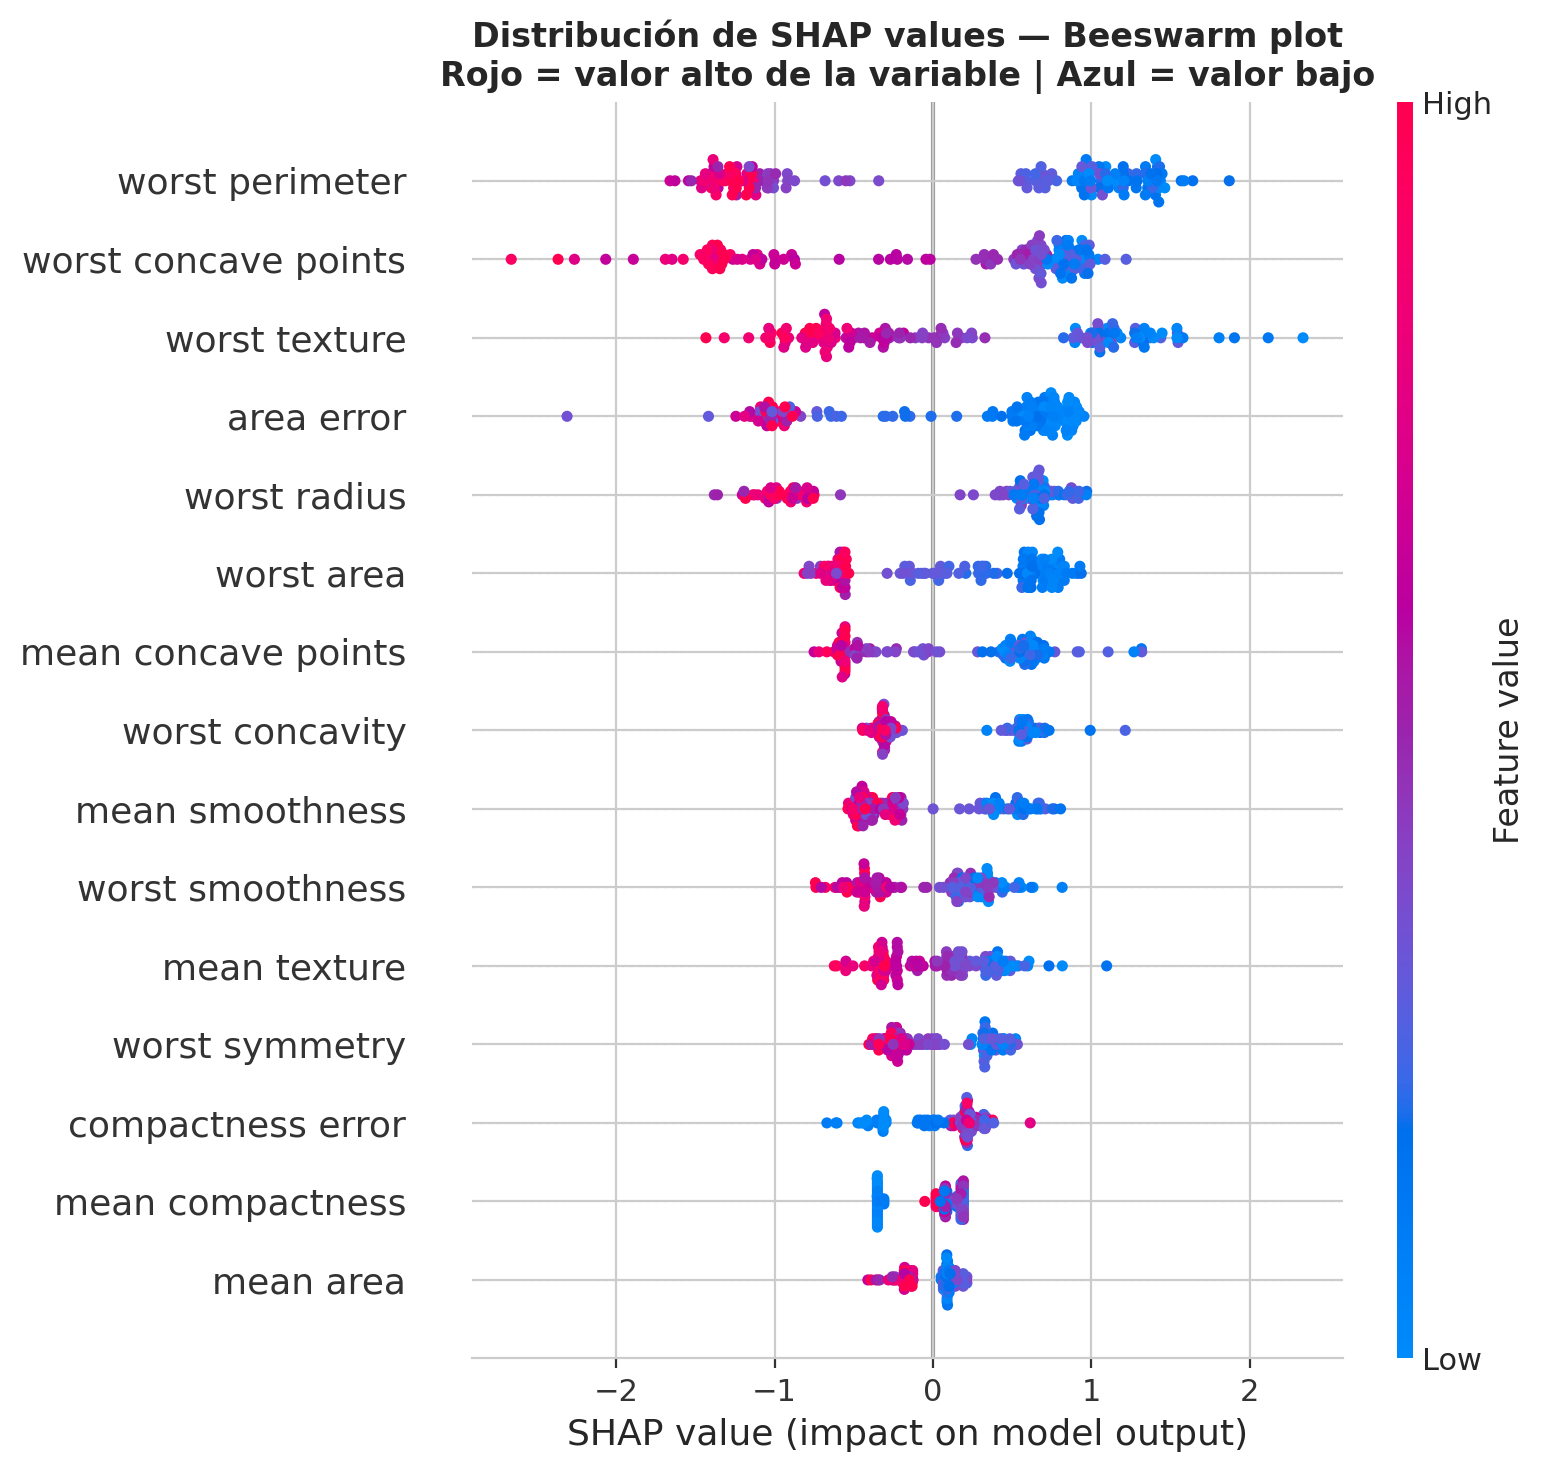

Guardado: shap_beeswarm.png

Cómo leer el beeswarm plot:
  · Cada fila es una variable, ordenada de mayor a menor importancia global.
  · Cada punto es una instancia del test.
  · SHAP > 0 → esa variable empuja la predicción hacia clase positiva (benigno).
  · SHAP < 0 → esa variable empuja hacia clase negativa (maligno).
  · Un punto ROJO (valor alto) a la derecha (SHAP positivo) significa:
    valores altos de esa variable predicen benignidad.
  · Un punto ROJO a la izquierda (SHAP negativo) significa:
    valores altos de esa variable predicen malignidad.


In [ ]:
#@title ── Gráfico 2: Beeswarm plot (importancia + dirección del efecto) ────
# Cada punto es una instancia del test.
# Posición horizontal: valor SHAP (impacto en la predicción)
# Color: valor de la variable (rojo = alto, azul = bajo)
fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title("Distribución de SHAP values — Beeswarm plot\n"
          "Rojo = valor alto de la variable | Azul = valor bajo",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=130, bbox_inches='tight')
plt.show()
print("Guardado: shap_beeswarm.png")

# ── Cómo leer el beeswarm ─────────────────────────────────────────────────────
print("\nCómo leer el beeswarm plot:")
print("  · Cada fila es una variable, ordenada de mayor a menor importancia global.")
print("  · Cada punto es una instancia del test.")
print("  · SHAP > 0 → esa variable empuja la predicción hacia clase positiva (benigno).")
print("  · SHAP < 0 → esa variable empuja hacia clase negativa (maligno).")
print("  · Un punto ROJO (valor alto) a la derecha (SHAP positivo) significa:")
print("    valores altos de esa variable predicen benignidad.")
print("  · Un punto ROJO a la izquierda (SHAP negativo) significa:")
print("    valores altos de esa variable predicen malignidad.")

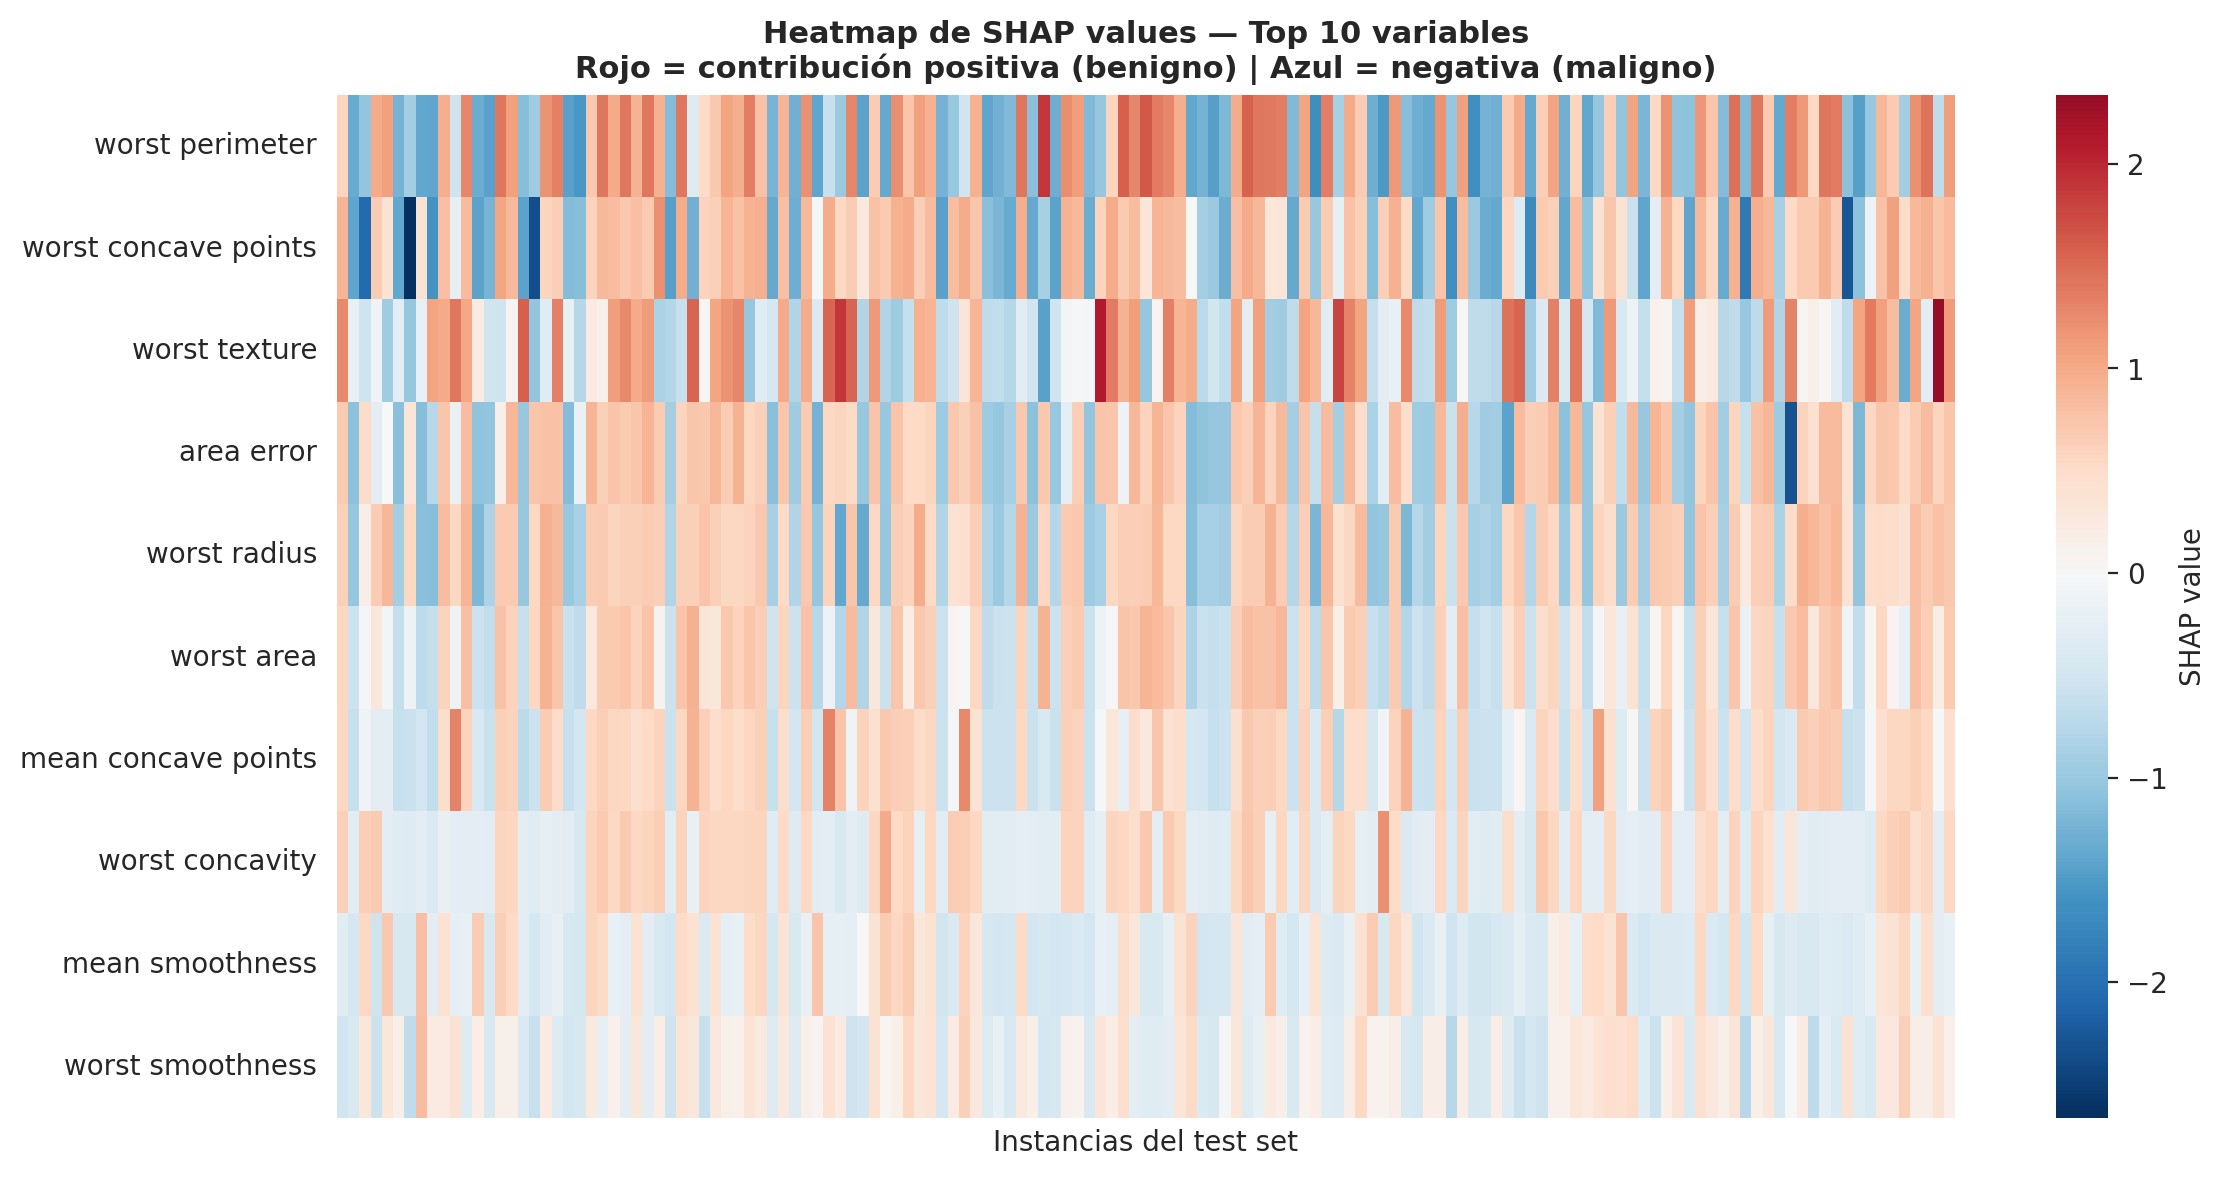

In [ ]:
#@title ── Gráfico 3: Heatmap SHAP (visión de conjunto) ───
# Muestra los SHAP values de todas las instancias para las top variables
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
top_vars = shap_df.abs().mean().sort_values(ascending=False).head(10).index

fig, ax = plt.subplots(figsize=(12, 6))
import seaborn as sns
sns.heatmap(
    shap_df[top_vars].T,
    cmap='RdBu_r',
    center=0,
    xticklabels=False,
    yticklabels=True,
    ax=ax,
    cbar_kws={'label': 'SHAP value'}
)
ax.set_title('Heatmap de SHAP values — Top 10 variables\n'
             'Rojo = contribución positiva (benigno) | Azul = negativa (maligno)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Instancias del test set')
plt.tight_layout()
plt.show()

### 5.3.4 Explicaciones locales


───────────────────────────────────────────────────────
Caso 0 — caso benigno bien clasificado
  Predicción: Benigno (prob=0.9977)
  Real:       Benigno
  ¿Correcto?  ✓


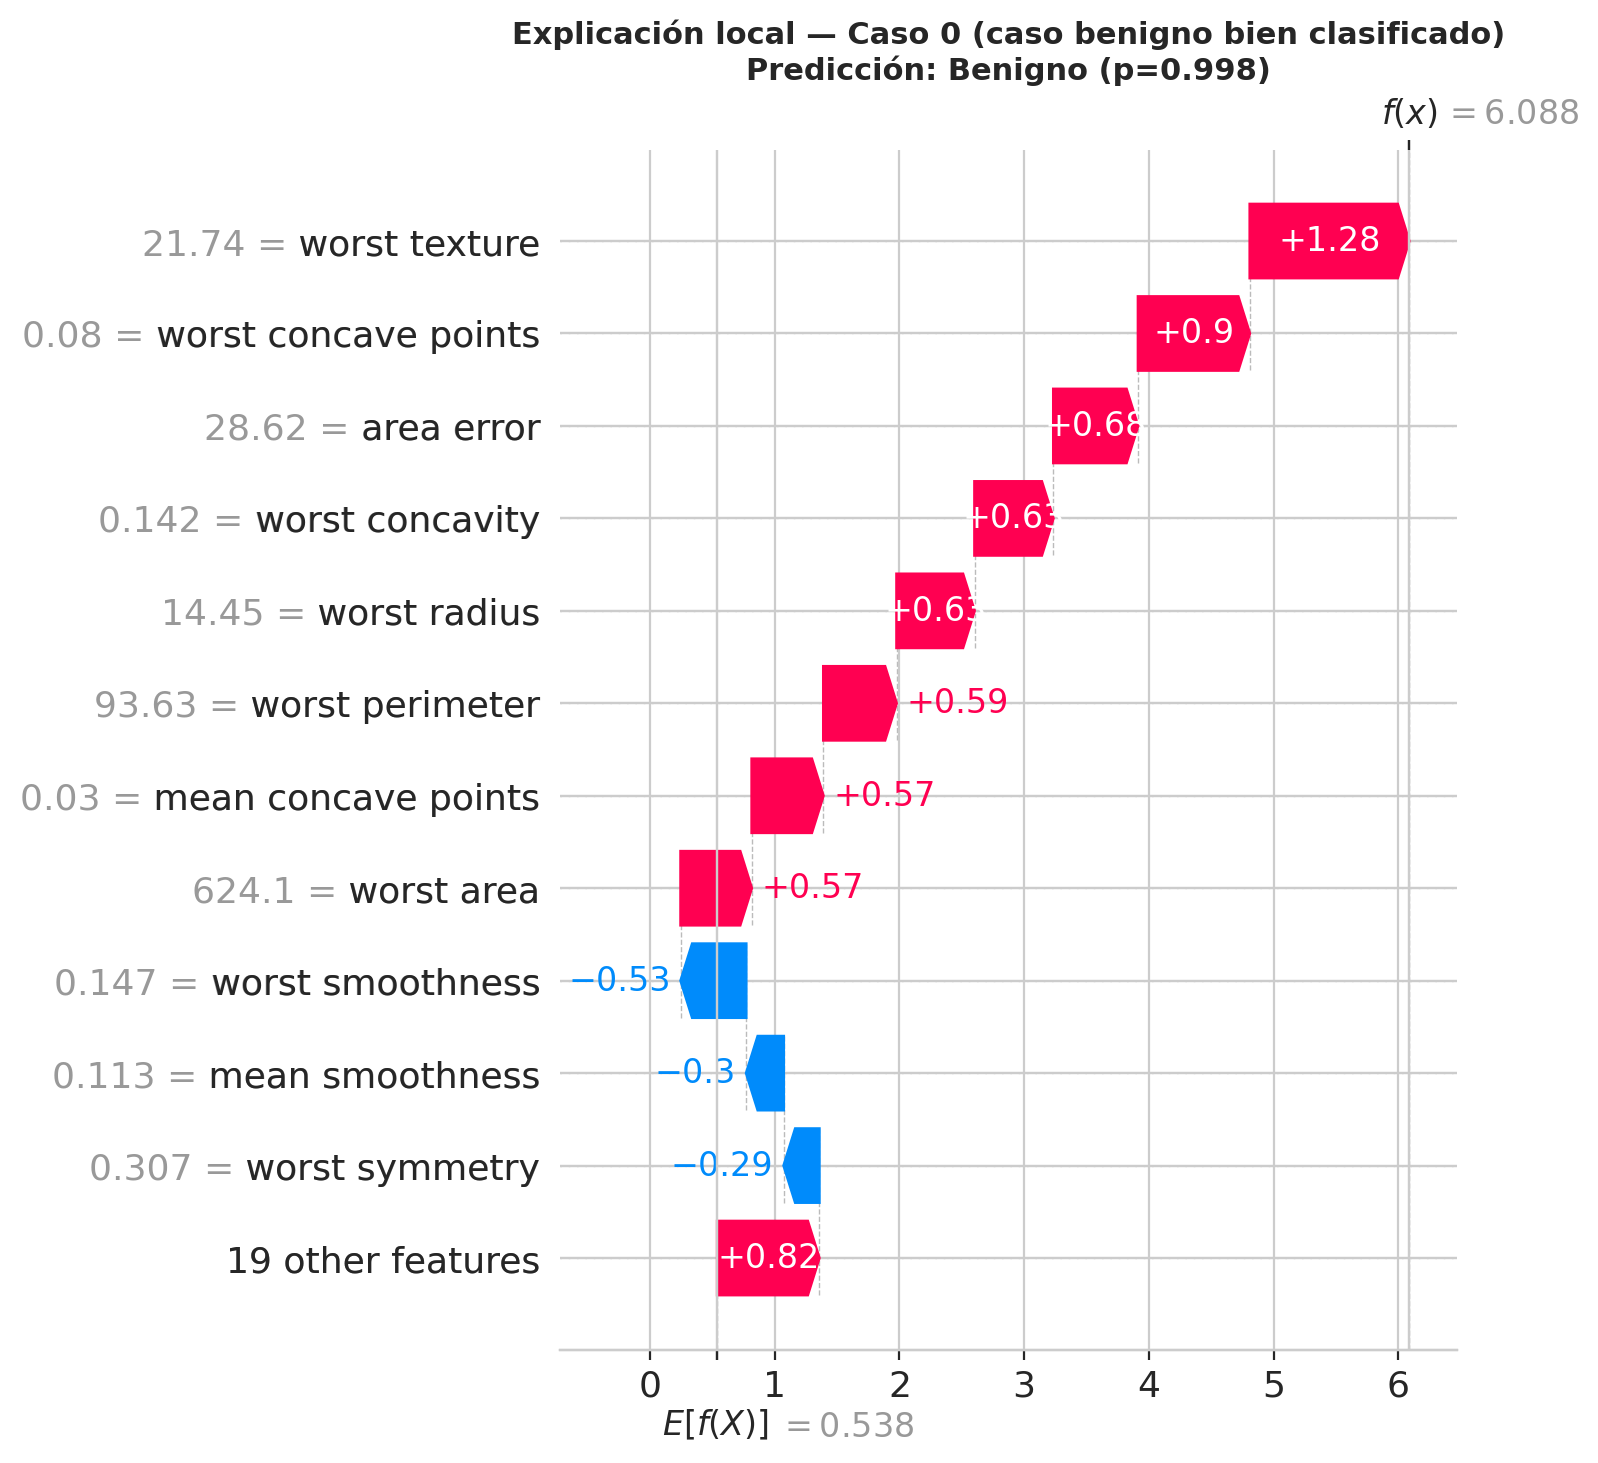

  Guardado: shap_waterfall_0.png

───────────────────────────────────────────────────────
Caso 5 — caso a revisar
  Predicción: Maligno (prob=0.0009)
  Real:       Maligno
  ¿Correcto?  ✓


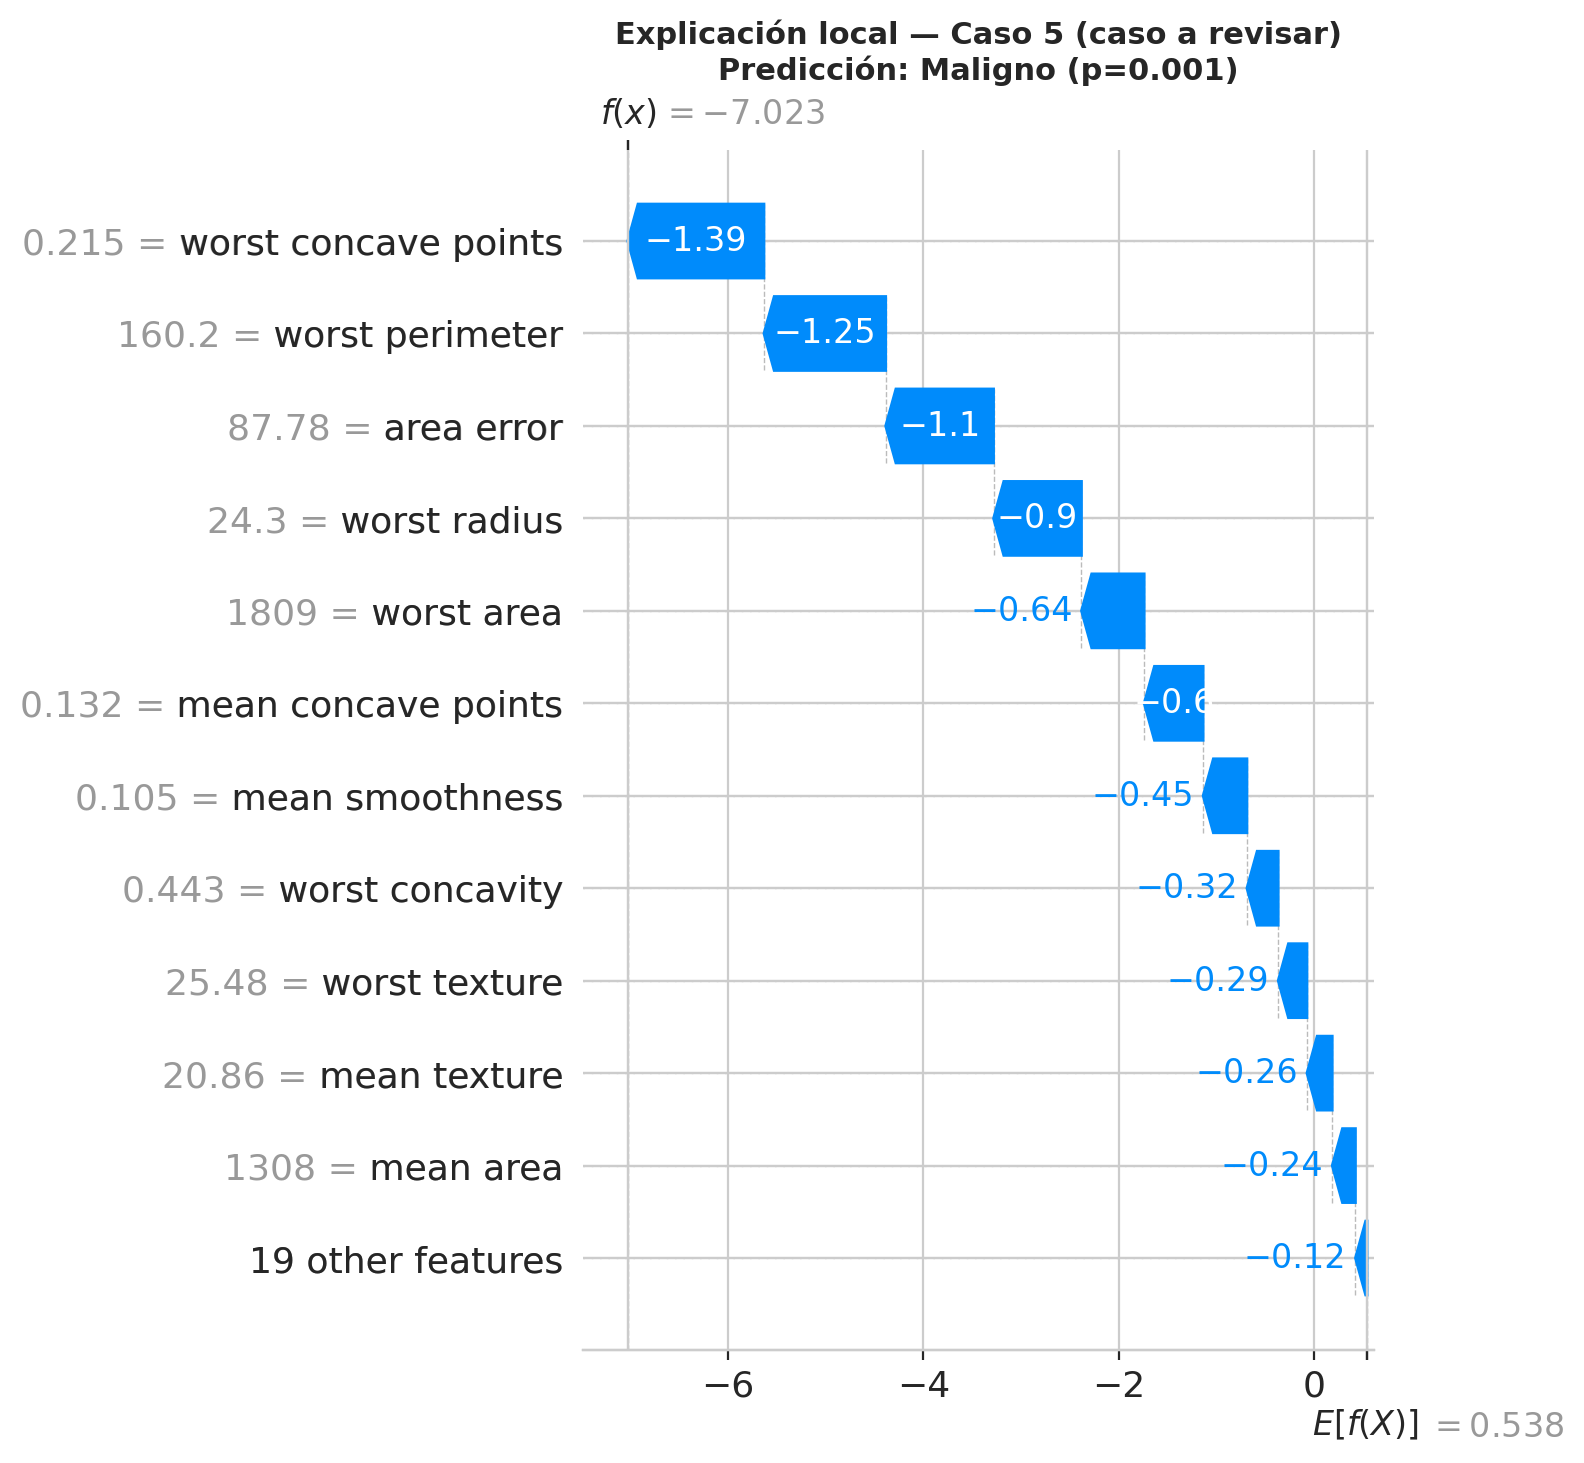

  Guardado: shap_waterfall_5.png


In [ ]:
#@title ── Waterfall plot (explicación de una instancia) ──────────────────
# Es la forma más clara de explicar una predicción individual
# Muestra exactamente cómo cada variable empuja desde la predicción base
# hasta la predicción final

for idx, descripcion in [(0, "caso benigno bien clasificado"),
                          (5, "caso a revisar")]:
    pred_clase = model.predict(X_test.iloc[[idx]])[0]
    pred_proba_caso = model.predict_proba(X_test.iloc[[idx]])[0, 1]
    real_clase  = y_test.iloc[idx]

    print(f"\n{'─'*55}")
    print(f"Caso {idx} — {descripcion}")
    print(f"  Predicción: {'Benigno' if pred_clase==1 else 'Maligno'} "
          f"(prob={pred_proba_caso:.4f})")
    print(f"  Real:       {'Benigno' if real_clase==1 else 'Maligno'}")
    print(f"  ¿Correcto?  {'✓' if pred_clase==real_clase else '✗'}")

    # Waterfall plot
    shap_explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx].values,
        feature_names=X_test.columns.tolist()
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    shap.plots.waterfall(shap_explanation, show=False, max_display=12)
    plt.title(f"Explicación local — Caso {idx} ({descripcion})\n"
              f"Predicción: {'Benigno' if pred_clase==1 else 'Maligno'} "
              f"(p={pred_proba_caso:.3f})",
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_{idx}.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f"  Guardado: shap_waterfall_{idx}.png")

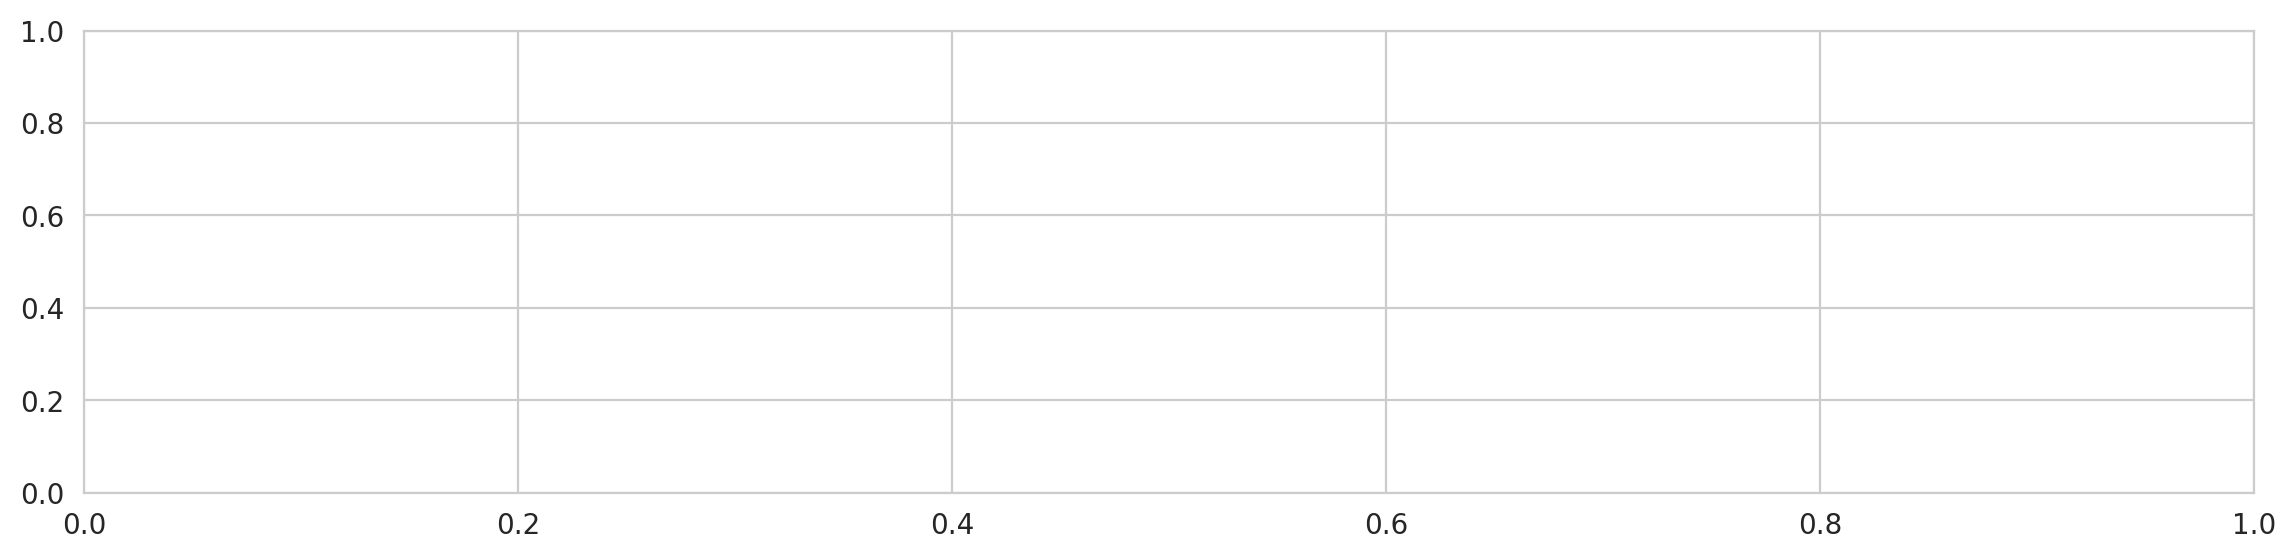

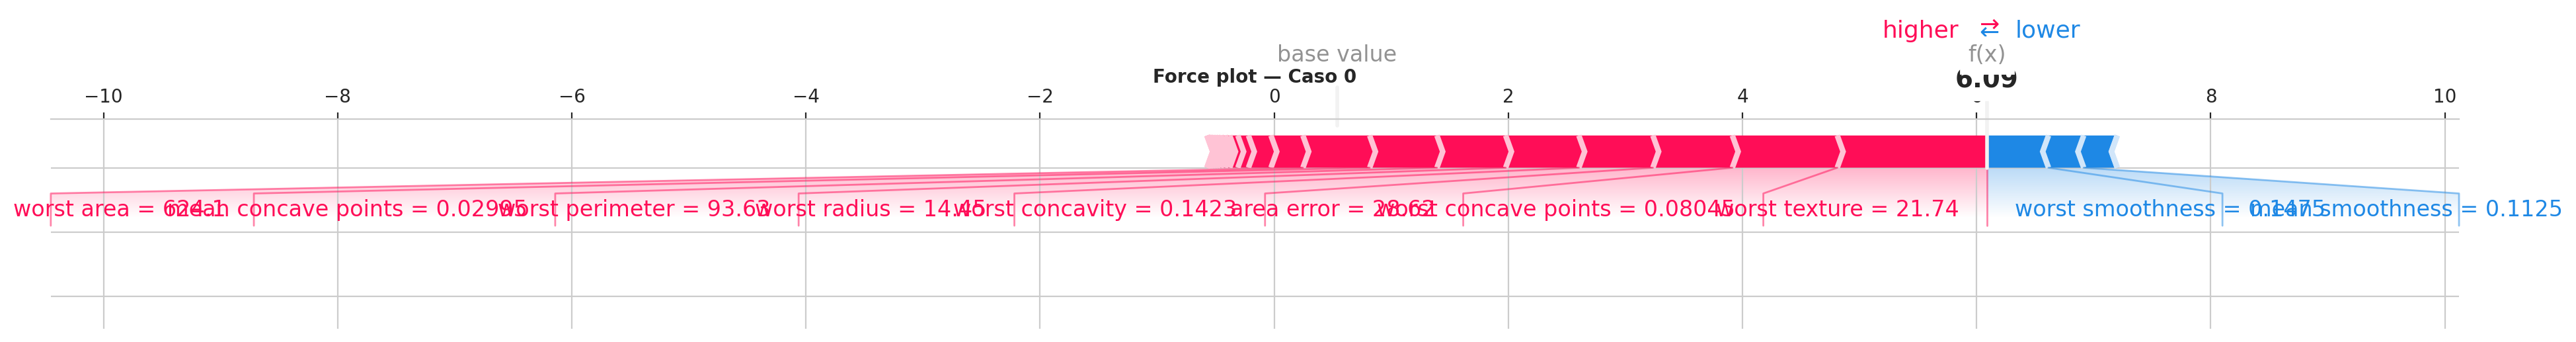

In [ ]:
#@title ── Force plot — versión alternativa para explicación local ───
# Visualización horizontal que muestra las fuerzas que empujan la predicción
fig, ax = plt.subplots(figsize=(14, 3))
shap.force_plot(
    base_value=explainer.expected_value,
    shap_values=shap_values[0],
    features=X_test.iloc[0],
    feature_names=X_test.columns.tolist(),
    matplotlib=True,
    show=False
)
plt.title("Force plot — Caso 0", fontsize=10, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 5.3.5 Análisis de dependencias

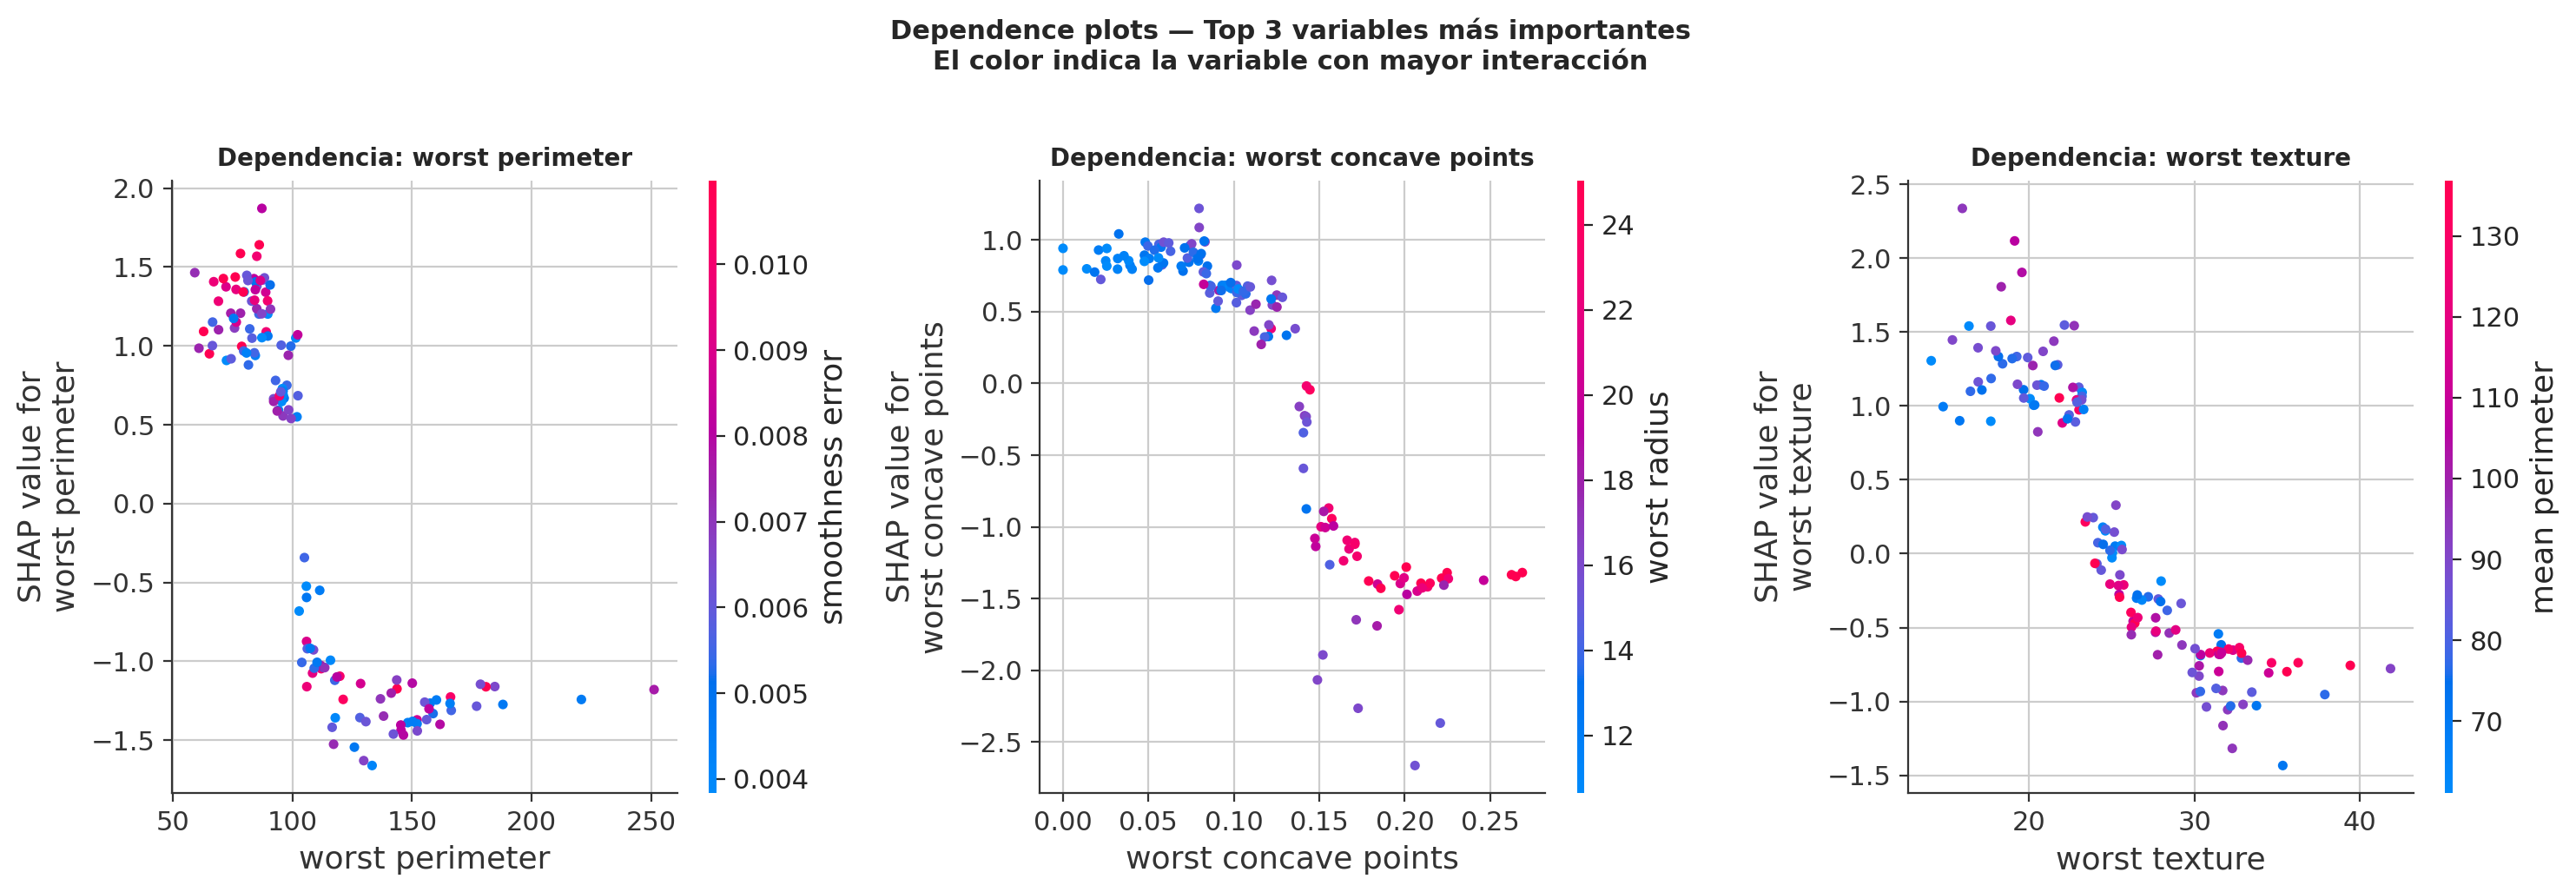

In [ ]:
#@title ── Dependence plot ────
# Muestra cómo varía el SHAP value de una variable en función de su valor
# El color muestra la variable con mayor interacción (detectado automáticamente)

top3_vars = shap_df.abs().mean().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, var in zip(axes, top3_vars):
    shap.dependence_plot(
        var,
        shap_values,
        X_test,
        ax=ax,
        show=False
    )
    ax.set_title(f'Dependencia: {var[:25]}', fontsize=10, fontweight='bold')

fig.suptitle('Dependence plots — Top 3 variables más importantes\n'
             'El color indica la variable con mayor interacción',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Calculando SHAP interaction values (puede tardar 1-2 min)...


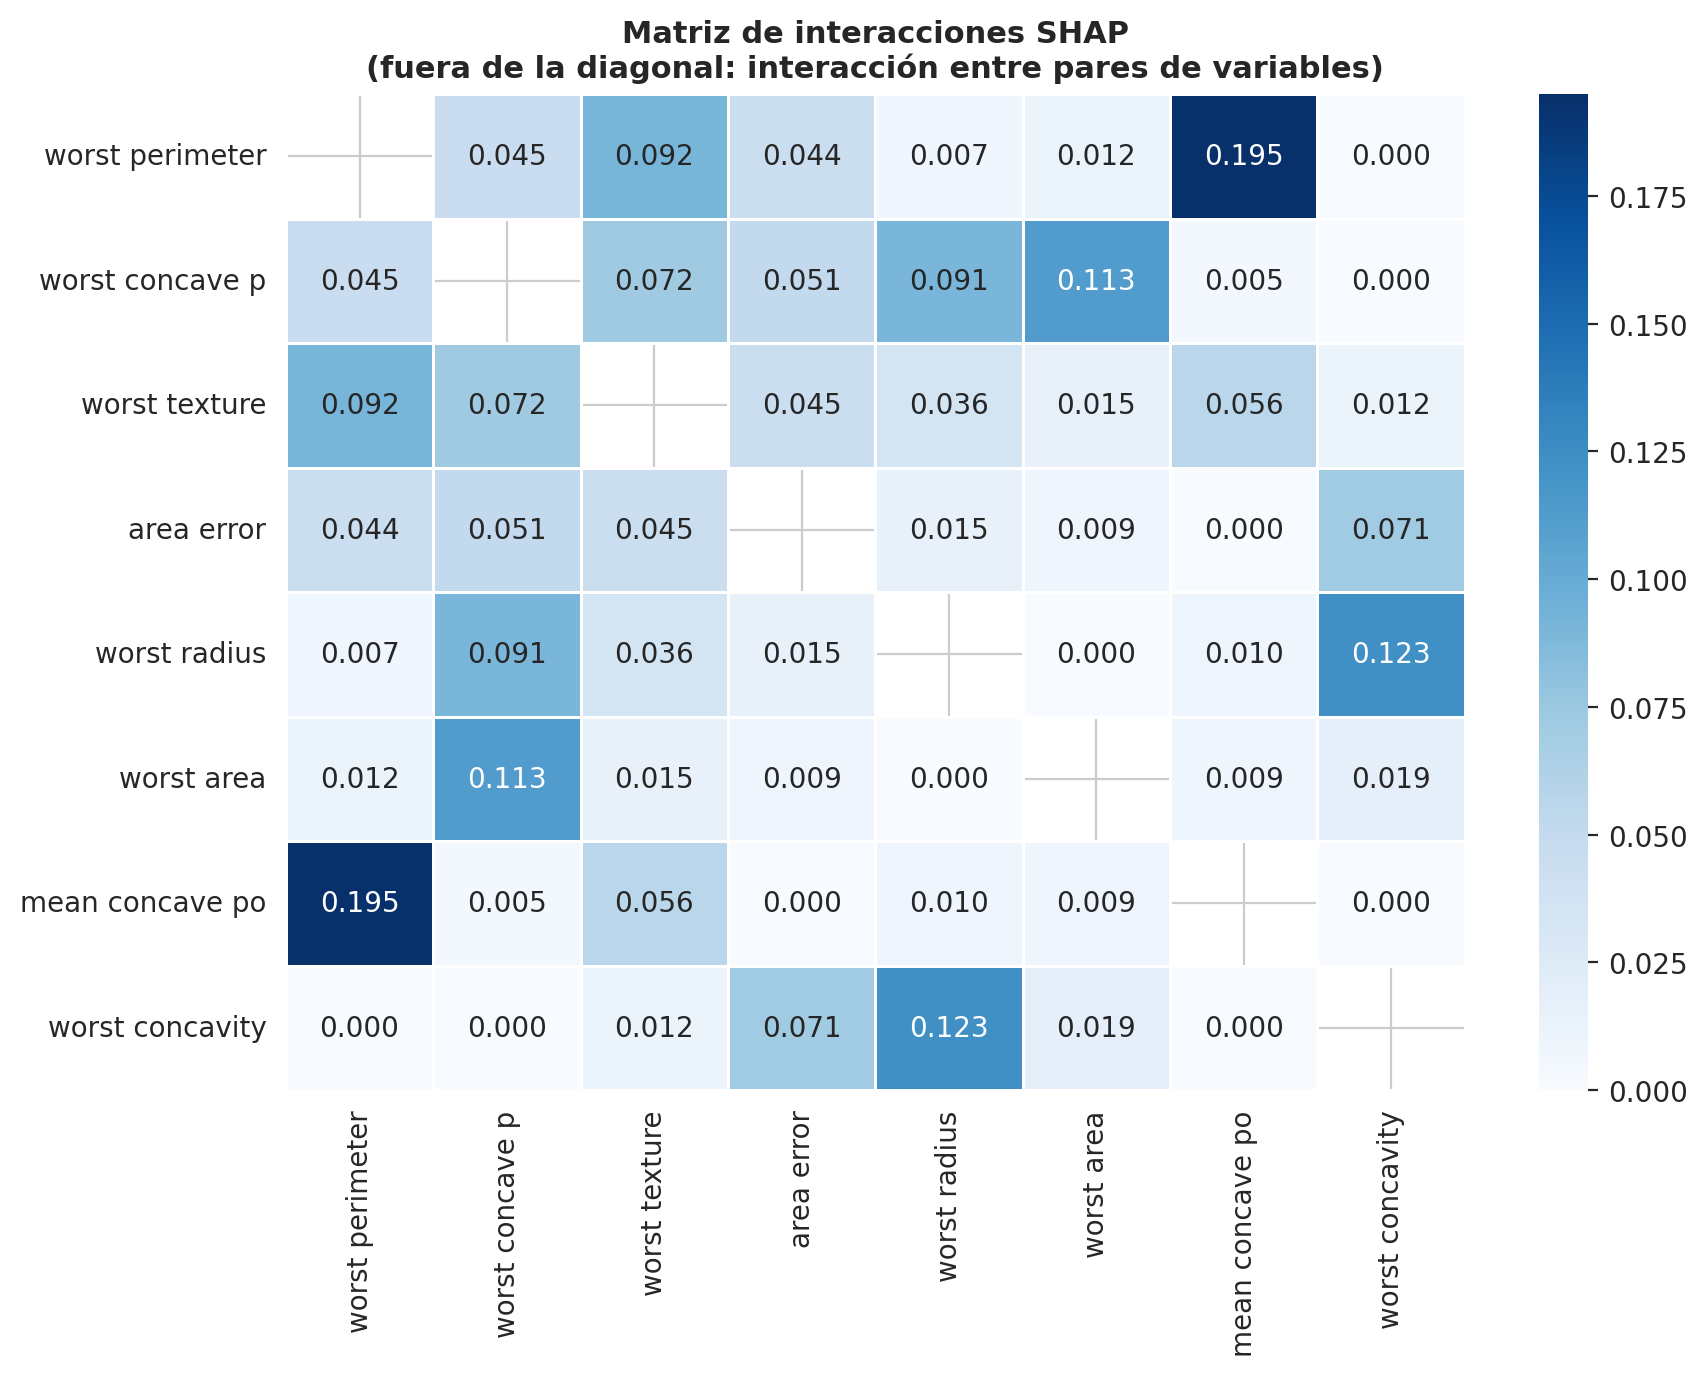

In [ ]:
#@title ── Interaction values ────
# Cuantifica la interacción entre pares de variables
# (requiere más tiempo de cómputo)
print("Calculando SHAP interaction values (puede tardar 1-2 min)...")
shap_interaction = explainer.shap_interaction_values(X_test.iloc[:50])

# Seleccionar las 8 variables más importantes
top8 = shap_df.abs().mean().sort_values(ascending=False).head(8).index
top8_idx = [list(X_test.columns).index(v) for v in top8]

# Matriz de interacciones medias
interaction_matrix = np.abs(shap_interaction[:, top8_idx, :][:, :, top8_idx]).mean(0)
interaction_df = pd.DataFrame(
    interaction_matrix,
    index=[v[:15] for v in top8],
    columns=[v[:15] for v in top8]
)

fig, ax = plt.subplots(figsize=(9, 7))
import seaborn as sns
mask = np.eye(len(top8), dtype=bool)
sns.heatmap(interaction_df, annot=True, fmt='.3f', cmap='Blues',
             mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Matriz de interacciones SHAP\n'
             '(fuera de la diagonal: interacción entre pares de variables)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## **5.4 LIME — Local Interpretable Model-Agnostic Explanations**


### 5.4.1 Cómo funciona LIME

LIME parte de un enfoque distinto al de SHAP: en lugar de calcular contribuciones exactas basadas en teoría de juegos, **entrena un modelo simple y transparente en el entorno local de la predicción a explicar**.

El algoritmo:
1. Tomar la instancia a explicar `x`.
2. Generar `n` perturbaciones de `x` (muestras cercanas en el espacio de características).
3. Obtener las predicciones del modelo caja negra para todas las perturbaciones.
4. Entrenar un modelo lineal ponderado sobre esas perturbaciones (las más cercanas a `x` reciben mayor peso).
5. Los coeficientes del modelo lineal son la explicación.

In [ ]:
#@title ── Crear el explicador LIME ─────

import lime
import lime.lime_tabular

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Maligno', 'Benigno'],
    mode='classification',
    discretize_continuous=True,    # discretiza variables continuas en rangos
    kernel_width=0.75,             # ancho del kernel: controla el "entorno local"
    random_state=42
)

print("Explicador LIME creado.")
print(f"  Modo: clasificación")
print(f"  Variables: {len(X_train.columns)}")
print(f"  Kernel width: 0.75 (cuanto menor, más local la explicación)")

Explicador LIME creado.
  Modo: clasificación
  Variables: 30
  Kernel width: 0.75 (cuanto menor, más local la explicación)



───────────────────────────────────────────────────────
Caso 0 — benigno con alta confianza
  P(Maligno)=0.002 | P(Benigno)=0.998
  Predicción: Benigno | Real: Benigno
  Score de fidelidad local (R²): 0.0001
  → Baja fidelidad de la explicación

  Top 5 variables más influyentes:
    516.83 < worst area <= 683.95            coef=+0.0000  → Benigno
    0.08 < worst fractal dimension <= 0.09   coef=+0.0000  → Benigno
    0.32 < radius error <= 0.47              coef=+0.0000  → Benigno
    0.01 < smoothness error <= 0.01          coef=+0.0000  → Benigno
    0.83 < texture error <= 1.07             coef=+0.0000  → Benigno


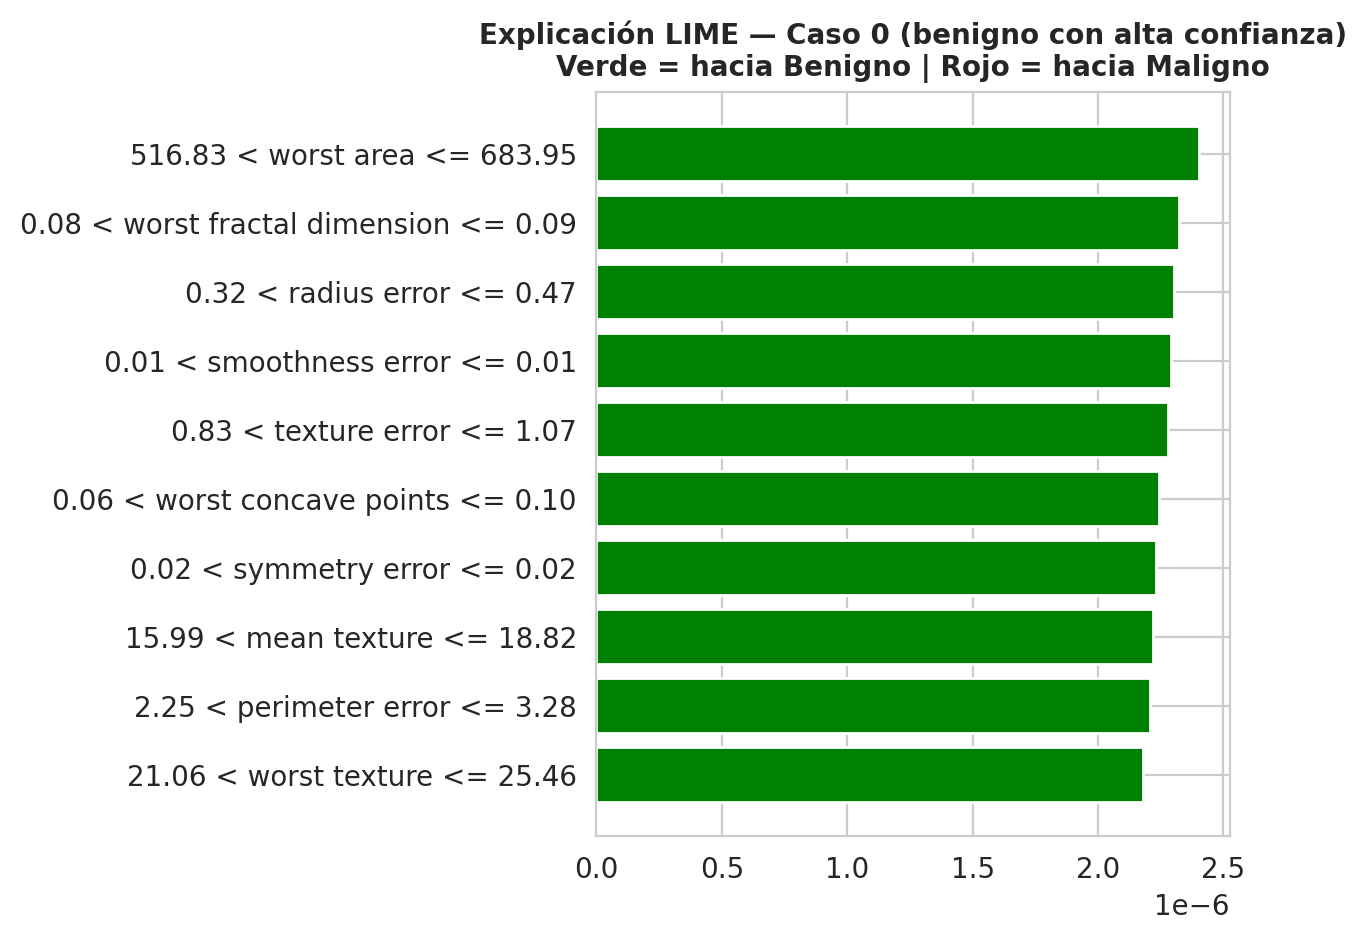


───────────────────────────────────────────────────────
Caso 10 — maligno con alta confianza
  P(Maligno)=0.027 | P(Benigno)=0.973
  Predicción: Benigno | Real: Benigno
  Score de fidelidad local (R²): 0.0002
  → Baja fidelidad de la explicación

  Top 5 variables más influyentes:
    21.06 < worst texture <= 25.46           coef=+0.0000  → Benigno
    0.00 < fractal dimension error <= 0.00   coef=+0.0000  → Benigno
    0.22 < worst compactness <= 0.34         coef=+0.0000  → Benigno
    0.32 < radius error <= 0.47              coef=+0.0000  → Benigno
    0.02 < symmetry error <= 0.02            coef=+0.0000  → Benigno


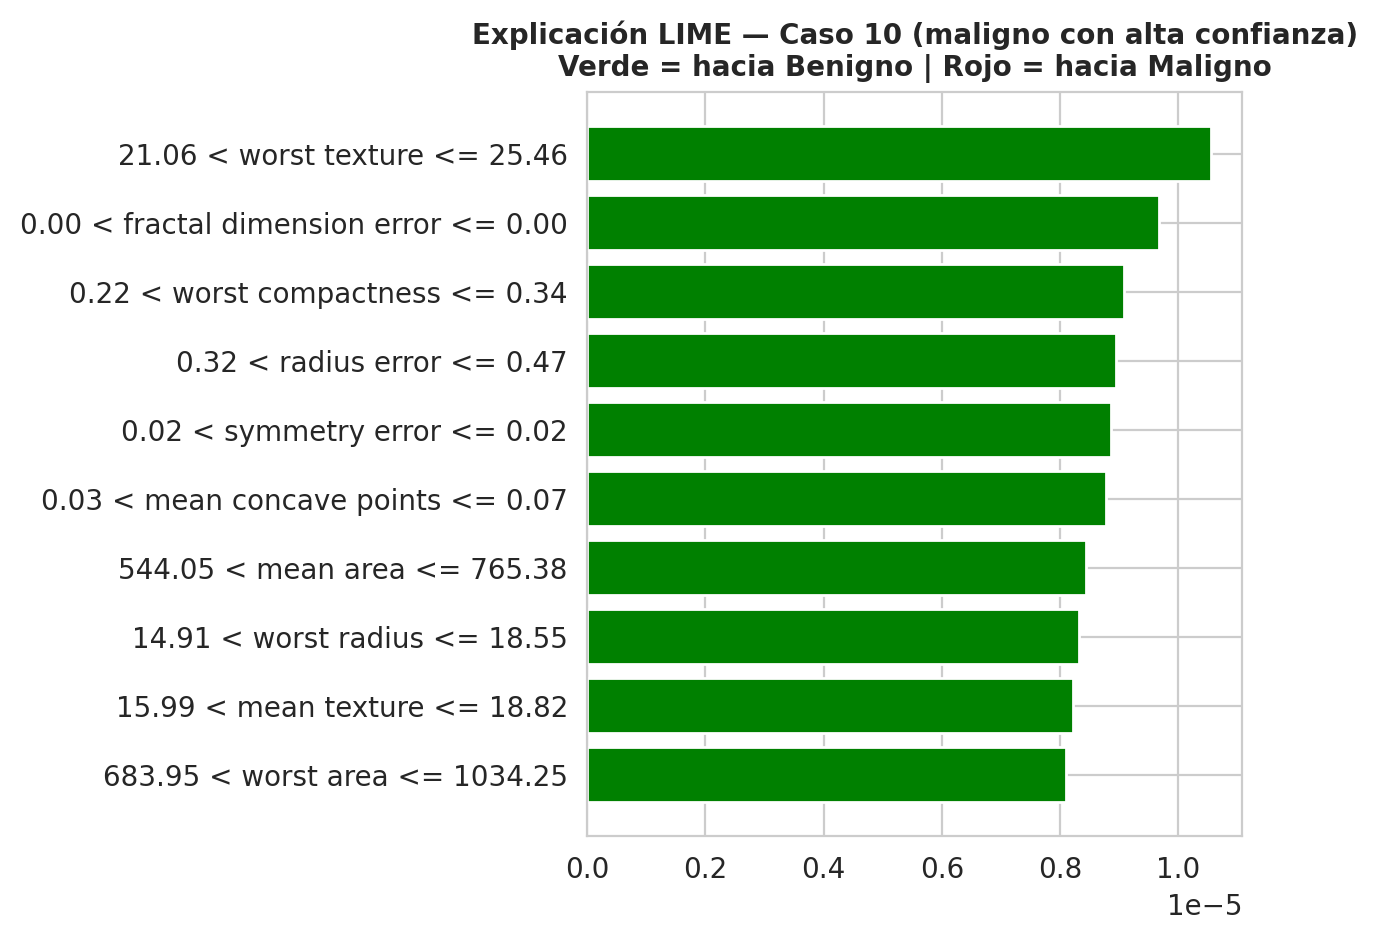


───────────────────────────────────────────────────────
Caso 25 — caso con predicción incierta
  P(Maligno)=0.001 | P(Benigno)=0.999
  Predicción: Benigno | Real: Benigno
  Score de fidelidad local (R²): 0.0001
  → Baja fidelidad de la explicación

  Top 5 variables más influyentes:
    21.06 < worst texture <= 25.46           coef=+0.0000  → Benigno
    516.83 < worst area <= 683.95            coef=+0.0000  → Benigno
    0.25 < worst symmetry <= 0.28            coef=+0.0000  → Benigno
    83.88 < worst perimeter <= 97.62         coef=+0.0000  → Benigno
    15.99 < mean texture <= 18.82            coef=+0.0000  → Benigno


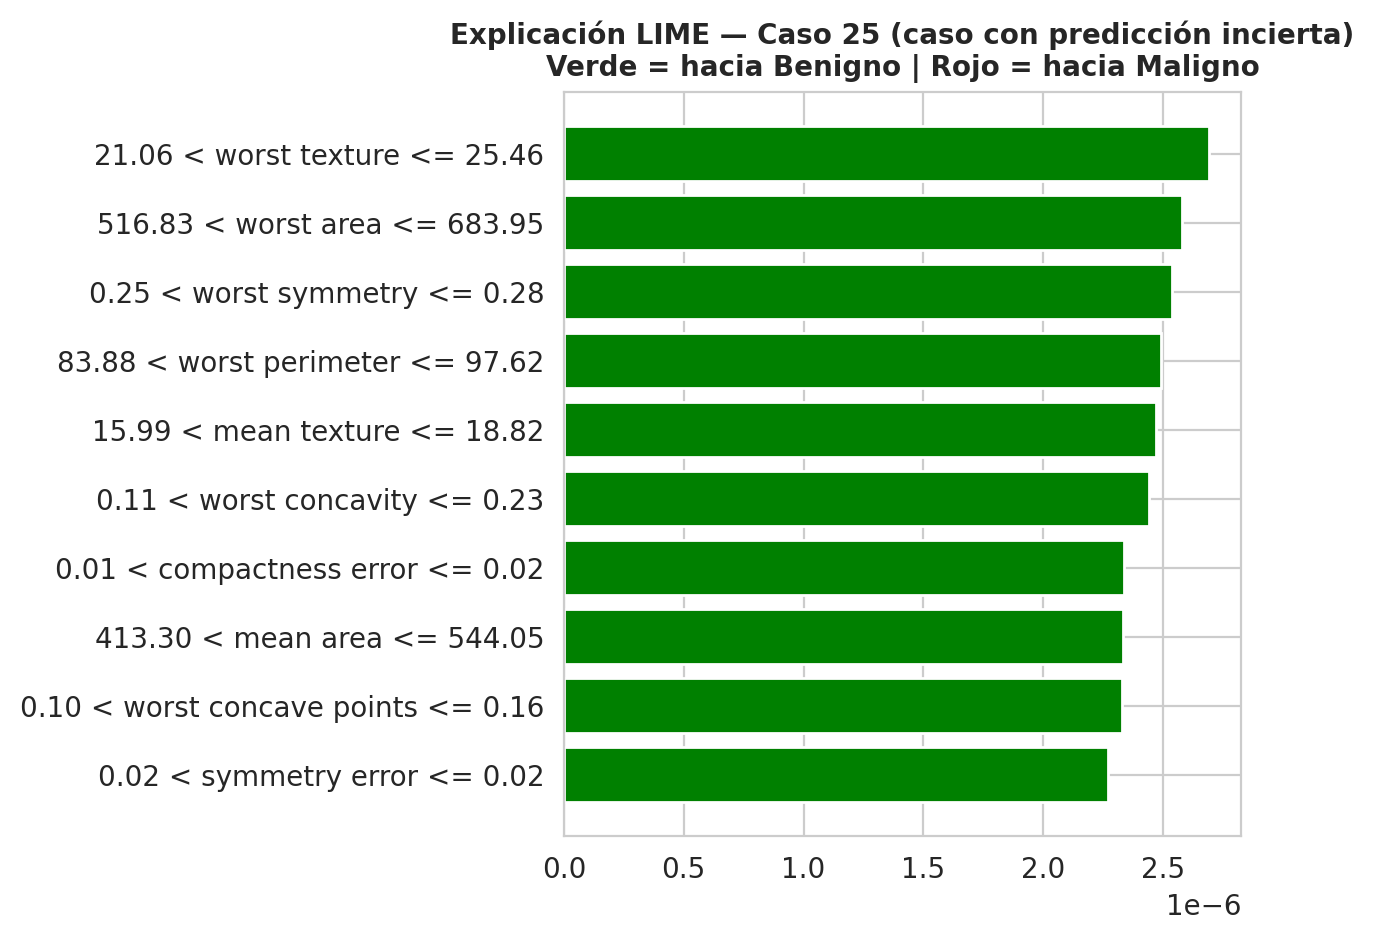

In [ ]:
#@title ── Explicación local de varios casos ────
casos_a_explicar = [
    (0,  "benigno con alta confianza"),
    (10, "maligno con alta confianza"),
    (25, "caso con predicción incierta"),
]

for idx, descripcion in casos_a_explicar:
    proba = model.predict_proba(X_test.iloc[[idx]])[0]
    pred  = model.predict(X_test.iloc[[idx]])[0]
    real  = y_test.iloc[idx]

    print(f"\n{'─'*55}")
    print(f"Caso {idx} — {descripcion}")
    print(f"  P(Maligno)={proba[0]:.3f} | P(Benigno)={proba[1]:.3f}")
    print(f"  Predicción: {'Benigno' if pred==1 else 'Maligno'} | "
          f"Real: {'Benigno' if real==1 else 'Maligno'}")

    exp = explainer_lime.explain_instance(
        data_row=X_test.iloc[idx].values,
        predict_fn=model.predict_proba,
        num_features=10,
        num_samples=1000
    )

    # Score de fidelidad: qué tan bien aproxima LIME al modelo en este punto
    print(f"  Score de fidelidad local (R²): {exp.score:.4f}")
    print(f"  → {'Alta' if exp.score>0.8 else 'Media' if exp.score>0.5 else 'Baja'}"
          f" fidelidad de la explicación")

    # Top features
    print(f"\n  Top 5 variables más influyentes:")
    for feat, coef in sorted(exp.as_list(), key=lambda x: abs(x[1]), reverse=True)[:5]:
        direccion = "→ Benigno" if coef > 0 else "→ Maligno"
        print(f"    {feat[:40]:<40} coef={coef:+.4f}  {direccion}")

    # Gráfico
    fig = exp.as_pyplot_figure()
    plt.title(f"Explicación LIME — Caso {idx} ({descripcion})\n"
              f"Verde = hacia Benigno | Rojo = hacia Maligno",
              fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 5.4.2 Estabilidad de LIME

Un problema conocido de LIME es que las explicaciones pueden variar entre ejecuciones por el muestreo aleatorio. Es buena práctica medir la estabilidad.

In [ ]:
#@title ── Medir estabilidad de LIME ────
print("Midiendo estabilidad de LIME (10 ejecuciones para el caso 0)...")

idx_estabilidad = 0
n_runs = 10
explicaciones = []

for run in range(n_runs):
    np.random.seed(run)   # Set numpy random seed for reproducibility
    exp_run = explainer_lime.explain_instance(
        data_row=X_test.iloc[idx_estabilidad].values,
        predict_fn=model.predict_proba,
        num_features=8,
        num_samples=500
    )
    coefs = dict(exp_run.as_list())
    explicaciones.append(coefs)

# Calcular varianza de cada coeficiente entre runs
df_estab = pd.DataFrame(explicaciones).fillna(0)

print(f"\nVariabilidad de coeficientes LIME ({n_runs} ejecuciones):")
print(f"{'Variable':<40} {'Media':>8} {'Std':>8} {'CV%':>8}")
print("─" * 65)
for col in df_estab.columns:
    media = df_estab[col].mean()
    std   = df_estab[col].std()
    cv    = abs(std / media * 100) if media != 0 else 0
    estable = "✓" if cv < 20 else "⚠️"
    print(f"  {col[:38]:<38} {media:>8.4f} {std:>8.4f} {cv:>7.1f}%  {estable}")

print("\n✓ CV < 20% = coeficiente estable entre ejecuciones")
print("⚠️ CV ≥ 20% = coeficiente inestable: interpretar con cautela")

Midiendo estabilidad de LIME (10 ejecuciones para el caso 0)...

Variabilidad de coeficientes LIME (10 ejecuciones):
Variable                                    Media      Std      CV%
─────────────────────────────────────────────────────────────────
  0.08 < worst fractal dimension <= 0.09   0.0000   0.0000   316.2%  ⚠️
  15.99 < mean texture <= 18.82            0.0000   0.0000   316.2%  ⚠️
  0.01 < smoothness error <= 0.01          0.0000   0.0000   165.9%  ⚠️
  2.25 < perimeter error <= 3.28           0.0000   0.0000   168.8%  ⚠️
  83.88 < worst perimeter <= 97.62         0.0000   0.0000   108.3%  ⚠️
  0.01 < concave points error <= 0.01      0.0000   0.0000   316.2%  ⚠️
  0.83 < texture error <= 1.07             0.0000   0.0000   121.3%  ⚠️
  11.63 < mean radius <= 13.27             0.0000   0.0000   142.1%  ⚠️
  13.02 < worst radius <= 14.91            0.0000   0.0000   115.9%  ⚠️
  0.11 < worst concavity <= 0.23           0.0000   0.0000   151.9%  ⚠️
  21.06 < worst texture <= 25

## **5.5 Explicaciones contrafactuales con DICE**

Las explicaciones contrafactuales responden a: **"¿Qué tendría que cambiar en este caso para obtener una predicción diferente?"**

Son especialmente valiosas para las personas afectadas por una decisión negativa, porque les indican qué acciones concretas podrían cambiar el resultado.

In [ ]:
#@title ── Preparar DICE ────

import dice_ml
from dice_ml import Dice

# DICE necesita conocer los rangos y tipos de las variables
d = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train.rename('target')], axis=1),
    continuous_features=X_train.columns.tolist(),
    outcome_name='target'
)

# Envolver el modelo
m = dice_ml.Model(model=model, backend='sklearn')

# Crear el explicador contrafactual
exp_cf = Dice(d, m, method='random')

print("Explicador DICE creado.")

Explicador DICE creado.


In [ ]:
#@title ── Generar contrafactuales para un caso mal clasificado ───
# Buscar casos clasificados como Maligno que en realidad son Benignos
falsos_negativos = X_test[
    (model.predict(X_test) == 0) & (y_test == 1)
].reset_index(drop=True)

if len(falsos_negativos) > 0:
    caso_cf = falsos_negativos.iloc[[0]]
    print(f"Caso seleccionado para contrafactual:")
    print(f"  Predicción del modelo: Maligno (incorrecto)")
    print(f"  Etiqueta real: Benigno")
    print(f"  Probabilidad de benigno: "
          f"{model.predict_proba(caso_cf)[0,1]:.4f}")

    # Generar 3 contrafactuales hacia la clase Benigno (clase 1)
    cf_result = exp_cf.generate_counterfactuals(
        query_instances=caso_cf,
        total_CFs=3,
        desired_class=1,         # queremos que prediga Benigno
        features_to_vary='all',  # puede variar todas las variables
        random_seed=42
    )

    print("\nContrafactuales generados:")
    print("(Qué valores debería tener el caso para ser clasificado como Benigno)")
    cf_result.visualize_as_dataframe(show_only_changes=True)
else:
    print("No hay falsos negativos en el test set para este modelo.")

Caso seleccionado para contrafactual:
  Predicción del modelo: Maligno (incorrecto)
  Etiqueta real: Benigno
  Probabilidad de benigno: 0.3472


100%|██████████| 1/1 [00:01<00:00,  1.21s/it]


Contrafactuales generados:
(Qué valores debería tener el caso para ser clasificado como Benigno)
Query instance (original outcome : 0)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,14.96,19.1,97.029999,687.299988,0.08992,0.09823,0.0594,0.04819,0.1879,0.05852,...,26.190001,109.099998,809.799988,0.1313,0.303,0.1804,0.1489,0.2962,0.08472,0



Diverse Counterfactual set (new outcome: 1)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,0.1639,-,1.0
1,-,-,-,-,-,-,-,-,-,-,...,24.59,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,0.1694,0.05891,1.0


In [ ]:
#@title ── Contrafactuales con restricciones ───
# En contextos reales, no todas las variables son accionables
# (p.ej. la edad no se puede cambiar; el tamaño del tumor sí puede cambiar
# con tratamiento)

# Variables que son potencialmente accionables (simplificación ilustrativa)
variables_accionables = [
    'mean smoothness', 'mean compactness', 'mean concavity',
    'mean concave points', 'worst smoothness', 'worst compactness'
]

if len(falsos_negativos) > 0:
    cf_restringido = exp_cf.generate_counterfactuals(
        query_instances=caso_cf,
        total_CFs=3,
        desired_class=1,
        features_to_vary=variables_accionables,
        random_seed=42
    )
    print("Contrafactuales con variables restringidas a accionables:")
    cf_restringido.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  3.39it/s]

Contrafactuales con variables restringidas a accionables:
Query instance (original outcome : 0)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,14.96,19.1,97.029999,687.299988,0.08992,0.09823,0.0594,0.04819,0.1879,0.05852,...,26.190001,109.099998,809.799988,0.1313,0.303,0.1804,0.1489,0.2962,0.08472,0



Diverse Counterfactual set (new outcome: 1)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,-,-,-,-,0.0678,-,-,-,-,-,...,-,-,-,0.081,-,-,-,-,-,1.0
1,-,-,-,-,-,-,-,0.0,-,-,...,-,-,-,0.0887,-,-,-,-,-,1.0
2,-,-,-,-,0.0717,-,-,-,-,-,...,-,-,-,0.0881,-,-,-,-,-,1.0


## **5.6 ANCHOR: explicaciones basadas en reglas**

ANCHOR genera explicaciones en forma de reglas lógicas "si–entonces" que garantizan la predicción con alta precisión, independientemente del resto de las variables.

In [ ]:
#@title ── ANCHOR: reglas de alta precisión ─────
import alibi
from alibi.explainers import AnchorTabular
from alibi.utils.wrappers import ArgmaxTransformer

# Envolver el modelo para que devuelva clases, no probabilidades
predict_fn = lambda x: model.predict(x)

# Crear el explicador ANCHOR
anchor_explainer = AnchorTabular(
    predictor=predict_fn,
    feature_names=X_train.columns.tolist()
)
anchor_explainer.fit(X_train.values, disc_perc=(25, 50, 75))

print("Explicador ANCHOR creado.")

Explicador ANCHOR creado.


In [ ]:
#@title ── Generar una explicación ANCHOR ───
idx_anchor = 0
explanation_anchor = anchor_explainer.explain(
    X_test.iloc[idx_anchor].values,
    threshold=0.95    # precisión mínima de la regla: 95%
)

print(f"{'═'*55}")
print(f"EXPLICACIÓN ANCHOR — Caso {idx_anchor}")
print(f"{'═'*55}")
print(f"\nPredicción: {'Benigno' if model.predict(X_test.iloc[[idx_anchor]])[0]==1 else 'Maligno'}")
print(f"Real:       {'Benigno' if y_test.iloc[idx_anchor]==1 else 'Maligno'}")
print(f"\nRegla generada:")
for condicion in explanation_anchor.anchor:
    print(f"  SI  {condicion}")
print(f"\n→ ENTONCES predice: {'Benigno' if model.predict(X_test.iloc[[idx_anchor]])[0]==1 else 'Maligno'}")
print(f"\nMétricas de la regla:")
print(f"  Precisión:  {explanation_anchor.precision:.4f}  "
      f"(de los casos que satisfacen la regla, el {explanation_anchor.precision:.1%} "
      f"recibe esta predicción)")
print(f"  Cobertura:  {explanation_anchor.coverage:.4f}  "
      f"(el {explanation_anchor.coverage:.1%} del espacio de instancias satisface la regla)")

═══════════════════════════════════════════════════════
EXPLICACIÓN ANCHOR — Caso 0
═══════════════════════════════════════════════════════

Predicción: Benigno
Real:       Benigno

Regla generada:
  SI  worst texture <= 25.46
  SI  worst radius <= 14.91

→ ENTONCES predice: Benigno

Métricas de la regla:
  Precisión:  0.9935  (de los casos que satisfacen la regla, el 99.3% recibe esta predicción)
  Cobertura:  0.5000  (el 50.0% del espacio de instancias satisface la regla)


## **5.7 SHAP vs LIME vs ANCHOR: comparativa completa**

In [ ]:
#@title ── Comparativa visual: SHAP, LIME y ANCHOR para el mismo caso ────
idx_comp = 10   # un caso de prueba concreto
pred_comp  = model.predict(X_test.iloc[[idx_comp]])[0]
proba_comp = model.predict_proba(X_test.iloc[[idx_comp]])[0, 1]

print(f"{'═'*60}")
print(f"COMPARATIVA SHAP / LIME / ANCHOR — Caso {idx_comp}")
print(f"Predicción: {'Benigno' if pred_comp==1 else 'Maligno'} | "
      f"P(Benigno)={proba_comp:.4f}")
print(f"{'═'*60}")

# SHAP top 5
print("\n[SHAP] Top 5 variables por impacto:")
shap_caso = shap_values[idx_comp]
shap_top  = sorted(zip(X_test.columns, shap_caso),
                    key=lambda x: abs(x[1]), reverse=True)[:5]
for feat, val in shap_top:
    print(f"  {feat[:35]:<35} SHAP={val:+.4f}")

# LIME top 5
exp_comp = explainer_lime.explain_instance(
    X_test.iloc[idx_comp].values,
    model.predict_proba,
    num_features=5,
    num_samples=1000
)
print(f"\n[LIME] Top 5 variables (R²={exp_comp.score:.4f}):")
for feat, coef in sorted(exp_comp.as_list(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat[:35]:<35} coef={coef:+.4f}")

# ANCHOR
exp_anch = anchor_explainer.explain(X_test.iloc[idx_comp].values, threshold=0.90)
print(f"\n[ANCHOR] Regla (precisión={exp_anch.precision:.4f}, "
      f"cobertura={exp_anch.coverage:.4f}):")
for cond in exp_anch.anchor:
    print(f"  SI {cond}")

════════════════════════════════════════════════════════════
COMPARATIVA SHAP / LIME / ANCHOR — Caso 10
Predicción: Benigno | P(Benigno)=0.9733
════════════════════════════════════════════════════════════

[SHAP] Top 5 variables por impacto:
  worst texture                       SHAP=+1.4389
  mean concave points                 SHAP=+1.3188
  worst radius                        SHAP=+0.5580
  worst perimeter                     SHAP=-0.5501
  mean texture                        SHAP=+0.4892

[LIME] Top 5 variables (R²=0.0000):
  15.99 < mean texture <= 18.82       coef=+0.0000
  24.27 < area error <= 45.13         coef=+0.0000
  0.06 < mean fractal dimension <= 0. coef=+0.0000
  0.00 < fractal dimension error <= 0 coef=+0.0000
  0.09 < mean compactness <= 0.13     coef=+0.0000

[ANCHOR] Regla (precisión=0.9580, cobertura=0.5000):
  SI worst texture <= 25.46
  SI worst area <= 1034.25
  SI worst smoothness <= 0.13


In [ ]:
#@title ── Tabla resumen de propiedades ───
propiedades = {
    'Consistencia matemática':      ['Alta (axomática)',   'Media (muestreo)',    'Alta (precis. garantizada)'],
    'Explicaciones globales':        ['Sí',                'No (solo local)',     'No (solo local)'],
    'Tipo de salida':                ['Valores numéricos', 'Valores numéricos',   'Reglas lógicas'],
    'Facilidad de comunicación':     ['Media',             'Alta',                'Muy alta'],
    'Velocidad (modelos árbol)':     ['Rápido',            'Moderado',            'Moderado'],
    'Velocidad (redes neuronales)':  ['Lento (Kernel)',    'Rápido',              'Moderado'],
    'Funciona con cualquier modelo': ['Sí',                'Sí',                  'Sí'],
    'Estabilidad entre ejecuciones': ['Alta',              'Media (muestreo)',     'Alta'],
    'Detecta interacciones':         ['Sí (SHAP interact.)','Limitado',           'No'],
    'Explicación accionable':        ['Parcialmente',       'Parcialmente',        'Sí (si-entonces)'],
}

df_prop = pd.DataFrame(
    propiedades,
    index=['SHAP', 'LIME', 'ANCHOR']
).T

print("═" * 70)
print("COMPARATIVA: SHAP vs LIME vs ANCHOR")
print("═" * 70)
print(df_prop.to_string())

══════════════════════════════════════════════════════════════════════
COMPARATIVA: SHAP vs LIME vs ANCHOR
══════════════════════════════════════════════════════════════════════
                                              SHAP               LIME                      ANCHOR
Consistencia matemática           Alta (axomática)   Media (muestreo)  Alta (precis. garantizada)
Explicaciones globales                          Sí    No (solo local)             No (solo local)
Tipo de salida                   Valores numéricos  Valores numéricos              Reglas lógicas
Facilidad de comunicación                    Media               Alta                    Muy alta
Velocidad (modelos árbol)                   Rápido           Moderado                    Moderado
Velocidad (redes neuronales)        Lento (Kernel)             Rápido                    Moderado
Funciona con cualquier modelo                   Sí                 Sí                          Sí
Estabilidad entre ejecuciones         

## **5.8 Explicabilidad y equidad: detectar proxies con SHAP**

Una de las aplicaciones más valiosas de XAI en el contexto de ética en IA es usar las explicaciones para detectar si el modelo está usando variables proxy de atributos protegidos.

In [ ]:
#@title ── Detectar proxies con SHAP ───
# Usamos el dataset German Credit para ilustrar el caso con variables sensibles

from sklearn.preprocessing import LabelEncoder
import urllib.request

url_gc = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
          "statlog/german/german.data")
cols_gc = [
    'checking_account', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment', 'installment_rate',
    'personal_status', 'other_debtors', 'residence_since', 'property',
    'age', 'other_installments', 'housing', 'existing_credits', 'job',
    'num_dependents', 'telephone', 'foreign_worker', 'credit_risk'
]
df_gc = pd.read_csv(url_gc, sep=' ', header=None, names=cols_gc)
df_gc['credit_risk'] = (df_gc['credit_risk'] == 1).astype(int)
df_gc['genero'] = df_gc['personal_status'].apply(
    lambda x: 1 if x in ['A91', 'A93', 'A94'] else 0)

# Codificar y preparar
cat_gc = ['checking_account', 'credit_history', 'purpose', 'savings_account',
          'employment', 'other_debtors', 'property', 'other_installments',
          'housing', 'job', 'telephone', 'foreign_worker']
df_enc = df_gc.copy()
le = LabelEncoder()
for c in cat_gc:
    df_enc[c] = le.fit_transform(df_enc[c].astype(str))

feats_gc = [c for c in cols_gc[:-1] if c != 'personal_status']
X_gc = df_enc[feats_gc]
y_gc = df_enc['credit_risk']
genero_gc = df_enc['genero']

X_tr_gc, X_te_gc, y_tr_gc, y_te_gc, g_tr, g_te = train_test_split(
    X_gc, y_gc, genero_gc, test_size=0.3, random_state=42)

# Entrenar XGBoost sobre German Credit
model_gc = xgb.XGBClassifier(n_estimators=100, random_state=42,
                               eval_metric='logloss', use_label_encoder=False)
model_gc.fit(X_tr_gc, y_tr_gc)

# SHAP values
explainer_gc = shap.TreeExplainer(model_gc)
shap_gc = explainer_gc.shap_values(X_te_gc)
shap_gc_df = pd.DataFrame(shap_gc, columns=X_te_gc.columns)

In [ ]:
#@title ── Análisis de correlación entre SHAP values y atributo sensible ───
print("═" * 58)
print("DETECCIÓN DE PROXIES — Correlación SHAP × Género")
print("═" * 58)

genero_reset = g_te.reset_index(drop=True)
correlaciones = shap_gc_df.corrwith(genero_reset)
correlaciones_abs = correlaciones.abs().sort_values(ascending=False)

print("\nCorrelación entre SHAP values y género (|r| mayor = más sospechoso):")
print(f"\n{'Variable':<30} {'r':>8} {'|r|':>8}  Alerta")
print("─" * 55)
for var in correlaciones_abs.head(12).index:
    r   = correlaciones[var]
    abs_r = abs(r)
    alerta = "⚠️  PROXY POTENCIAL" if abs_r > 0.2 else ("🔍 Revisar" if abs_r > 0.1 else "")
    print(f"  {var:<28} {r:>8.4f} {abs_r:>8.4f}  {alerta}")

print("\n→ Variables con |r| > 0.2 pueden estar actuando como proxies del género.")
print("  Esto significa que el modelo puede estar discriminando por género de forma")
print("  indirecta, aunque 'género' no sea una variable del modelo.")

══════════════════════════════════════════════════════════
DETECCIÓN DE PROXIES — Correlación SHAP × Género
══════════════════════════════════════════════════════════

Correlación entre SHAP values y género (|r| mayor = más sospechoso):

Variable                              r      |r|  Alerta
───────────────────────────────────────────────────────
  age                            0.2057   0.2057  ⚠️  PROXY POTENCIAL
  housing                        0.1620   0.1620  🔍 Revisar
  employment                     0.1601   0.1601  🔍 Revisar
  purpose                       -0.1025   0.1025  🔍 Revisar
  telephone                      0.0904   0.0904  
  duration                      -0.0894   0.0894  
  other_debtors                  0.0850   0.0850  
  credit_amount                  0.0808   0.0808  
  checking_account              -0.0771   0.0771  
  residence_since               -0.0694   0.0694  
  foreign_worker                 0.0675   0.0675  
  num_dependents                -0.0615   

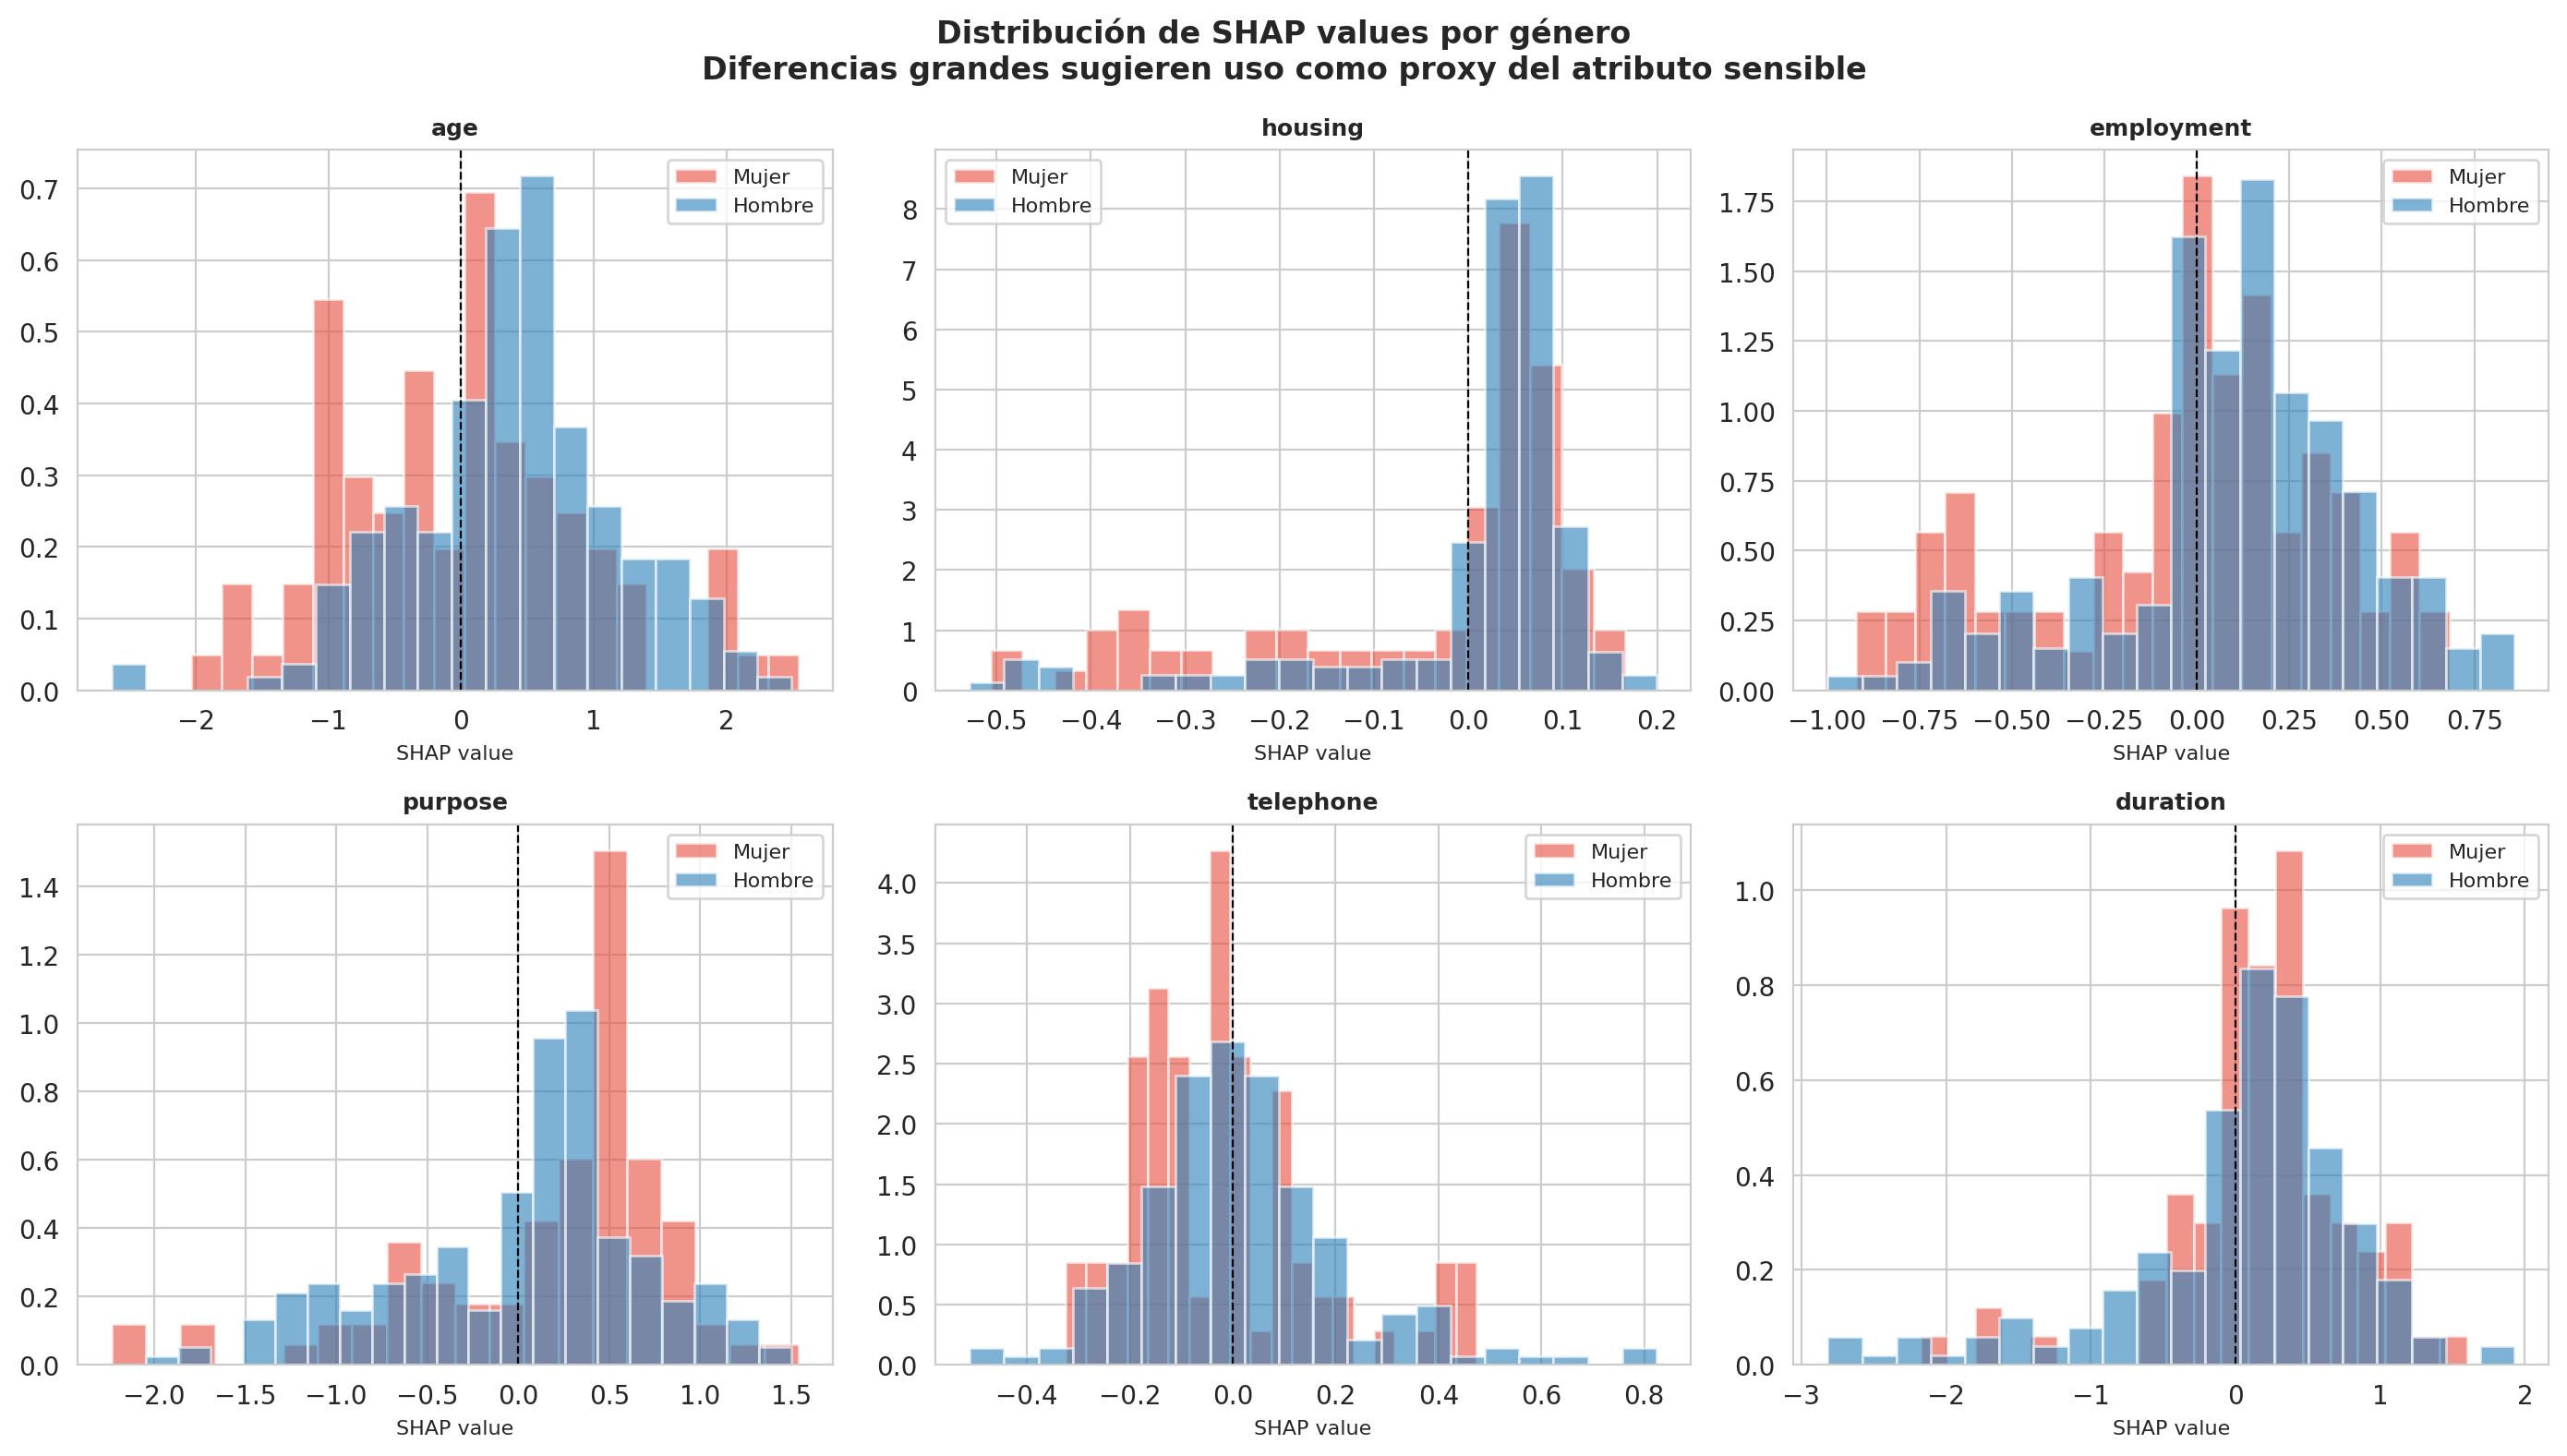

In [ ]:
#@title ── Visualización: SHAP values por grupo de género ───
top_proxy = correlaciones_abs.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribución de SHAP values por género\n'
             'Diferencias grandes sugieren uso como proxy del atributo sensible',
             fontsize=12, fontweight='bold')

for ax, var in zip(axes.flat, top_proxy):
    for genero_val, label, color in [(0, 'Mujer', '#E74C3C'),
                                      (1, 'Hombre', '#2980B9')]:
        mask = genero_reset == genero_val
        ax.hist(shap_gc_df.loc[mask, var], bins=20, alpha=0.6,
                color=color, label=label, density=True)
    ax.set_title(var[:30], fontsize=9, fontweight='bold')
    ax.set_xlabel('SHAP value', fontsize=8)
    ax.legend(fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

## 5.9 Explicabilidad para usuarios finales: buenas prácticas

La explicabilidad técnica no es suficiente si las explicaciones no son comprensibles para la persona que las necesita. Hay tres audiencias distintas con necesidades diferentes:

In [ ]:
#@title ── Tres niveles de explicación para la misma predicción ───
idx_exp_final = 0
pred_f  = model.predict(X_test.iloc[[idx_exp_final]])[0]
proba_f = model.predict_proba(X_test.iloc[[idx_exp_final]])[0, 1]
shap_f  = sorted(zip(X_test.columns, shap_values[idx_exp_final]),
                  key=lambda x: abs(x[1]), reverse=True)

print("═" * 65)
print("TRES NIVELES DE EXPLICACIÓN — Misma predicción, distinta audiencia")
print("═" * 65)

print("\n── Nivel 1: Para el paciente (sin tecnicismos) ─────────────────")
print(f"  El análisis sugiere que su muestra es probablemente {'benigna' if pred_f==1 else 'maligna'}")
print(f"  con un {proba_f:.0%} de confianza.")
feat1, v1 = shap_f[0]
feat2, v2 = shap_f[1]
dir1 = "favorece" if v1 > 0 else "preocupa"
dir2 = "favorece" if v2 > 0 else "preocupa"
print(f"  Los dos factores más importantes son:")
print(f"    · {feat1.replace('_', ' ')}: {dir1} un diagnóstico benigno.")
print(f"    · {feat2.replace('_', ' ')}: {dir2} un diagnóstico benigno.")
print(f"  Esta predicción es una ayuda al diagnóstico. La decisión final")
print(f"  la toma siempre su médico.")

print("\n── Nivel 2: Para el clínico (términos médicos) ─────────────────")
print(f"  Clasificación: {'Benigno' if pred_f==1 else 'Maligno'} (P={proba_f:.4f})")
print(f"  Variables más influyentes (SHAP):")
for feat, val in shap_f[:5]:
    valor_real = X_test.iloc[idx_exp_final][feat]
    print(f"    {feat:<30} val={valor_real:.3f}  SHAP={val:+.4f}")

print("\n── Nivel 3: Para el equipo técnico (completo) ───────────────────")
print(f"  Modelo: XGBoostClassifier (150 árboles, max_depth=4)")
print(f"  Explicador: shap.TreeExplainer")
print(f"  expected_value: {explainer.expected_value:.6f}")
print(f"  Suma SHAP: {shap_values[idx_exp_final].sum():.6f}")
print(f"  Predicción reconstructed: "
      f"{explainer.expected_value + shap_values[idx_exp_final].sum():.6f}")
print(f"  Todas las variables y SHAP values:")
for feat, val in shap_f:
    print(f"    {feat:<35} {val:+.6f}")

═════════════════════════════════════════════════════════════════
TRES NIVELES DE EXPLICACIÓN — Misma predicción, distinta audiencia
═════════════════════════════════════════════════════════════════

── Nivel 1: Para el paciente (sin tecnicismos) ─────────────────
  El análisis sugiere que su muestra es probablemente benigna
  con un 100% de confianza.
  Los dos factores más importantes son:
    · worst texture: favorece un diagnóstico benigno.
    · worst concave points: favorece un diagnóstico benigno.
  Esta predicción es una ayuda al diagnóstico. La decisión final
  la toma siempre su médico.

── Nivel 2: Para el clínico (términos médicos) ─────────────────
  Clasificación: Benigno (P=0.9977)
  Variables más influyentes (SHAP):
    worst texture                  val=21.740  SHAP=+1.2788
    worst concave points           val=0.080  SHAP=+0.8963
    area error                     val=28.620  SHAP=+0.6791
    worst concavity                val=0.142  SHAP=+0.6323
    worst radius    

## **5.10 Checklist de explicabilidad para producción**


In [ ]:
#@title Checklist de explicabilidad para producción
checklist_xai = {
    "ANTES DEL DESPLIEGUE": [
        "¿Se ha evaluado la necesidad de explicabilidad según el nivel de riesgo del sistema?",
        "¿Se han generado explicaciones globales (SHAP summary) y revisado por expertos de dominio?",
        "¿Se han detectado variables proxy de atributos protegidos?",
        "¿Las explicaciones son comprensibles para la audiencia prevista (técnica/no técnica)?",
        "¿Se han documentado las variables más influyentes en la Model Card?",
    ],
    "EN PRODUCCIÓN": [
        "¿Se generan explicaciones locales para cada decisión de alto impacto?",
        "¿Las personas afectadas pueden acceder a la explicación de su caso?",
        "¿Existe un proceso para impugnar una decisión basándose en su explicación?",
        "¿Se monitoriza si las variables más influyentes cambian con el tiempo (drift)?",
    ],
    "CALIDAD DE LAS EXPLICACIONES": [
        "¿Se ha verificado la fidelidad de LIME (R² > 0.7 en los casos críticos)?",
        "¿Se ha medido la estabilidad de LIME (CV < 20% en ejecuciones repetidas)?",
        "¿Las explicaciones contrafactuales son accionables (variables que el usuario puede cambiar)?",
        "¿Las reglas ANCHOR tienen cobertura suficiente (> 5%) y precisión alta (> 90%)?",
    ]
}

for seccion, items in checklist_xai.items():
    print(f"\n{'─'*60}")
    print(f"  {seccion}")
    print(f"{'─'*60}")
    for item in items:
        print(f"  ☐  {item}")


────────────────────────────────────────────────────────────
  ANTES DEL DESPLIEGUE
────────────────────────────────────────────────────────────
  ☐  ¿Se ha evaluado la necesidad de explicabilidad según el nivel de riesgo del sistema?
  ☐  ¿Se han generado explicaciones globales (SHAP summary) y revisado por expertos de dominio?
  ☐  ¿Se han detectado variables proxy de atributos protegidos?
  ☐  ¿Las explicaciones son comprensibles para la audiencia prevista (técnica/no técnica)?
  ☐  ¿Se han documentado las variables más influyentes en la Model Card?

────────────────────────────────────────────────────────────
  EN PRODUCCIÓN
────────────────────────────────────────────────────────────
  ☐  ¿Se generan explicaciones locales para cada decisión de alto impacto?
  ☐  ¿Las personas afectadas pueden acceder a la explicación de su caso?
  ☐  ¿Existe un proceso para impugnar una decisión basándose en su explicación?
  ☐  ¿Se monitoriza si las variables más influyentes cambian con el tiemp

## **5.11 Ejercicios propuestos**

> **Ejercicio 1 (básico):** Carga el dataset Breast Cancer y entrena un RandomForestClassifier. Genera el SHAP summary plot (beeswarm) y el SHAP bar plot. Identifica las 5 variables más importantes y explica en términos del dominio (morfología celular) por qué tienen sentido clínico. ¿Coinciden con las variables que XGBoost también considera importantes?

> **Ejercicio 2 (intermedio):** Sobre el dataset German Credit, entrena un XGBoost y genera explicaciones SHAP para los 10 casos con mayor probabilidad de impago predicha. ¿Aparece alguna variable sospechosa de ser proxy del género o la edad? Cuantifica la correlación entre los SHAP values de cada variable y los atributos sensibles. ¿Qué harías si encontraras un proxy con |r| > 0.3?

> **Ejercicio 3 (avanzado):** Selecciona 5 casos mal clasificados del dataset Breast Cancer (falsos positivos y falsos negativos) y genera para cada uno: (a) explicación SHAP waterfall, (b) explicación LIME con score de fidelidad, (c) contrafactual con DICE. ¿Coinciden las tres explicaciones en identificar las variables más influyentes? ¿Para qué tipos de errores es más útil cada tipo de explicación?

> **Ejercicio 4 (reflexión):** Un banco usa un modelo XGBoost para decidir si conceder un préstamo hipotecario. El modelo tiene un 82% de accuracy global. Un cliente recibe una denegación y solicita explicación según el Art. 22 del GDPR. Diseña el proceso completo de respuesta: (a) qué tipo de explicación usarías (SHAP, LIME, ANCHOR, contrafactual), (b) cómo la comunicarías al cliente sin tecnicismos, (c) qué variables mostrarías y cuáles ocultarías y por qué, (d) cómo gestionarías una segunda solicitud de revisión humana.


# **Referencias del bloque**

| Recurso | Tipo | Enlace |
|---|---|---|
| Lundberg & Lee (2017) — SHAP original | Artículo | https://arxiv.org/abs/1705.07874 |
| Ribeiro et al. (2016) — LIME original | Artículo | https://arxiv.org/abs/1602.04938 |
| Ribeiro et al. (2018) — ANCHOR | Artículo | https://arxiv.org/abs/1801.01649 |
| Mothilal et al. (2020) — DICE | Artículo | https://arxiv.org/abs/1905.07697 |
| SHAP — documentación y notebooks | Librería | https://shap.readthedocs.io |
| LIME — repositorio oficial | Librería | https://github.com/marcotcr/lime |
| Alibi — ANCHOR y contrafactuales | Librería | https://docs.seldon.io/projects/alibi |
| DICE-ML — contrafactuales diversos | Librería | https://github.com/interpretml/DiCE |
| *Interpretable ML* (Molnar) — cap. 6, 7, 9 | Libro gratuito | https://christophm.github.io/interpretable-ml-book |
| Wachter et al. (2017) — Contrafactuales y GDPR | Artículo | https://arxiv.org/abs/1711.00399 |

# **6. Recursos y referencias**

## Libros y cursos gratuitos

| Recurso | URL |
|---|---|
| *Fairness and Machine Learning* (Barocas, Hardt, Narayanan) | https://fairmlbook.org |
| *Interpretable Machine Learning* (Christoph Molnar) | https://christophm.github.io/interpretable-ml-book |
| *Ethics of Artificial Intelligence* (UNESCO) | https://www.unesco.org/en/artificial-intelligence/recommendation-ethics |
| Google Responsible AI Practices | https://ai.google/responsibilities/responsible-ai-practices |
| Montreal AI Ethics Institute | https://montrealethics.ai |

## Librerías Python

| Librería | Propósito | Instalación |
|---|---|---|
| `aif360` | Métricas y mitigación de sesgo | `pip install aif360` |
| `fairlearn` | Equidad y mitigación (Microsoft) | `pip install fairlearn` |
| `shap` | Explicabilidad global y local | `pip install shap` |
| `lime` | Explicabilidad local agnóstica | `pip install lime` |
| `alibi` | Explicaciones contrafactuales | `pip install alibi` |
| `tensorflow-privacy` | DP-SGD para redes neuronales | `pip install tensorflow-privacy` |
| `aequitas` | Auditoría de sesgo | `pip install aequitas` |
| `dice-ml` | Contrafactuales diversos | `pip install dice-ml` |

## Casos de estudio

| Caso | Tema | Enlace |
|---|---|---|
| COMPAS (ProPublica) | Sesgo racial en justicia | https://github.com/propublica/compas-analysis |
| Recidivism Case Study (Olin College) | Sesgo, métricas de equidad | https://allendowney.github.io/RecidivismCaseStudy/ |
| SHAP notebooks oficiales | Explicabilidad | https://github.com/shap/shap/tree/master/notebooks |
| AIF360 demos | Equidad, mitigación | https://github.com/Trusted-AI/AIF360/tree/main/examples |
| Fairlearn examples | Equidad, Fairlearn | https://fairlearn.org/v0.10/auto_examples/ |

## Marco regulatorio

| Documento | Organismo | Enlace |
|---|---|---|
| AI Act (texto oficial) | Unión Europea | https://eur-lex.europa.eu/legal-content/ES/TXT/?uri=CELEX:32024R1689 |
| GDPR (texto oficial) | Unión Europea | https://eur-lex.europa.eu/legal-content/ES/TXT/?uri=CELEX:32016R0679 |
| NIST AI Risk Management Framework | NIST (EE.UU.) | https://www.nist.gov/system/files/documents/2023/01/26/AI RMF 1.0.pdf |
| Directrices éticas para IA (Comisión Europea) | Comisión Europea | https://digital-strategy.ec.europa.eu/en/library/ethics-guidelines-trustworthy-ai |



